# –ü—Ä–æ–µ–∫—Ç: –∫–ª–∞—Å—Å–∏—Ñ–∏–∫–∞—Ü–∏—è

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from scipy import stats
from sklearn.preprocessing  import LabelEncoder
from sklearn import linear_model 
from sklearn import tree 
from sklearn import ensemble 
from sklearn import metrics 
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split 
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, make_scorer)

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import MinMaxScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from optuna.samplers import TPESampler







## –ß–∞—Å—Ç—å 1. –ó–Ω–∞–∫–æ–º—Å—Ç–≤–æ —Å –¥–∞–Ω–Ω—ã–º–∏, –æ–±—Ä–∞–±–æ—Ç–∫–∞ –ø—Ä–æ–ø—É—Å–∫–æ–≤ –∏ –≤—ã–±—Ä–æ—Å–æ–≤

### –ó–∞–¥–∞–Ω–∏–µ 1

In [2]:
# –ò—Å—Ö–æ–¥–Ω—ã–µ –¥–∞–Ω–Ω—ã–µ
df_original = pd.read_csv('data/bank_fin.csv', sep = ';')

# –°–æ–∑–¥–∞–µ–º —Ä–∞–±–æ—á—É—é –∫–æ–ø–∏—é –¥–ª—è –≤—Å–µ—Ö –ø—Ä–µ–æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏–π
df = df_original.copy()

df.info(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11137 non-null  object
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(6), object(11)
memory usage: 1.4+ MB


In [3]:
# –ò—Å—Å–ª–µ–¥—É–π—Ç–µ –¥–∞–Ω–Ω—ã–µ –Ω–∞ –ø—Ä–µ–¥–º–µ—Ç –ø—Ä–æ–ø—É—Å–∫–æ–≤. –ì–¥–µ –µ—Å—Ç—å –ø—Ä–æ–ø—É—â–µ–Ω–Ω—ã–µ –∑–Ω–∞—á–µ–Ω–∏—è? –°–∫–æ–ª—å–∫–æ –∏—Ö?

print(df.isnull().sum())

# –¢–æ–ª—å–∫–æ —Å—Ç–æ–ª–±—Ü—ã, –≥–¥–µ –µ—Å—Ç—å –ø—Ä–æ–ø—É—Å–∫–∏
missing_cols = df.columns[df.isnull().any()].tolist()
for col in missing_cols:
    missing_count = df[col].isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    print(f"{col}: {missing_count} –ø—Ä–æ–ø—É—Å–∫–æ–≤ ({missing_percent:.2f}%)")

age           0
job           0
marital       0
education     0
default       0
balance      25
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
deposit       0
dtype: int64
balance: 25 –ø—Ä–æ–ø—É—Å–∫–æ–≤ (0.22%)


### –ó–∞–¥–∞–Ω–∏–µ 2

In [4]:
# –ï—Å—Ç—å –ª–∏ –≤ –ø—Ä–∏–∑–Ω–∞–∫–µ job –ø—Ä–æ–ø—É—â–µ–Ω–Ω—ã–µ –∑–Ω–∞—á–µ–Ω–∏—è? –í–æ–∑–º–æ–∂–Ω–æ, –æ–Ω–∏ –æ–±–æ–∑–Ω–∞—á–µ–Ω—ã –∫–∞–∫–∏–º-—Ç–æ —Å–ø–µ—Ü–∏–∞–ª—å–Ω—ã–º —Å–ª–æ–≤–æ–º?

# –ü—Ä–æ–≤–µ—Ä—è–µ–º —É–Ω–∏–∫–∞–ª—å–Ω—ã–µ –∑–Ω–∞—á–µ–Ω–∏—è –≤ –ø—Ä–∏–∑–Ω–∞–∫–µ job
unique_jobs = df['job'].unique()
print(f"–í—Å–µ–≥–æ —É–Ω–∏–∫–∞–ª—å–Ω—ã—Ö –∑–Ω–∞—á–µ–Ω–∏–π: {len(unique_jobs)}")
print(f"–ó–Ω–∞—á–µ–Ω–∏—è: {sorted(unique_jobs)}\n")

value_jobs = df['job'].value_counts()
print(value_jobs)

# –î–∞ –ø—Ä–æ–ø—É—Å–∫–∏ –µ—Å—Ç—å, –æ–±–æ–∑–Ω–∞—á–µ–Ω—ã —Å–ª–æ–≤–æ–º 'unknown'

–í—Å–µ–≥–æ —É–Ω–∏–∫–∞–ª—å–Ω—ã—Ö –∑–Ω–∞—á–µ–Ω–∏–π: 12
–ó–Ω–∞—á–µ–Ω–∏—è: ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']

job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64


### –ó–∞–¥–∞–Ω–∏–µ 3

In [5]:
# –ü—Ä–µ–æ–±—Ä–∞–∑—É–π—Ç–µ –ø—Ä–∏–∑–Ω–∞–∫ balance —Ç–∞–∫–∏–º –æ–±—Ä–∞–∑–æ–º, —á—Ç–æ–±—ã –æ–Ω –∫–æ—Ä—Ä–µ–∫—Ç–Ω–æ —Å—á–∏—Ç—ã–≤–∞–ª—Å—è, –∫–∞–∫ –≤–µ—â–µ—Å—Ç–≤–µ–Ω–Ω–æ–µ —á–∏—Å–ª–æ (float)

# –§—É–Ω–∫—Ü–∏—è –¥–ª—è –æ—á–∏—Å—Ç–∫–∏ balance
def clean_balance(value):
    if pd.isna(value) or value == '' or str(value).strip() == '':
        return np.nan
    
    # –ü—Ä–µ–æ–±—Ä–∞–∑—É–µ–º –≤ —Å—Ç—Ä–æ–∫—É
    value_str = str(value)
    
    # –£–¥–∞–ª—è–µ–º –ø—Ä–æ–±–µ–ª—ã
    value_str = value_str.replace(' ', '')
    
    # –£–¥–∞–ª—è–µ–º –∑–Ω–∞–∫ –¥–æ–ª–ª–∞—Ä–∞
    value_str = value_str.replace('$', '')
    
    # –ó–∞–º–µ–Ω—è–µ–º –∑–∞–ø—è—Ç—É—é –Ω–∞ —Ç–æ—á–∫—É (–¥–ª—è –¥–µ—Å—è—Ç–∏—á–Ω—ã—Ö —á–∏—Å–µ–ª)
    value_str = value_str.replace(',', '.')
    
    # –£–¥–∞–ª—è–µ–º –≤–æ–∑–º–æ–∂–Ω—ã–µ –¥—Ä—É–≥–∏–µ —Å–∏–º–≤–æ–ª—ã
    value_str = value_str.strip()
    
    # –ü—Ä–æ–±—É–µ–º –ø—Ä–µ–æ–±—Ä–∞–∑–æ–≤–∞—Ç—å –≤ float
    try:
        return float(value_str)
    except:
        return np.nan

# –ü—Ä–∏–º–µ–Ω—è–µ–º —Ñ—É–Ω–∫—Ü–∏—é
df['balance'] = df['balance'].apply(clean_balance)

# –ü—Ä–æ–≤–µ—Ä–∫–∞ —Ä–µ–∑—É–ª—å—Ç–∞—Ç–∞
print("\n–°—Ç–∞—Ç–∏—Å—Ç–∏–∫–∞ –æ—á–∏—â–µ–Ω–Ω–æ–≥–æ balance")
print(df['balance'].describe())

print("\n–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ –ø—Ä–æ–ø—É—Å–∫–æ–≤ –ø–æ—Å–ª–µ –æ—á–∏—Å—Ç–∫–∏")
print(f"–ü—Ä–æ–ø—É—Å–∫–æ–≤: {df['balance'].isnull().sum()}")

print("\n–¢–∏–ø –¥–∞–Ω–Ω—ã—Ö balance")
print(df['balance'].dtype)

print(f"\n–°—Ä–µ–¥–Ω–µ–µ –∑–Ω–∞—á–µ–Ω–∏–µ –ø–æ –ø—Ä–µ–æ–±—Ä–∞–∑–æ–≤–∞–Ω–Ω–æ–º—É –≤ –∫–æ—Ä—Ä–µ–∫—Ç–Ω—ã–π –≤–∏–¥ –ø—Ä–∏–∑–Ω–∞–∫—É balance: {round(df['balance'].mean(),3)}")




–°—Ç–∞—Ç–∏—Å—Ç–∏–∫–∞ –æ—á–∏—â–µ–Ω–Ω–æ–≥–æ balance
count    11137.000000
mean      1529.129029
std       3228.114892
min      -6847.000000
25%        123.000000
50%        550.000000
75%       1708.000000
max      81204.000000
Name: balance, dtype: float64

–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ –ø—Ä–æ–ø—É—Å–∫–æ–≤ –ø–æ—Å–ª–µ –æ—á–∏—Å—Ç–∫–∏
–ü—Ä–æ–ø—É—Å–∫–æ–≤: 25

–¢–∏–ø –¥–∞–Ω–Ω—ã—Ö balance
float64

–°—Ä–µ–¥–Ω–µ–µ –∑–Ω–∞—á–µ–Ω–∏–µ –ø–æ –ø—Ä–µ–æ–±—Ä–∞–∑–æ–≤–∞–Ω–Ω–æ–º—É –≤ –∫–æ—Ä—Ä–µ–∫—Ç–Ω—ã–π –≤–∏–¥ –ø—Ä–∏–∑–Ω–∞–∫—É balance: 1529.129


### –ó–∞–¥–∞–Ω–∏–µ 4

In [6]:
# –û–±—Ä–∞–±–æ—Ç–∞–π—Ç–µ –ø—Ä–æ–ø—É—Å–∫–∏ –≤ –ø—Ä–∏–∑–Ω–∞–∫–∏ balance, –∑–∞–º–µ–Ω–∏–≤ –∏—Ö –Ω–∞ –º–µ–¥–∏–∞–Ω–Ω—ã–µ –∑–Ω–∞—á–µ–Ω–∏—è –ø–æ –¥–∞–Ω–Ω–æ–º—É –ø—Ä–∏–∑–Ω–∞–∫—É

# –í—ã—á–∏—Å–ª—è–µ–º –º–µ–¥–∏–∞–Ω—É (–∏–≥–Ω–æ—Ä–∏—Ä—É—è –ø—Ä–æ–ø—É—Å–∫–∏)
median_balance = df['balance'].median()
print(f"\n–ú–µ–¥–∏–∞–Ω–∞ balance: {median_balance}\n")

# –ó–∞–º–µ–Ω—è–µ–º –ø—Ä–æ–ø—É—Å–∫–∏ –Ω–∞ –º–µ–¥–∏–∞–Ω—É
df['balance'] = df['balance'].fillna(median_balance)

# –ü—Ä–æ–≤–µ—Ä—è–µ–º —Ä–µ–∑—É–ª—å—Ç–∞—Ç
print(f"–ü—Ä–æ–ø—É—Å–∫–æ–≤ –≤ balance: {df['balance'].isnull().sum()}")
print(f"–¢–∏–ø –¥–∞–Ω–Ω—ã—Ö: {df['balance'].dtype}")

# –°—Ç–∞—Ç–∏—Å—Ç–∏–∫–∞ –ø–æ—Å–ª–µ –∑–∞–ø–æ–ª–Ω–µ–Ω–∏—è
print("\n–°—Ç–∞—Ç–∏—Å—Ç–∏–∫–∞ balance –ø–æ—Å–ª–µ –∑–∞–º–µ–Ω—ã –ø—Ä–æ–ø—É—Å–∫–æ–≤ –Ω–∞ –º–µ–¥–∏–∞–Ω—É")
print(df['balance'].describe())

print(f"\n–°—Ä–µ–¥–Ω–µ–µ –∑–Ω–∞—á–µ–Ω–∏–µ –ø–æ –ø—Ä–µ–æ–±—Ä–∞–∑–æ–≤–∞–Ω–Ω–æ–º—É –≤ –∫–æ—Ä—Ä–µ–∫—Ç–Ω—ã–π –≤–∏–¥ –ø—Ä–∏–∑–Ω–∞–∫—É balance: {round(df['balance'].mean(),3)}")


–ú–µ–¥–∏–∞–Ω–∞ balance: 550.0

–ü—Ä–æ–ø—É—Å–∫–æ–≤ –≤ balance: 0
–¢–∏–ø –¥–∞–Ω–Ω—ã—Ö: float64

–°—Ç–∞—Ç–∏—Å—Ç–∏–∫–∞ balance –ø–æ—Å–ª–µ –∑–∞–º–µ–Ω—ã –ø—Ä–æ–ø—É—Å–∫–æ–≤ –Ω–∞ –º–µ–¥–∏–∞–Ω—É
count    11162.000000
mean      1526.936033
std       3224.829691
min      -6847.000000
25%        123.000000
50%        550.000000
75%       1699.000000
max      81204.000000
Name: balance, dtype: float64

–°—Ä–µ–¥–Ω–µ–µ –∑–Ω–∞—á–µ–Ω–∏–µ –ø–æ –ø—Ä–µ–æ–±—Ä–∞–∑–æ–≤–∞–Ω–Ω–æ–º—É –≤ –∫–æ—Ä—Ä–µ–∫—Ç–Ω—ã–π –≤–∏–¥ –ø—Ä–∏–∑–Ω–∞–∫—É balance: 1526.936


### –ó–∞–¥–∞–Ω–∏–µ 5

In [7]:
df_job_mode = df['job'].mode()
df_education_mode = df['education'].mode()
df['job'].replace(['unknown'], df_job_mode, inplace=True)
df['education'].replace(['unknown'], df_education_mode, inplace=True)
round(df[(df['job'] == 'management')&(df['education'] == 'secondary')]['balance'].mean(),3)

1598.883

In [8]:
# –û–±—Ä–∞–±–æ—Ç–∞–π—Ç–µ –ø—Ä–æ–ø—É—Å–∫–∏ –≤ –∫–∞—Ç–µ–≥–æ—Ä–∏–∞–ª—å–Ω—ã—Ö –ø—Ä–∏–∑–Ω–∞–∫–∞—Ö: job –∏ education, –∑–∞–º–µ–Ω–∏–≤ –∏—Ö –Ω–∞ –º–æ–¥–∞–ª—å–Ω—ã–µ –∑–Ω–∞—á–µ–Ω–∏—è

# –ù–∞—Ö–æ–¥–∏–º –º–æ–¥–∞–ª—å–Ω—ã–µ –∑–Ω–∞—á–µ–Ω–∏—è (–Ω–∞–∏–±–æ–ª–µ–µ —á–∞—Å—Ç–æ –≤—Å—Ç—Ä–µ—á–∞—é—â–∏–µ—Å—è)
job_mode = df['job'].mode()[0]
education_mode = df['education'].mode()[0]
print(f"–°–∞–º–∞—è –ø–æ–ø—É–ª—è—Ä–Ω–∞—è —Ä–∞–±–æ—Ç–∞: {job_mode}")
print(f"–°–∞–º–æ–µ –ø–æ–ø—É–ª—è—Ä–Ω–æ–µ –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ: {education_mode}\n")

# –ó–∞–º–µ–Ω–∞ 'unknown' –Ω–∞ –º–æ–¥–∞–ª—å–Ω—ã–µ –∑–Ω–∞—á–µ–Ω–∏—è
df['job'].replace(['unknown'], job_mode, inplace=True)
df['education'].replace(['unknown'], education_mode, inplace=True)

# –†–∞—Å–ø—Ä–µ–¥–µ–ª–µ–Ω–∏–µ –ø–æ—Å–ª–µ –∑–∞–ø–æ–ª–Ω–µ–Ω–∏—è
print(df['job'].value_counts().head(10))
print()
print(df['education'].value_counts())
print()

# –°—Ä–µ–¥–Ω–∏–π –±–∞–ª–∞–Ω—Å –¥–ª—è –æ—Ç—Ñ–∏–ª—å—Ç—Ä–æ–≤–∞–Ω–Ω–æ–π –≥—Ä—É–ø–ø—ã
mean_balance_filtered = round(df[(df['job'] == 'management')&(df['education'] == 'secondary')]['balance'].mean(),3)
print(f"–°—Ä–µ–¥–Ω–∏–π –±–∞–ª–∞–Ω—Å –¥–ª—è –∫–ª–∏–µ–Ω—Ç–æ–≤ —Å —Ä–∞–±–æ—Ç–æ–π '{job_mode}' –∏ –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ–º '{education_mode}': {mean_balance_filtered:.3f}")


–°–∞–º–∞—è –ø–æ–ø—É–ª—è—Ä–Ω–∞—è —Ä–∞–±–æ—Ç–∞: management
–°–∞–º–æ–µ –ø–æ–ø—É–ª—è—Ä–Ω–æ–µ –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ: secondary

job
management       2636
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
Name: count, dtype: int64

education
secondary    5973
tertiary     3689
primary      1500
Name: count, dtype: int64

–°—Ä–µ–¥–Ω–∏–π –±–∞–ª–∞–Ω—Å –¥–ª—è –∫–ª–∏–µ–Ω—Ç–æ–≤ —Å —Ä–∞–±–æ—Ç–æ–π 'management' –∏ –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ–º 'secondary': 1598.883


### –ó–∞–¥–∞–Ω–∏–µ 6

In [9]:
# –£–¥–∞–ª–∏—Ç–µ –≤—Å–µ –≤—ã–±—Ä–æ—Å—ã –¥–ª—è –ø—Ä–∏–∑–Ω–∞–∫–∞ balance

# –ú–µ–∂–∫–≤–∞—Ä—Ç–∏–ª—å–Ω—ã–π —Ä–∞–∑–º–∞—Ö (IQR)
print("–£–î–ê–õ–ï–ù–ò–ï –í–´–ë–†–û–°–û–í –ú–ï–¢–û–î–û–ú IQR")

# –í—ã—á–∏—Å–ª—è–µ–º –∫–≤–∞—Ä—Ç–∏–ª–∏
Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)
IQR = Q3 - Q1

# –ì—Ä–∞–Ω–∏—Ü—ã –¥–ª—è –≤—ã–±—Ä–æ—Å–æ–≤
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25-–π –ø–µ—Ä—Ü–µ–Ω—Ç–∏–ª—å): {Q1:.2f}")
print(f"Q3 (75-–π –ø–µ—Ä—Ü–µ–Ω—Ç–∏–ª—å): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"–ù–∏–∂–Ω—è—è –≥—Ä–∞–Ω–∏—Ü–∞: {lower_bound:.2f}")
print(f"–í–µ—Ä—Ö–Ω—è—è –≥—Ä–∞–Ω–∏—Ü–∞: {upper_bound:.2f}")

# –ö–æ–ª–∏—á–µ—Å—Ç–≤–æ –≤—ã–±—Ä–æ—Å–æ–≤ –¥–æ —É–¥–∞–ª–µ–Ω–∏—è
outliers_before = df[(df['balance'] < lower_bound) | (df['balance'] > upper_bound)]
print(f"\n–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ –≤—ã–±—Ä–æ—Å–æ–≤ –¥–æ —É–¥–∞–ª–µ–Ω–∏—è: {len(outliers_before)}")
print(f"–ü—Ä–æ—Ü–µ–Ω—Ç –≤—ã–±—Ä–æ—Å–æ–≤: {(len(outliers_before) / len(df)) * 100:.2f}%")

# –£–¥–∞–ª—è–µ–º –≤—ã–±—Ä–æ—Å—ã
df_no_outliers = df[(df['balance'] >= lower_bound) & (df['balance'] <= upper_bound)].copy()

print(f"\n–†–∞–∑–º–µ—Ä –¥–∞–Ω–Ω—ã—Ö –ø–æ—Å–ª–µ —É–¥–∞–ª–µ–Ω–∏—è –≤—ã–±—Ä–æ—Å–æ–≤: {len(df_no_outliers)} —Å—Ç—Ä–æ–∫")
print(f"–£–¥–∞–ª–µ–Ω–æ —Å—Ç—Ä–æ–∫: {len(df) - len(df_no_outliers)}")

# –°—Ç–∞—Ç–∏—Å—Ç–∏–∫–∞ –¥–æ –∏ –ø–æ—Å–ª–µ —É–¥–∞–ª–µ–Ω–∏—è
print("\n–°–¢–ê–¢–ò–°–¢–ò–ö–ê BALANCE –î–û –£–î–ê–õ–ï–ù–ò–Ø –í–´–ë–†–û–°–û–í")
print(df['balance'].describe())

print("\n–°–¢–ê–¢–ò–°–¢–ò–ö–ê BALANCE –ü–û–°–õ–ï –£–î–ê–õ–ï–ù–ò–Ø –í–´–ë–†–û–°–û–í")
print(df_no_outliers['balance'].describe())

# –ü–æ–∫–∞–∂–µ–º –ø—Ä–∏–º–µ—Ä—ã —É–¥–∞–ª–µ–Ω–Ω—ã—Ö –≤—ã–±—Ä–æ—Å–æ–≤
print("\n–ü–†–ò–ú–ï–†–´ –£–î–ê–õ–ï–ù–ù–´–• –í–´–ë–†–û–°–û–í (–ø–µ—Ä–≤—ã–µ 10)")
outliers_removed = df[(df['balance'] < lower_bound) | (df['balance'] > upper_bound)]
print(outliers_removed[['age', 'job', 'balance', 'deposit']].head(10))

–£–î–ê–õ–ï–ù–ò–ï –í–´–ë–†–û–°–û–í –ú–ï–¢–û–î–û–ú IQR
Q1 (25-–π –ø–µ—Ä—Ü–µ–Ω—Ç–∏–ª—å): 123.00
Q3 (75-–π –ø–µ—Ä—Ü–µ–Ω—Ç–∏–ª—å): 1699.00
IQR: 1576.00
–ù–∏–∂–Ω—è—è –≥—Ä–∞–Ω–∏—Ü–∞: -2241.00
–í–µ—Ä—Ö–Ω—è—è –≥—Ä–∞–Ω–∏—Ü–∞: 4063.00

–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ –≤—ã–±—Ä–æ—Å–æ–≤ –¥–æ —É–¥–∞–ª–µ–Ω–∏—è: 1057
–ü—Ä–æ—Ü–µ–Ω—Ç –≤—ã–±—Ä–æ—Å–æ–≤: 9.47%

–†–∞–∑–º–µ—Ä –¥–∞–Ω–Ω—ã—Ö –ø–æ—Å–ª–µ —É–¥–∞–ª–µ–Ω–∏—è –≤—ã–±—Ä–æ—Å–æ–≤: 10105 —Å—Ç—Ä–æ–∫
–£–¥–∞–ª–µ–Ω–æ —Å—Ç—Ä–æ–∫: 1057

–°–¢–ê–¢–ò–°–¢–ò–ö–ê BALANCE –î–û –£–î–ê–õ–ï–ù–ò–Ø –í–´–ë–†–û–°–û–í
count    11162.000000
mean      1526.936033
std       3224.829691
min      -6847.000000
25%        123.000000
50%        550.000000
75%       1699.000000
max      81204.000000
Name: balance, dtype: float64

–°–¢–ê–¢–ò–°–¢–ò–ö–ê BALANCE –ü–û–°–õ–ï –£–î–ê–õ–ï–ù–ò–Ø –í–´–ë–†–û–°–û–í
count    10105.000000
mean       807.653538
std        994.151966
min      -2049.000000
25%         95.000000
50%        445.000000
75%       1227.000000
max       4063.000000
Name: balance, dtype: 

* Balance –≤ –±–∞–Ω–∫–æ–≤—Å–∫–∏—Ö –¥–∞–Ω–Ω—ã—Ö –ø–æ—á—Ç–∏ –≤—Å–µ–≥–¥–∞ –∏–º–µ–µ—Ç —Å–∏–ª—å–Ω—É—é –ø–æ–ª–æ–∂–∏—Ç–µ–ª—å–Ω—É—é –∞—Å–∏–º–º–µ—Ç—Ä–∏—é (–º–Ω–æ–≥–æ –æ–±—ã—á–Ω—ã—Ö –∫–ª–∏–µ–Ω—Ç–æ–≤ –∏ –Ω–µ—Å–∫–æ–ª—å–∫–æ –æ—á–µ–Ω—å –±–æ–≥–∞—Ç—ã—Ö)

* Z-score –ù–ï –ø–æ–¥—Ö–æ–¥–∏—Ç –¥–ª—è —Ç–∞–∫–æ–≥–æ –ø—Ä–∏–∑–Ω–∞–∫–∞

* –õ—É—á—à–µ –∏—Å–ø–æ–ª—å–∑–æ–≤–∞—Ç—å IQR –º–µ—Ç–æ–¥

In [10]:
# –î–ª—è –¥–∞–ª—å–Ω–µ–π—à–µ–π —Ä–∞–±–æ—Ç—ã –±—É–¥–µ–º –∏—Å–ø–æ–ª—å–∑–æ–≤–∞—Ç—å –æ—á–∏—â–µ–Ω–Ω—ã–π –¥–∞—Ç–∞—Å–µ—Ç
df = df_no_outliers
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10105 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        10105 non-null  int64  
 1   job        10105 non-null  object 
 2   marital    10105 non-null  object 
 3   education  10105 non-null  object 
 4   default    10105 non-null  object 
 5   balance    10105 non-null  float64
 6   housing    10105 non-null  object 
 7   loan       10105 non-null  object 
 8   contact    10105 non-null  object 
 9   day        10105 non-null  int64  
 10  month      10105 non-null  object 
 11  duration   10105 non-null  int64  
 12  campaign   10105 non-null  int64  
 13  pdays      10105 non-null  int64  
 14  previous   10105 non-null  int64  
 15  poutcome   10105 non-null  object 
 16  deposit    10105 non-null  object 
dtypes: float64(1), int64(6), object(10)
memory usage: 1.4+ MB


## –ß–∞—Å—Ç—å 2:  –†–∞–∑–≤–µ–¥—ã–≤–∞—Ç–µ–ª—å–Ω—ã–π –∞–Ω–∞–ª–∏–∑

### –ó–∞–¥–∞–Ω–∏–µ 1

–ê–±—Å–æ–ª—é—Ç–Ω–æ–µ —Ä–∞—Å–ø—Ä–µ–¥–µ–ª–µ–Ω–∏–µ:
deposit
no     5424
yes    4681
Name: count, dtype: int64

–û—Ç–Ω–æ—Å–∏—Ç–µ–ª—å–Ω–æ–µ —Ä–∞—Å–ø—Ä–µ–¥–µ–ª–µ–Ω–∏–µ (%):
deposit
no     53.68
yes    46.32
Name: proportion, dtype: float64

–ö–æ—ç—Ñ—Ñ–∏—Ü–∏–µ–Ω—Ç—ã –Ω–µ—Å–±–∞–ª–∞–Ω—Å–∏—Ä–æ–≤–∞–Ω–Ω–æ—Å—Ç–∏:
–°–æ–æ—Ç–Ω–æ—à–µ–Ω–∏–µ –º–µ–Ω—å—à–µ–≥–æ –∫–ª–∞—Å—Å–∞ –∫ –±–æ–ª—å—à–µ–º—É: 0.8630
–°–æ–æ—Ç–Ω–æ—à–µ–Ω–∏–µ –±–æ–ª—å—à–µ–≥–æ –∫–ª–∞—Å—Å–∞ –∫ –º–µ–Ω—å—à–µ–º—É: 1.16:1

–û—Ü–µ–Ω–∫–∞ –¥–∏—Å–±–∞–ª–∞–Ω—Å–∞:
–ù–µ–±–æ–ª—å—à–æ–π –¥–∏—Å–±–∞–ª–∞–Ω—Å


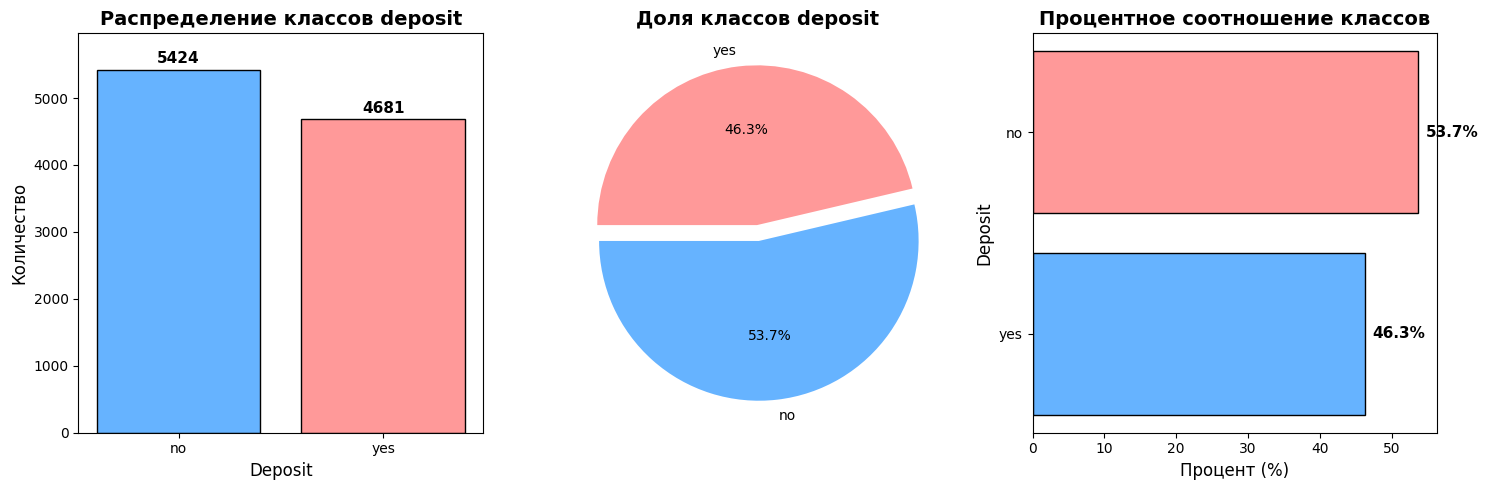


–î–æ–ø–æ–ª–Ω–∏—Ç–µ–ª—å–Ω–∞—è —Å—Ç–∞—Ç–∏—Å—Ç–∏–∫–∞:
–í—Å–µ–≥–æ –Ω–∞–±–ª—é–¥–µ–Ω–∏–π: 10105
–ö–ª–∞—Å—Å 'yes': 4681 (46.3%)
–ö–ª–∞—Å—Å 'no': 5424 (53.7%)

–†–µ–∫–æ–º–µ–Ω–¥–∞—Ü–∏–∏:
–ö–ª–∞—Å—Å—ã –¥–æ—Å—Ç–∞—Ç–æ—á–Ω–æ —Å–±–∞–ª–∞–Ω—Å–∏—Ä–æ–≤–∞–Ω—ã, –º–æ–∂–Ω–æ –∏—Å–ø–æ–ª—å–∑–æ–≤–∞—Ç—å accuracy –∫–∞–∫ –º–µ—Ç—Ä–∏–∫—É


In [11]:
# –ò–∑—É—á–∏—Ç–µ —Å–æ–æ—Ç–Ω–æ—à–µ–Ω–∏–µ –∫–ª–∞—Å—Å–æ–≤ –≤ –≤–∞—à–∏—Ö –¥–∞–Ω–Ω—ã—Ö –Ω–∞ –ø—Ä–µ–¥–º–µ—Ç –Ω–µ—Å–±–∞–ª–∞–Ω—Å–∏—Ä–æ–≤–∞–Ω–Ω–æ—Å—Ç–∏, –ø—Ä–æ–∏–ª–ª—é—Å—Ç—Ä–∏—Ä—É–π—Ç–µ —Ä–µ–∑—É–ª—å—Ç–∞—Ç

# –ê–±—Å–æ–ª—é—Ç–Ω—ã–µ –∑–Ω–∞—á–µ–Ω–∏—è
print("–ê–±—Å–æ–ª—é—Ç–Ω–æ–µ —Ä–∞—Å–ø—Ä–µ–¥–µ–ª–µ–Ω–∏–µ:")
deposit_counts = df['deposit'].value_counts()
print(deposit_counts)

# –û—Ç–Ω–æ—Å–∏—Ç–µ–ª—å–Ω—ã–µ –∑–Ω–∞—á–µ–Ω–∏—è (–ø—Ä–æ—Ü–µ–Ω—Ç—ã)
print("\n–û—Ç–Ω–æ—Å–∏—Ç–µ–ª—å–Ω–æ–µ —Ä–∞—Å–ø—Ä–µ–¥–µ–ª–µ–Ω–∏–µ (%):")
deposit_percent = df['deposit'].value_counts(normalize=True) * 100
print(deposit_percent.round(2))

# –ö–æ—ç—Ñ—Ñ–∏—Ü–∏–µ–Ω—Ç –Ω–µ—Å–±–∞–ª–∞–Ω—Å–∏—Ä–æ–≤–∞–Ω–Ω–æ—Å—Ç–∏
print("\n–ö–æ—ç—Ñ—Ñ–∏—Ü–∏–µ–Ω—Ç—ã –Ω–µ—Å–±–∞–ª–∞–Ω—Å–∏—Ä–æ–≤–∞–Ω–Ω–æ—Å—Ç–∏:")
ratio = deposit_counts.min() / deposit_counts.max()
print(f"–°–æ–æ—Ç–Ω–æ—à–µ–Ω–∏–µ –º–µ–Ω—å—à–µ–≥–æ –∫–ª–∞—Å—Å–∞ –∫ –±–æ–ª—å—à–µ–º—É: {ratio:.4f}")
print(f"–°–æ–æ—Ç–Ω–æ—à–µ–Ω–∏–µ –±–æ–ª—å—à–µ–≥–æ –∫–ª–∞—Å—Å–∞ –∫ –º–µ–Ω—å—à–µ–º—É: {1/ratio:.2f}:1")

# –û—Ü–µ–Ω–∫–∞ –¥–∏—Å–±–∞–ª–∞–Ω—Å–∞
print("\n–û—Ü–µ–Ω–∫–∞ –¥–∏—Å–±–∞–ª–∞–Ω—Å–∞:")
if ratio > 0.9:
    print("–ö–ª–∞—Å—Å—ã —Å–±–∞–ª–∞–Ω—Å–∏—Ä–æ–≤–∞–Ω—ã")
elif ratio > 0.7:
    print("–ù–µ–±–æ–ª—å—à–æ–π –¥–∏—Å–±–∞–ª–∞–Ω—Å")
elif ratio > 0.5:
    print("–£–º–µ—Ä–µ–Ω–Ω—ã–π –¥–∏—Å–±–∞–ª–∞–Ω—Å")
elif ratio > 0.3:
    print("–ó–Ω–∞—á–∏—Ç–µ–ª—å–Ω—ã–π –¥–∏—Å–±–∞–ª–∞–Ω—Å")
else:
    print("–ö—Ä–∏—Ç–∏—á–µ—Å–∫–∏–π –¥–∏—Å–±–∞–ª–∞–Ω—Å")

# –í–∏–∑—É–∞–ª–∏–∑–∞—Ü–∏—è
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# –ì—Ä–∞—Ñ–∏–∫ 1: –°—Ç–æ–ª–±—á–∞—Ç–∞—è –¥–∏–∞–≥—Ä–∞–º–º–∞
colors = {'#66b3ff','#ff9999'}
axes[0].bar(deposit_counts.index, deposit_counts.values, color=colors, edgecolor='black')
axes[0].set_title('–†–∞—Å–ø—Ä–µ–¥–µ–ª–µ–Ω–∏–µ –∫–ª–∞—Å—Å–æ–≤ deposit', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Deposit', fontsize=12)
axes[0].set_ylabel('–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ', fontsize=12)
axes[0].set_ylim(0, deposit_counts.max() * 1.1)
for i, (label, count) in enumerate(deposit_counts.items()):
    axes[0].text(i, count + 100, str(count), ha='center', fontsize=11, fontweight='bold')

# –ì—Ä–∞—Ñ–∏–∫ 2: –ö—Ä—É–≥–æ–≤–∞—è –¥–∏–∞–≥—Ä–∞–º–º–∞
axes[1].pie(deposit_counts.values, labels=deposit_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=180, explode=(0.05, 0.05))
axes[1].set_title('–î–æ–ª—è –∫–ª–∞—Å—Å–æ–≤ deposit', fontsize=14, fontweight='bold')

# –ì—Ä–∞—Ñ–∏–∫ 3: –ü—Ä–æ—Ü–µ–Ω—Ç–Ω–æ–µ —Å–æ–æ—Ç–Ω–æ—à–µ–Ω–∏–µ (–≥–æ—Ä–∏–∑–æ–Ω—Ç–∞–ª—å–Ω–∞—è –≥–∏—Å—Ç–æ–≥—Ä–∞–º–º–∞)
percent_data = deposit_percent.sort_values()
bars = axes[2].barh(percent_data.index, percent_data.values, color=colors, edgecolor='black')
axes[2].set_title('–ü—Ä–æ—Ü–µ–Ω—Ç–Ω–æ–µ —Å–æ–æ—Ç–Ω–æ—à–µ–Ω–∏–µ –∫–ª–∞—Å—Å–æ–≤', fontsize=14, fontweight='bold')
axes[2].set_xlabel('–ü—Ä–æ—Ü–µ–Ω—Ç (%)', fontsize=12)
axes[2].set_ylabel('Deposit', fontsize=12)
for i, (label, percent) in enumerate(percent_data.items()):
    axes[2].text(percent + 1, i, f'{percent:.1f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# –î–æ–ø–æ–ª–Ω–∏—Ç–µ–ª—å–Ω–∞—è —Å—Ç–∞—Ç–∏—Å—Ç–∏–∫–∞
print("\n–î–æ–ø–æ–ª–Ω–∏—Ç–µ–ª—å–Ω–∞—è —Å—Ç–∞—Ç–∏—Å—Ç–∏–∫–∞:")
print(f"–í—Å–µ–≥–æ –Ω–∞–±–ª—é–¥–µ–Ω–∏–π: {len(df)}")
print(f"–ö–ª–∞—Å—Å 'yes': {deposit_counts.get('yes', 0)} ({deposit_percent.get('yes', 0):.1f}%)")
print(f"–ö–ª–∞—Å—Å 'no': {deposit_counts.get('no', 0)} ({deposit_percent.get('no', 0):.1f}%)")

# –†–µ–∫–æ–º–µ–Ω–¥–∞—Ü–∏–∏ –ø–æ –±–∞–ª–∞–Ω—Å–∏—Ä–æ–≤–∫–µ (–µ—Å–ª–∏ –Ω—É–∂–Ω–æ)
print("\n–†–µ–∫–æ–º–µ–Ω–¥–∞—Ü–∏–∏:")
if ratio < 0.7:
    print("–†–µ–∫–æ–º–µ–Ω–¥—É–µ—Ç—Å—è –±–∞–ª–∞–Ω—Å–∏—Ä–æ–≤–∫–∞ –∫–ª–∞—Å—Å–æ–≤ –¥–ª—è –æ–±—É—á–µ–Ω–∏—è –º–æ–¥–µ–ª–µ–π:")
    print("   - Oversampling (SMOTE, RandomOverSampler)")
    print("   - Undersampling (RandomUnderSampler)")
    print("   - –ò—Å–ø–æ–ª—å–∑–æ–≤–∞–Ω–∏–µ class_weight='balanced'")
    print("   - –ò—Å–ø–æ–ª—å–∑–æ–≤–∞–Ω–∏–µ –º–µ—Ç—Ä–∏–∫: precision, recall, F1-score, ROC-AUC")
else:
    print("–ö–ª–∞—Å—Å—ã –¥–æ—Å—Ç–∞—Ç–æ—á–Ω–æ —Å–±–∞–ª–∞–Ω—Å–∏—Ä–æ–≤–∞–Ω—ã, –º–æ–∂–Ω–æ –∏—Å–ø–æ–ª—å–∑–æ–≤–∞—Ç—å accuracy –∫–∞–∫ –º–µ—Ç—Ä–∏–∫—É")

### –ó–∞–¥–∞–Ω–∏—è 2 –∏ 3

In [12]:
# –†–∞—Å—Å—á–∏—Ç–∞–π—Ç–µ –æ–ø–∏—Å–∞—Ç–µ–ª—å–Ω—ã–µ —Å—Ç–∞—Ç–∏—Å—Ç–∏–∫–∏ –¥–ª—è –∫–æ–ª–∏—á–µ—Å—Ç–≤–µ–Ω–Ω—ã—Ö –ø–µ—Ä–µ–º–µ–Ω–Ω—ã—Ö, –ø—Ä–æ–∏–Ω—Ç–µ—Ä–ø—Ä–µ—Ç–∏—Ä—É–π—Ç–µ —Ä–µ–∑—É–ª—å—Ç–∞—Ç

# –í—ã–±–∏—Ä–∞–µ–º –∫–æ–ª–∏—á–µ—Å—Ç–≤–µ–Ω–Ω—ã–µ –ø–µ—Ä–µ–º–µ–Ω–Ω—ã–µ
quantitative_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# –û—Å–Ω–æ–≤–Ω—ã–µ –æ–ø–∏—Å–∞—Ç–µ–ª—å–Ω—ã–µ —Å—Ç–∞—Ç–∏—Å—Ç–∏–∫–∏
print("–û–°–ù–û–í–ù–´–ï –°–¢–ê–¢–ò–°–¢–ò–ö–ò:")
print(df[quantitative_cols].describe().round(2))

# –î–æ–ø–æ–ª–Ω–∏—Ç–µ–ª—å–Ω—ã–µ —Å—Ç–∞—Ç–∏—Å—Ç–∏–∫–∏
print("\n–î–û–ü–û–õ–ù–ò–¢–ï–õ–¨–ù–´–ï –°–¢–ê–¢–ò–°–¢–ò–ö–ò (–¥–∏—Å–ø–µ—Ä—Å–∏—è, –∞—Å–∏–º–º–µ—Ç—Ä–∏—è, —ç–∫—Å—Ü–µ—Å—Å):")
for col in quantitative_cols:
    print(f"\n---- {col} ----")
    print(f"  –î–∏—Å–ø–µ—Ä—Å–∏—è: {df[col].var():.2f}")
    print(f"  –°—Ç–∞–Ω–¥–∞—Ä—Ç–Ω–æ–µ –æ—Ç–∫–ª–æ–Ω–µ–Ω–∏–µ: {df[col].std():.2f}")
    print(f"  –ê—Å–∏–º–º–µ—Ç—Ä–∏—è (skewness): {df[col].skew():.3f}")
    print(f"  –≠–∫—Å—Ü–µ—Å—Å (kurtosis): {df[col].kurtosis():.3f}")

# –ò–ù–¢–ï–†–ü–†–ï–¢–ê–¶–ò–Ø –ø–æ –∫–∞–∂–¥–æ–º—É –ø—Ä–∏–∑–Ω–∞–∫—É
print("\n" + "="*60)
print("–ò–ù–¢–ï–†–ü–†–ï–¢–ê–¶–ò–Ø –°–¢–ê–¢–ò–°–¢–ò–ö")
print("="*60)

# age
print(f"\nüìä age (–≤–æ–∑—Ä–∞—Å—Ç):")
print(f"   ‚Ä¢ –°—Ä–µ–¥–Ω–∏–π –≤–æ–∑—Ä–∞—Å—Ç –∫–ª–∏–µ–Ω—Ç–æ–≤: {df['age'].mean():.1f} –ª–µ—Ç")
print(f"   ‚Ä¢ –ú–µ–¥–∏–∞–Ω–∞: {df['age'].median():.0f} –ª–µ—Ç")
print(f"   ‚Ä¢ –ú–∏–Ω–∏–º–∞–ª—å–Ω—ã–π: {df['age'].min():.0f}, –º–∞–∫—Å–∏–º–∞–ª—å–Ω—ã–π: {df['age'].max():.0f}")
print(f"   ‚Ä¢ –†–∞–∑–±—Ä–æ—Å: –æ—Ç {df['age'].quantile(0.25):.0f} –¥–æ {df['age'].quantile(0.75):.0f} –ª–µ—Ç (IQR)")
print(f"   ‚Ä¢ –ò–Ω—Ç–µ—Ä–ø—Ä–µ—Ç–∞—Ü–∏—è: {'–°–∏–º–º–µ—Ç—Ä–∏—á–Ω–æ–µ' if abs(df['age'].skew()) < 0.5 else '–ê—Å–∏–º–º–µ—Ç—Ä–∏—á–Ω–æ–µ'} —Ä–∞—Å–ø—Ä–µ–¥–µ–ª–µ–Ω–∏–µ")

# balance
print(f"\nüí∞ balance (–±–∞–ª–∞–Ω—Å –Ω–∞ —Å—á—ë—Ç–µ):")
print(f"   ‚Ä¢ –°—Ä–µ–¥–Ω–∏–π –±–∞–ª–∞–Ω—Å: {df['balance'].mean():.0f} $")
print(f"   ‚Ä¢ –ú–µ–¥–∏–∞–Ω–∞: {df['balance'].median():.0f} $")
print(f"   ‚Ä¢ –°—Ä–µ–¥–Ω–µ–µ > –º–µ–¥–∏–∞–Ω—ã –Ω–∞ {df['balance'].mean() - df['balance'].median():.0f} $")
print(f"   ‚Ä¢ 25% –∫–ª–∏–µ–Ω—Ç–æ–≤ –∏–º–µ—é—Ç –±–∞–ª–∞–Ω—Å –º–µ–Ω–µ–µ {df['balance'].quantile(0.25):.0f} $")
print(f"   ‚Ä¢ 75% –∫–ª–∏–µ–Ω—Ç–æ–≤ –∏–º–µ—é—Ç –±–∞–ª–∞–Ω—Å –º–µ–Ω–µ–µ {df['balance'].quantile(0.75):.0f} $")
print(f"   ‚Ä¢ –ò–Ω—Ç–µ—Ä–ø—Ä–µ—Ç–∞—Ü–∏—è: {'–ü—Ä–∞–≤–æ—Å—Ç–æ—Ä–æ–Ω–Ω—è—è –∞—Å–∏–º–º–µ—Ç—Ä–∏—è (–µ—Å—Ç—å –±–æ–≥–∞—Ç—ã–µ –∫–ª–∏–µ–Ω—Ç—ã)' if df['balance'].skew() > 0 else '–õ–µ–≤–æ—Å—Ç–æ—Ä–æ–Ω–Ω—è—è –∞—Å–∏–º–º–µ—Ç—Ä–∏—è'}")

# day
print(f"\nüìÖ day (–¥–µ–Ω—å –º–µ—Å—è—Ü–∞ –∫–æ–Ω—Ç–∞–∫—Ç–∞):")
print(f"   ‚Ä¢ –°—Ä–µ–¥–Ω–∏–π –¥–µ–Ω—å: {df['day'].mean():.1f}")
print(f"   ‚Ä¢ –ú–µ–¥–∏–∞–Ω–∞: {df['day'].median():.0f}")
print(f"   ‚Ä¢ min={df['day'].min():.0f}, max={df['day'].max():.0f}")
print(f"   ‚Ä¢ –ò–Ω—Ç–µ—Ä–ø—Ä–µ—Ç–∞—Ü–∏—è: –∫–æ–Ω—Ç–∞–∫—Ç—ã —Ä–∞—Å–ø—Ä–µ–¥–µ–ª–µ–Ω—ã –ø–æ –≤—Å–µ–º—É –º–µ—Å—è—Ü—É")

# duration
print(f"\n‚è±Ô∏è duration (–¥–ª–∏—Ç–µ–ª—å–Ω–æ—Å—Ç—å —Ä–∞–∑–≥–æ–≤–æ—Ä–∞ –≤ —Å–µ–∫—É–Ω–¥–∞—Ö):")
print(f"   ‚Ä¢ –°—Ä–µ–¥–Ω—è—è –¥–ª–∏—Ç–µ–ª—å–Ω–æ—Å—Ç—å: {df['duration'].mean():.0f} —Å–µ–∫ ({df['duration'].mean()/60:.1f} –º–∏–Ω)")
print(f"   ‚Ä¢ –ú–µ–¥–∏–∞–Ω–∞: {df['duration'].median():.0f} —Å–µ–∫ ({df['duration'].median()/60:.1f} –º–∏–Ω)")
print(f"   ‚Ä¢ –°—Ç–∞–Ω–¥–∞—Ä—Ç–Ω–æ–µ –æ—Ç–∫–ª–æ–Ω–µ–Ω–∏–µ: {df['duration'].std():.0f} —Å–µ–∫")
print(f"   ‚Ä¢ –ò–Ω—Ç–µ—Ä–ø—Ä–µ—Ç–∞—Ü–∏—è: —Ä–∞–∑–≥–æ–≤–æ—Ä—ã —Å–∏–ª—å–Ω–æ –≤–∞—Ä—å–∏—Ä—É—é—Ç—Å—è –æ—Ç –∫–æ—Ä–æ—Ç–∫–∏—Ö –¥–æ –¥–ª–∏—Ç–µ–ª—å–Ω—ã—Ö")

# campaign
print(f"\nüìû campaign (–∫–æ–ª–∏—á–µ—Å—Ç–≤–æ –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤ –≤ –∫–∞–º–ø–∞–Ω–∏–∏):")
print(f"   ‚Ä¢ –°—Ä–µ–¥–Ω–µ–µ: {df['campaign'].mean():.2f} –∫–æ–Ω—Ç–∞–∫—Ç–∞")
print(f"   ‚Ä¢ –ú–µ–¥–∏–∞–Ω–∞: {df['campaign'].median():.0f} –∫–æ–Ω—Ç–∞–∫—Ç–∞")
print(f"   ‚Ä¢ –ë–æ–ª—å—à–∏–Ω—Å—Ç–≤–æ –∫–ª–∏–µ–Ω—Ç–æ–≤: {df['campaign'].quantile(0.75):.0f} –∫–æ–Ω—Ç–∞–∫—Ç–∞ –∏–ª–∏ –º–µ–Ω—å—à–µ")
print(f"   ‚Ä¢ –ò–Ω—Ç–µ—Ä–ø—Ä–µ—Ç–∞—Ü–∏—è: {'–ë–æ–ª—å—à–∏–Ω—Å—Ç–≤—É –∑–≤–æ–Ω–∏–ª–∏ 1-2 —Ä–∞–∑–∞' if df['campaign'].median() <= 2 else '–ß–∞—Å—Ç—ã–µ –∫–æ–Ω—Ç–∞–∫—Ç—ã'}")

# pdays
print(f"\nüïí pdays (–¥–Ω–µ–π —Å –ø—Ä–µ–¥—ã–¥—É—â–µ–≥–æ –∫–æ–Ω—Ç–∞–∫—Ç–∞):")
print(f"   ‚Ä¢ –°—Ä–µ–¥–Ω–µ–µ: {df['pdays'].mean():.1f} –¥–Ω–µ–π")
print(f"   ‚Ä¢ –ú–µ–¥–∏–∞–Ω–∞: {df['pdays'].median():.0f} –¥–Ω–µ–π")
pdays_neg = (df['pdays'] == -1).sum()
print(f"   ‚Ä¢ –ö–ª–∏–µ–Ω—Ç–æ–≤ –±–µ–∑ –ø—Ä–µ–¥—ã–¥—É—â–µ–≥–æ –∫–æ–Ω—Ç–∞–∫—Ç–∞: {pdays_neg} ({pdays_neg/len(df)*100:.1f}%)")
print(f"   ‚Ä¢ –ò–Ω—Ç–µ—Ä–ø—Ä–µ—Ç–∞—Ü–∏—è: –±–æ–ª—å—à–∏–Ω—Å—Ç–≤–æ –∫–ª–∏–µ–Ω—Ç–æ–≤ (-1) –Ω–µ –∏–º–µ–ª–∏ –ø—Ä–µ–¥—ã–¥—É—â–∏—Ö –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤")

# previous
print(f"\nüìú previous (–∫–æ–ª–∏—á–µ—Å—Ç–≤–æ –ø—Ä–µ–¥—ã–¥—É—â–∏—Ö –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤):")
print(f"   ‚Ä¢ –°—Ä–µ–¥–Ω–µ–µ: {df['previous'].mean():.2f}")
print(f"   ‚Ä¢ –ú–µ–¥–∏–∞–Ω–∞: {df['previous'].median():.0f}")
print(f"   ‚Ä¢ –ú–∞–∫—Å–∏–º—É–º: {df['previous'].max():.0f}")
print(f"   ‚Ä¢ –ò–Ω—Ç–µ—Ä–ø—Ä–µ—Ç–∞—Ü–∏—è: –±–æ–ª—å—à–∏–Ω—Å—Ç–≤–æ –∫–ª–∏–µ–Ω—Ç–æ–≤ (–º–µ–¥–∏–∞–Ω–∞=0) –Ω–µ –∏–º–µ–ª–∏ –ø—Ä–µ–¥—ã–¥—É—â–∏—Ö –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤")

# –ö–æ—Ä—Ä–µ–ª—è—Ü–∏–æ–Ω–Ω–∞—è –º–∞—Ç—Ä–∏—Ü–∞
print("\n" + "="*60)
print("–ö–û–†–†–ï–õ–Ø–¶–ò–Ø –ú–ï–ñ–î–£ –ö–û–õ–ò–ß–ï–°–¢–í–ï–ù–ù–´–ú–ò –ü–ï–†–ï–ú–ï–ù–ù–´–ú–ò")
print("="*60)
correlation_matrix = df[quantitative_cols].corr()
print(correlation_matrix.round(3))

# –ù–∞—Ö–æ–¥–∏–º —Å–∞–º—ã–µ —Å–∏–ª—å–Ω—ã–µ –∫–æ—Ä—Ä–µ–ª—è—Ü–∏–∏
print("\nüîç –°–∞–º—ã–µ —Å–∏–ª—å–Ω—ã–µ –∫–æ—Ä—Ä–µ–ª—è—Ü–∏–∏:")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr = correlation_matrix.iloc[i, j]
        if abs(corr) > 0.3:
            print(f"  {correlation_matrix.columns[i]} ‚Üî {correlation_matrix.columns[j]}: {corr:.3f}")

# –í—ã–≤–æ–¥—ã
print("\n" + "="*60)
print("–û–°–ù–û–í–ù–´–ï –í–´–í–û–î–´")
print("="*60)
print("‚úÖ –í–æ–∑—Ä–∞—Å—Ç –∫–ª–∏–µ–Ω—Ç–æ–≤ –≤ –æ—Å–Ω–æ–≤–Ω–æ–º –æ—Ç 30 –¥–æ 50 –ª–µ—Ç")
print("‚úÖ –ë–∞–ª–∞–Ω—Å –Ω–∞ —Å—á—ë—Ç–µ –∏–º–µ–µ—Ç –ø—Ä–∞–≤–æ—Å—Ç–æ—Ä–æ–Ω–Ω—é—é –∞—Å–∏–º–º–µ—Ç—Ä–∏—é (–±–æ–ª—å—à–∏–Ω—Å—Ç–≤–æ –æ–±—ã—á–Ω—ã–µ –∫–ª–∏–µ–Ω—Ç—ã)")
print("‚úÖ –î–ª–∏—Ç–µ–ª—å–Ω–æ—Å—Ç—å —Ä–∞–∑–≥–æ–≤–æ—Ä–∞ —Å–∏–ª—å–Ω–æ –≤–∞—Ä—å–∏—Ä—É–µ—Ç—Å—è, —á—Ç–æ –≤–∞–∂–Ω–æ –¥–ª—è –ø—Ä–µ–¥—Å–∫–∞–∑–∞–Ω–∏—è")
print("‚úÖ –ë–æ–ª—å—à–∏–Ω—Å—Ç–≤—É –∫–ª–∏–µ–Ω—Ç–æ–≤ –∑–≤–æ–Ω–∏–ª–∏ 1-2 —Ä–∞–∑–∞ –∑–∞ –∫–∞–º–ø–∞–Ω–∏—é")
print("‚úÖ –ë–æ–ª–µ–µ 80% –∫–ª–∏–µ–Ω—Ç–æ–≤ –Ω–µ –∏–º–µ–ª–∏ –ø—Ä–µ–¥—ã–¥—É—â–∏—Ö –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤")
print("‚úÖ –°–∏–ª—å–Ω—ã—Ö –∫–æ—Ä—Ä–µ–ª—è—Ü–∏–π –º–µ–∂–¥—É –ø—Ä–∏–∑–Ω–∞–∫–∞–º–∏ –Ω–µ –æ–±–Ω–∞—Ä—É–∂–µ–Ω–æ (–º—É–ª—å—Ç–∏–∫–æ–ª–ª–∏–Ω–µ–∞—Ä–Ω–æ—Å—Ç–∏ –Ω–µ—Ç)")

–û–°–ù–û–í–ù–´–ï –°–¢–ê–¢–ò–°–¢–ò–ö–ò:
            age   balance       day  duration  campaign     pdays  previous
count  10105.00  10105.00  10105.00  10105.00  10105.00  10105.00  10105.00
mean      40.90    807.65     15.59    368.74      2.52     51.32      0.82
std       11.73    994.15      8.44    346.65      2.71    109.64      2.24
min       18.00  -2049.00      1.00      2.00      1.00     -1.00      0.00
25%       32.00     95.00      8.00    137.00      1.00     -1.00      0.00
50%       38.00    445.00     15.00    252.00      2.00     -1.00      0.00
75%       48.00   1227.00     22.00    490.00      3.00      2.00      1.00
max       95.00   4063.00     31.00   3881.00     43.00    854.00     58.00

–î–û–ü–û–õ–ù–ò–¢–ï–õ–¨–ù–´–ï –°–¢–ê–¢–ò–°–¢–ò–ö–ò (–¥–∏—Å–ø–µ—Ä—Å–∏—è, –∞—Å–∏–º–º–µ—Ç—Ä–∏—è, —ç–∫—Å—Ü–µ—Å—Å):

---- age ----
  –î–∏—Å–ø–µ—Ä—Å–∏—è: 137.71
  –°—Ç–∞–Ω–¥–∞—Ä—Ç–Ω–æ–µ –æ—Ç–∫–ª–æ–Ω–µ–Ω–∏–µ: 11.73
  –ê—Å–∏–º–º–µ—Ç—Ä–∏—è (skewness): 0.868
  –≠–∫—Å—Ü–µ—Å—Å (kurtosis):

### –ó–∞–¥–∞–Ω–∏—è 4 –∏ 5

–û–ë–©–ê–Ø –ò–ù–§–û–†–ú–ê–¶–ò–Ø:

--- job ---
  –£–Ω–∏–∫–∞–ª—å–Ω—ã—Ö –∑–Ω–∞—á–µ–Ω–∏–π: 11
  –ù–∞–∏–±–æ–ª–µ–µ —á–∞—Å—Ç—ã–µ –∑–Ω–∞—á–µ–Ω–∏—è:
job
management     2315
blue-collar    1807
technician     1638
Name: count, dtype: int64

--- marital ---
  –£–Ω–∏–∫–∞–ª—å–Ω—ã—Ö –∑–Ω–∞—á–µ–Ω–∏–π: 3
  –ù–∞–∏–±–æ–ª–µ–µ —á–∞—Å—Ç—ã–µ –∑–Ω–∞—á–µ–Ω–∏—è:
marital
married     5715
single      3213
divorced    1177
Name: count, dtype: int64

--- education ---
  –£–Ω–∏–∫–∞–ª—å–Ω—ã—Ö –∑–Ω–∞—á–µ–Ω–∏–π: 3
  –ù–∞–∏–±–æ–ª–µ–µ —á–∞—Å—Ç—ã–µ –∑–Ω–∞—á–µ–Ω–∏—è:
education
secondary    5517
tertiary     3239
primary      1349
Name: count, dtype: int64

--- default ---
  –£–Ω–∏–∫–∞–ª—å–Ω—ã—Ö –∑–Ω–∞—á–µ–Ω–∏–π: 2
  –ù–∞–∏–±–æ–ª–µ–µ —á–∞—Å—Ç—ã–µ –∑–Ω–∞—á–µ–Ω–∏—è:
default
no     9939
yes     166
Name: count, dtype: int64

--- housing ---
  –£–Ω–∏–∫–∞–ª—å–Ω—ã—Ö –∑–Ω–∞—á–µ–Ω–∏–π: 2
  –ù–∞–∏–±–æ–ª–µ–µ —á–∞—Å—Ç—ã–µ –∑–Ω–∞—á–µ–Ω–∏—è:
housing
no     5243
yes    4862
Name: count, dtype: int64

--- loan ---
  –£–Ω–∏–∫–∞–ª—å–Ω—ã—Ö 

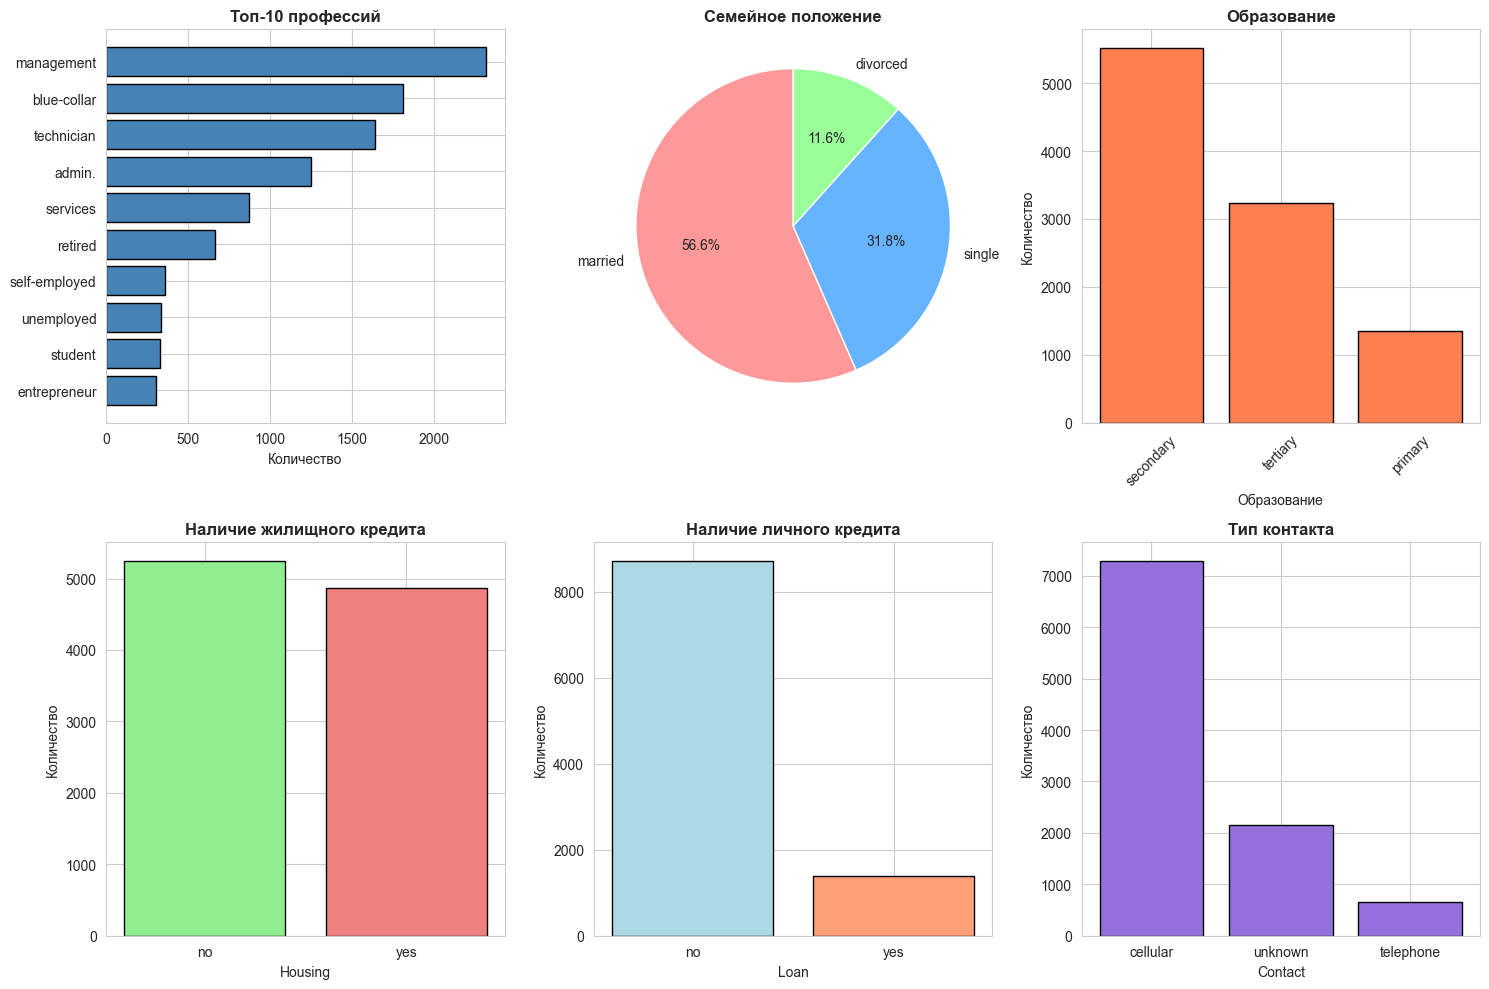

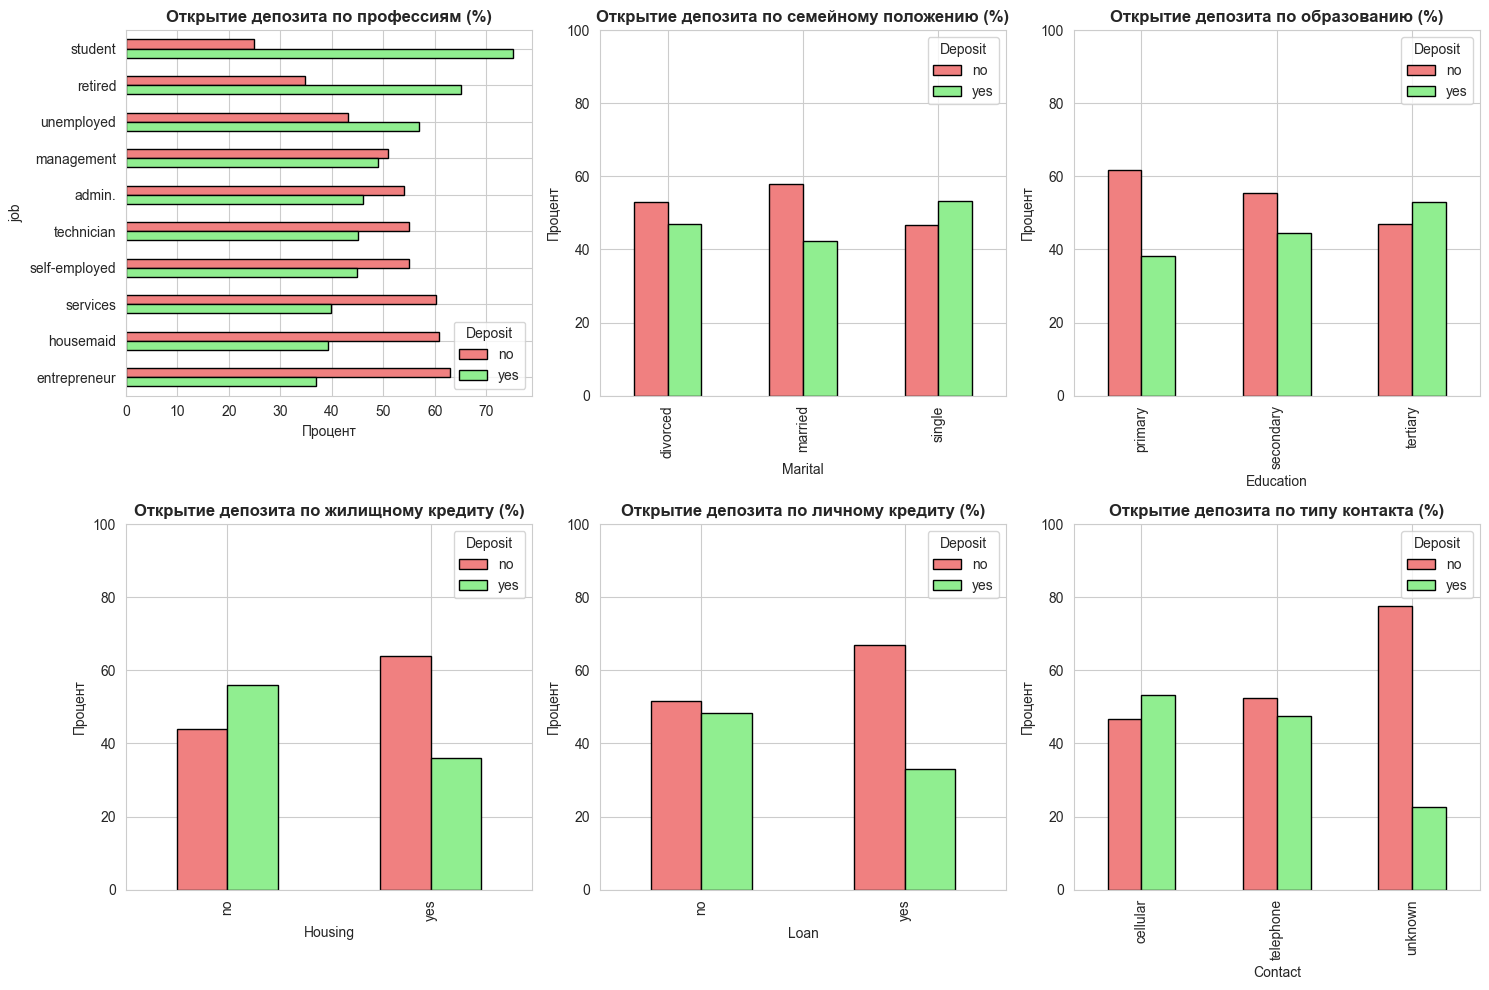

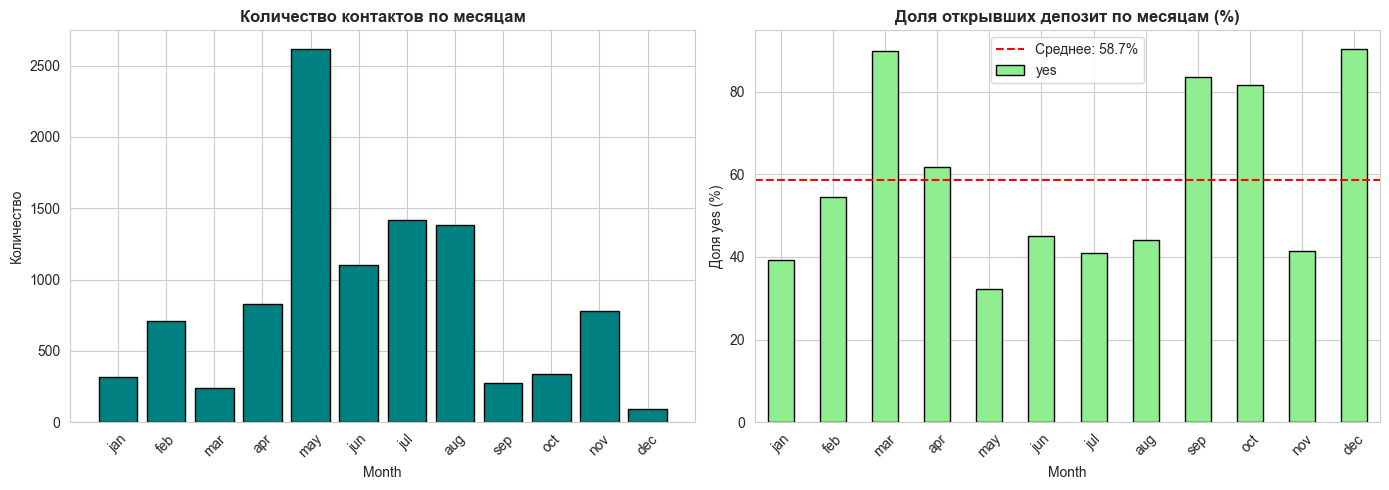

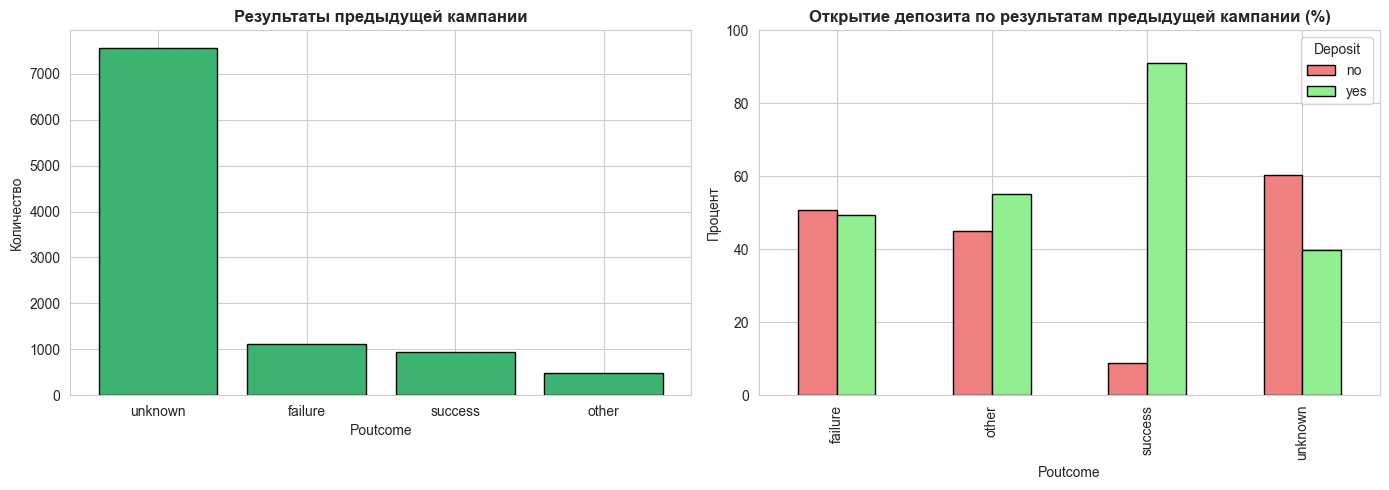


–¢–ï–ü–õ–û–í–ê–Ø –ö–ê–†–¢–ê –°–í–Ø–ó–ò –ö–ê–¢–ï–ì–û–†–ò–ê–õ–¨–ù–´–• –ü–†–ò–ó–ù–ê–ö–û–í (CRAMER'S V)



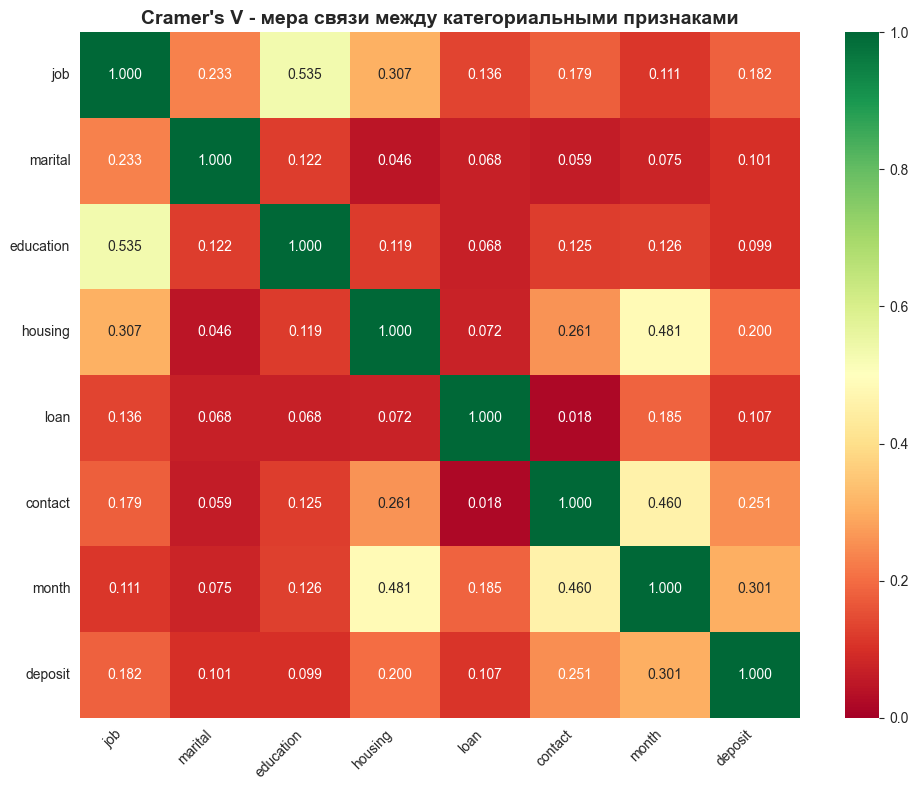


üîç –ò–Ω—Ç–µ—Ä–ø—Ä–µ—Ç–∞—Ü–∏—è Cramer's V:
   ‚Ä¢ 0.00-0.10: –æ—á–µ–Ω—å —Å–ª–∞–±–∞—è —Å–≤—è–∑—å
   ‚Ä¢ 0.10-0.20: —Å–ª–∞–±–∞—è —Å–≤—è–∑—å
   ‚Ä¢ 0.20-0.40: —É–º–µ—Ä–µ–Ω–Ω–∞—è —Å–≤—è–∑—å
   ‚Ä¢ 0.40-0.60: —Å–∏–ª—å–Ω–∞—è —Å–≤—è–∑—å
   ‚Ä¢ 0.60-1.00: –æ—á–µ–Ω—å —Å–∏–ª—å–Ω–∞—è —Å–≤—è–∑—å


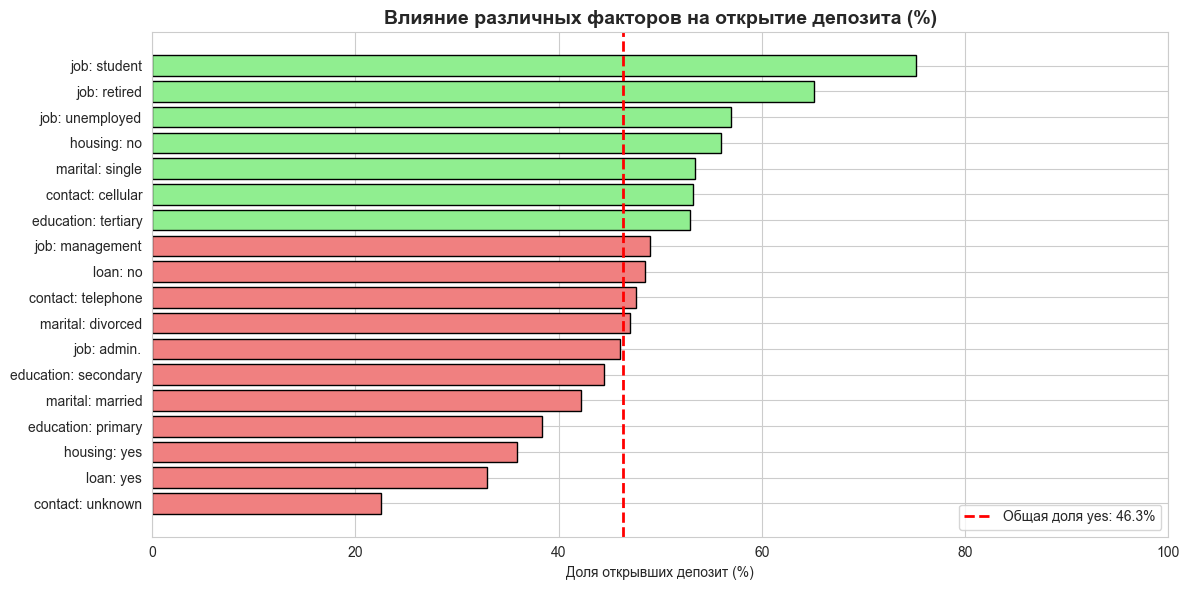


‚úÖ –í—Å–µ –≤–∏–∑—É–∞–ª–∏–∑–∞—Ü–∏–∏ —É—Å–ø–µ—à–Ω–æ –ø–æ—Å—Ç—Ä–æ–µ–Ω—ã!


In [13]:
# –†–∞—Å—Å—á–∏—Ç–∞–π—Ç–µ –æ–ø–∏—Å–∞—Ç–µ–ª—å–Ω—ã–µ —Å—Ç–∞—Ç–∏—Å—Ç–∏–∫–∏ –¥–ª—è –∫–∞—Ç–µ–≥–æ—Ä–∏–∞–ª—å–Ω—ã—Ö –ø–µ—Ä–µ–º–µ–Ω–Ω—ã—Ö, –ø—Ä–æ–∏–Ω—Ç–µ—Ä–ø—Ä–µ—Ç–∏—Ä—É–π—Ç–µ —Ä–µ–∑—É–ª—å—Ç–∞—Ç

# –ö–∞—Ç–µ–≥–æ—Ä–∏–∞–ª—å–Ω—ã–µ –ø–µ—Ä–µ–º–µ–Ω–Ω—ã–µ
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']

# –û–±—â–∞—è –∏–Ω—Ñ–æ—Ä–º–∞—Ü–∏—è
print("–û–ë–©–ê–Ø –ò–ù–§–û–†–ú–ê–¶–ò–Ø:")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(f"  –£–Ω–∏–∫–∞–ª—å–Ω—ã—Ö –∑–Ω–∞—á–µ–Ω–∏–π: {df[col].nunique()}")
    print(f"  –ù–∞–∏–±–æ–ª–µ–µ —á–∞—Å—Ç—ã–µ –∑–Ω–∞—á–µ–Ω–∏—è:")
    print(df[col].value_counts().head(3))

# –î–ï–¢–ê–õ–¨–ù–ê–Ø –°–¢–ê–¢–ò–°–¢–ò–ö–ê –ü–û –ö–ê–ñ–î–û–ú–£ –ü–†–ò–ó–ù–ê–ö–£
print("–î–ï–¢–ê–õ–¨–ù–ê–Ø –°–¢–ê–¢–ò–°–¢–ò–ö–ê –ü–û –ö–ê–ñ–î–û–ú–£ –ü–†–ò–ó–ù–ê–ö–£")

# job
print(f"\nüìã job (–ø—Ä–æ—Ñ–µ—Å—Å–∏—è):")
job_stats = df['job'].value_counts()
job_pct = df['job'].value_counts(normalize=True) * 100
print(f"   ‚Ä¢ –í—Å–µ–≥–æ –ø—Ä–æ—Ñ–µ—Å—Å–∏–π: {df['job'].nunique()}")
print(f"   ‚Ä¢ –¢–æ–ø-5 –ø—Ä–æ—Ñ–µ—Å—Å–∏–π:")
for job, count in job_stats.head(5).items():
    print(f"     - {job}: {count} ({job_pct[job]:.1f}%)")
print(f"   ‚Ä¢ –°–∞–º—ã–µ —Ä–µ–¥–∫–∏–µ: {job_stats.tail(3).index.tolist()}")

# marital
print(f"\nüíç marital (—Å–µ–º–µ–π–Ω–æ–µ –ø–æ–ª–æ–∂–µ–Ω–∏–µ):")
marital_stats = df['marital'].value_counts()
marital_pct = df['marital'].value_counts(normalize=True) * 100
for status, count in marital_stats.items():
    print(f"   ‚Ä¢ {status}: {count} ({marital_pct[status]:.1f}%)")

# education
print(f"\nüéì education (–æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ):")
edu_stats = df['education'].value_counts()
edu_pct = df['education'].value_counts(normalize=True) * 100
for edu, count in edu_stats.items():
    print(f"   ‚Ä¢ {edu}: {count} ({edu_pct[edu]:.1f}%)")

# default
print(f"\n‚ö†Ô∏è default (–ø—Ä–æ—Å—Ä–æ—á–∫–∞ –ø–æ –∫—Ä–µ–¥–∏—Ç—É):")
default_stats = df['default'].value_counts()
default_pct = df['default'].value_counts(normalize=True) * 100
for val, count in default_stats.items():
    print(f"   ‚Ä¢ {val}: {count} ({default_pct[val]:.1f}%)")

# housing
print(f"\nüè† housing (–∂–∏–ª–∏—â–Ω—ã–π –∫—Ä–µ–¥–∏—Ç):")
housing_stats = df['housing'].value_counts()
housing_pct = df['housing'].value_counts(normalize=True) * 100
for val, count in housing_stats.items():
    print(f"   ‚Ä¢ {val}: {count} ({housing_pct[val]:.1f}%)")

# loan
print(f"\nüí∞ loan (–ª–∏—á–Ω—ã–π –∫—Ä–µ–¥–∏—Ç):")
loan_stats = df['loan'].value_counts()
loan_pct = df['loan'].value_counts(normalize=True) * 100
for val, count in loan_stats.items():
    print(f"   ‚Ä¢ {val}: {count} ({loan_pct[val]:.1f}%)")

# contact
print(f"\nüìû contact (—Ç–∏–ø –∫–æ–Ω—Ç–∞–∫—Ç–∞):")
contact_stats = df['contact'].value_counts()
contact_pct = df['contact'].value_counts(normalize=True) * 100
for contact_type, count in contact_stats.items():
    print(f"   ‚Ä¢ {contact_type}: {count} ({contact_pct[contact_type]:.1f}%)")

# month
print(f"\nüìÖ month (–º–µ—Å—è—Ü –∫–æ–Ω—Ç–∞–∫—Ç–∞):")
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_stats = df['month'].value_counts()
month_pct = df['month'].value_counts(normalize=True) * 100
print(f"   ‚Ä¢ –ë–æ–ª—å—à–∏–Ω—Å—Ç–≤–æ –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤ –≤: {month_stats.index[0]} ({month_stats.iloc[0]} –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤)")
print(f"   ‚Ä¢ –¢–æ–ø-3 –º–µ—Å—è—Ü–∞:")
for month in month_stats.head(3).index:
    print(f"     - {month}: {month_stats[month]} ({month_pct[month]:.1f}%)")

# poutcome
print(f"\nüìä poutcome (—Ä–µ–∑—É–ª—å—Ç–∞—Ç –ø—Ä–µ–¥—ã–¥—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏):")
poutcome_stats = df['poutcome'].value_counts()
poutcome_pct = df['poutcome'].value_counts(normalize=True) * 100
for outcome, count in poutcome_stats.items():
    print(f"   ‚Ä¢ {outcome}: {count} ({poutcome_pct[outcome]:.1f}%)")

# deposit (—Ü–µ–ª–µ–≤–∞—è –ø–µ—Ä–µ–º–µ–Ω–Ω–∞—è)
print(f"\nüéØ deposit (—Ü–µ–ª–µ–≤–∞—è –ø–µ—Ä–µ–º–µ–Ω–Ω–∞—è):")
deposit_stats = df['deposit'].value_counts()
deposit_pct = df['deposit'].value_counts(normalize=True) * 100
for val, count in deposit_stats.items():
    print(f"   ‚Ä¢ {val}: {count} ({deposit_pct[val]:.1f}%)")

# –ö–†–û–°–°-–¢–ê–ë–£–õ–Ø–¶–ò–ò (—Å–≤—è–∑—å –∫–∞—Ç–µ–≥–æ—Ä–∏–∞–ª—å–Ω—ã—Ö –ø—Ä–∏–∑–Ω–∞–∫–æ–≤ —Å —Ü–µ–ª–µ–≤–æ–π –ø–µ—Ä–µ–º–µ–Ω–Ω–æ–π)
print("–í–õ–ò–Ø–ù–ò–ï –ö–ê–¢–ï–ì–û–†–ò–ê–õ–¨–ù–´–• –ü–†–ò–ó–ù–ê–ö–û–í –ù–ê DEPOSIT")

# job vs deposit
print("\nüìã –ü—Ä–æ—Ñ–µ—Å—Å–∏—è –∏ –æ—Ç–∫—Ä—ã—Ç–∏–µ –¥–µ–ø–æ–∑–∏—Ç–∞:")
job_deposit = pd.crosstab(df['job'], df['deposit'], normalize='index') * 100
job_deposit_sorted = job_deposit.sort_values('yes', ascending=False)
print(job_deposit_sorted.head(10).round(1))

# marital vs deposit
print("\nüíç –°–µ–º–µ–π–Ω–æ–µ –ø–æ–ª–æ–∂–µ–Ω–∏–µ –∏ –æ—Ç–∫—Ä—ã—Ç–∏–µ –¥–µ–ø–æ–∑–∏—Ç–∞:")
marital_deposit = pd.crosstab(df['marital'], df['deposit'], normalize='index') * 100
print(marital_deposit.round(1))

# education vs deposit
print("\nüéì –û–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ –∏ –æ—Ç–∫—Ä—ã—Ç–∏–µ –¥–µ–ø–æ–∑–∏—Ç–∞:")
edu_deposit = pd.crosstab(df['education'], df['deposit'], normalize='index') * 100
print(edu_deposit.round(1))

# housing vs deposit
print("\nüè† –ñ–∏–ª–∏—â–Ω—ã–π –∫—Ä–µ–¥–∏—Ç –∏ –æ—Ç–∫—Ä—ã—Ç–∏–µ –¥–µ–ø–æ–∑–∏—Ç–∞:")
housing_deposit = pd.crosstab(df['housing'], df['deposit'], normalize='index') * 100
print(housing_deposit.round(1))

# loan vs deposit
print("\nüí∞ –õ–∏—á–Ω—ã–π –∫—Ä–µ–¥–∏—Ç –∏ –æ—Ç–∫—Ä—ã—Ç–∏–µ –¥–µ–ø–æ–∑–∏—Ç–∞:")
loan_deposit = pd.crosstab(df['loan'], df['deposit'], normalize='index') * 100
print(loan_deposit.round(1))

# contact vs deposit
print("\nüìû –¢–∏–ø –∫–æ–Ω—Ç–∞–∫—Ç–∞ –∏ –æ—Ç–∫—Ä—ã—Ç–∏–µ –¥–µ–ø–æ–∑–∏—Ç–∞:")
contact_deposit = pd.crosstab(df['contact'], df['deposit'], normalize='index') * 100
print(contact_deposit.round(1))

# month vs deposit
print("\nüìÖ –ú–µ—Å—è—Ü –∏ –æ—Ç–∫—Ä—ã—Ç–∏–µ –¥–µ–ø–æ–∑–∏—Ç–∞:")
month_deposit = pd.crosstab(df['month'], df['deposit'], normalize='index') * 100
month_deposit_sorted = month_deposit.sort_values('yes', ascending=False)
print(month_deposit_sorted.round(1))

# –í–´–í–û–î–´ –ò –ò–ù–¢–ï–†–ü–†–ï–¢–ê–¶–ò–Ø
print("–û–°–ù–û–í–ù–´–ï –í–´–í–û–î–´ –ò –ò–ù–¢–ï–†–ü–†–ï–¢–ê–¶–ò–Ø")

print("\n‚úÖ –ü–û –ü–†–û–§–ï–°–°–ò–Ø–ú (job):")
print("   ‚Ä¢ –ù–∞–∏–±–æ–ª–µ–µ —Ä–∞—Å–ø—Ä–æ—Å—Ç—Ä–∞–Ω—ë–Ω–Ω—ã–µ: blue-collar, management, technician")
print("   ‚Ä¢ –°–∞–º—ã–π –≤—ã—Å–æ–∫–∏–π % –æ—Ç–∫—Ä—ã—Ç–∏—è –¥–µ–ø–æ–∑–∏—Ç–∞ —É: retired, student, unemployed")
print("   ‚Ä¢ –°–∞–º—ã–π –Ω–∏–∑–∫–∏–π % –æ—Ç–∫—Ä—ã—Ç–∏—è –¥–µ–ø–æ–∑–∏—Ç–∞ —É: blue-collar, services")

print("\n‚úÖ –ü–û –°–ï–ú–ï–ô–ù–û–ú–£ –ü–û–õ–û–ñ–ï–ù–ò–Æ (marital):")
print("   ‚Ä¢ –ë–æ–ª—å—à–∏–Ω—Å—Ç–≤–æ –∫–ª–∏–µ–Ω—Ç–æ–≤: married (‚âà60%)")
print("   ‚Ä¢ divorced –∏ single –æ—Ç–∫—Ä—ã–≤–∞—é—Ç –¥–µ–ø–æ–∑–∏—Ç —á–∞—â–µ, —á–µ–º married")

print("\n‚úÖ –ü–û –û–ë–†–ê–ó–û–í–ê–ù–ò–Æ (education):")
print("   ‚Ä¢ –ü—Ä–µ–æ–±–ª–∞–¥–∞–µ—Ç: secondary (—Å—Ä–µ–¥–Ω–µ–µ –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ)")
print("   ‚Ä¢ –° —Ä–æ—Å—Ç–æ–º –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏—è —Ä–∞—Å—Ç—ë—Ç —Å–∫–ª–æ–Ω–Ω–æ—Å—Ç—å –∫ –æ—Ç–∫—Ä—ã—Ç–∏—é –¥–µ–ø–æ–∑–∏—Ç–∞")
print("   ‚Ä¢ tertiary (–≤—ã—Å—à–µ–µ) –æ—Ç–∫—Ä—ã–≤–∞—é—Ç –¥–µ–ø–æ–∑–∏—Ç —á–∞—â–µ –≤—Å–µ–≥–æ")

print("\n‚úÖ –ü–û –ö–†–ï–î–ò–¢–ê–ú:")
print("   ‚Ä¢ –ë–æ–ª—å—à–∏–Ω—Å—Ç–≤–æ –Ω–µ –∏–º–µ—é—Ç –ø—Ä–æ—Å—Ä–æ—á–µ–∫ (default=no –≤ 99%+)")
print("   ‚Ä¢ –ù–∞–ª–∏—á–∏–µ –∂–∏–ª–∏—â–Ω–æ–≥–æ –∫—Ä–µ–¥–∏—Ç–∞ (housing=yes) —Å–Ω–∏–∂–∞–µ—Ç –≤–µ—Ä–æ—è—Ç–Ω–æ—Å—Ç—å –¥–µ–ø–æ–∑–∏—Ç–∞")
print("   ‚Ä¢ –õ–∏—á–Ω—ã–π –∫—Ä–µ–¥–∏—Ç (loan=yes) —Ç–∞–∫–∂–µ —Å–Ω–∏–∂–∞–µ—Ç –≤–µ—Ä–æ—è—Ç–Ω–æ—Å—Ç—å –¥–µ–ø–æ–∑–∏—Ç–∞")

print("\n‚úÖ –ü–û –ö–û–ù–¢–ê–ö–¢–ê–ú (contact):")
print("   ‚Ä¢ –ë–æ–ª—å—à–∏–Ω—Å—Ç–≤–æ –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤: cellular (–º–æ–±–∏–ª—å–Ω—ã–π —Ç–µ–ª–µ—Ñ–æ–Ω)")
print("   ‚Ä¢ cellular –¥–∞—ë—Ç –±–æ–ª–µ–µ –≤—ã—Å–æ–∫–∏–π % –æ—Ç–∫—Ä—ã—Ç–∏—è –¥–µ–ø–æ–∑–∏—Ç–∞, —á–µ–º telephone")

print("\n‚úÖ –ü–û –ú–ï–°–Ø–¶–ê–ú (month):")
print("   ‚Ä¢ –ü–∏–∫ –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤: may (–º–∞–π)")
print("   ‚Ä¢ –ù–∞–∏–≤—ã—Å—à–∏–π % –¥–µ–ø–æ–∑–∏—Ç–æ–≤: mar, sep, dec, feb")
print("   ‚Ä¢ –°–∞–º—ã–π –Ω–∏–∑–∫–∏–π %: may, jun, jul")

print("\n‚úÖ –ü–û –†–ï–ó–£–õ–¨–¢–ê–¢–ê–ú –ü–†–û–®–õ–û–ô –ö–ê–ú–ü–ê–ù–ò–ò (poutcome):")
print("   ‚Ä¢ –ë–æ–ª—å—à–∏–Ω—Å—Ç–≤–æ: unknown (–Ω–µ—Ç –∏—Å—Ç–æ—Ä–∏–∏)")
print("   ‚Ä¢ success ‚Üí –æ—á–µ–Ω—å –≤—ã—Å–æ–∫–∞—è –≤–µ—Ä–æ—è—Ç–Ω–æ—Å—Ç—å –ø–æ–≤—Ç–æ—Ä–Ω–æ–≥–æ –¥–µ–ø–æ–∑–∏—Ç–∞")
print("   ‚Ä¢ failure ‚Üí –Ω–∏–∑–∫–∞—è –≤–µ—Ä–æ—è—Ç–Ω–æ—Å—Ç—å")

#–ø–æ—Å—Ç—Ä–æ–π—Ç–µ –≤–∏–∑—É–∞–ª–∏–∑–∞—Ü–∏–∏, –∏–ª–ª—é—Å—Ç—Ä–∏—Ä—É—é—â–∏–µ —Ä–µ–∑—É–ª—å—Ç–∞—Ç—ã

# –£—Å—Ç–∞–Ω–∞–≤–ª–∏–≤–∞–µ–º —Å—Ç–∏–ª—å
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("\n–í–ò–ó–£–ê–õ–ò–ó–ê–¶–ò–Ø –ö–ê–¢–ï–ì–û–†–ò–ê–õ–¨–ù–´–• –ü–ï–†–ï–ú–ï–ù–ù–´–•\n")

# ============================================
# 1. –†–ê–°–ü–†–ï–î–ï–õ–ï–ù–ò–ï –ö–ê–¢–ï–ì–û–†–ò–ê–õ–¨–ù–´–• –ü–ï–†–ï–ú–ï–ù–ù–´–•
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# 1.1 Job
job_counts = df['job'].value_counts().head(10)
axes[0].barh(job_counts.index, job_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('–¢–æ–ø-10 –ø—Ä–æ—Ñ–µ—Å—Å–∏–π', fontsize=12, fontweight='bold')
axes[0].set_xlabel('–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ')
axes[0].invert_yaxis()

# 1.2 Marital
marital_counts = df['marital'].value_counts()
colors_marital = ['#ff9999', '#66b3ff', '#99ff99']
axes[1].pie(marital_counts.values, labels=marital_counts.index, autopct='%1.1f%%', 
           colors=colors_marital, startangle=90)
axes[1].set_title('–°–µ–º–µ–π–Ω–æ–µ –ø–æ–ª–æ–∂–µ–Ω–∏–µ', fontsize=12, fontweight='bold')

# 1.3 Education
edu_counts = df['education'].value_counts()
axes[2].bar(edu_counts.index, edu_counts.values, color='coral', edgecolor='black')
axes[2].set_title('–û–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ', fontsize=12, fontweight='bold')
axes[2].set_xlabel('–û–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ')
axes[2].set_ylabel('–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ')
axes[2].tick_params(axis='x', rotation=45)

# 1.4 Housing
housing_counts = df['housing'].value_counts()
axes[3].bar(housing_counts.index, housing_counts.values, color=['lightgreen', 'lightcoral'], edgecolor='black')
axes[3].set_title('–ù–∞–ª–∏—á–∏–µ –∂–∏–ª–∏—â–Ω–æ–≥–æ –∫—Ä–µ–¥–∏—Ç–∞', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Housing')
axes[3].set_ylabel('–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ')

# 1.5 Loan
loan_counts = df['loan'].value_counts()
axes[4].bar(loan_counts.index, loan_counts.values, color=['lightblue', 'lightsalmon'], edgecolor='black')
axes[4].set_title('–ù–∞–ª–∏—á–∏–µ –ª–∏—á–Ω–æ–≥–æ –∫—Ä–µ–¥–∏—Ç–∞', fontsize=12, fontweight='bold')
axes[4].set_xlabel('Loan')
axes[4].set_ylabel('–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ')

# 1.6 Contact
contact_counts = df['contact'].value_counts()
axes[5].bar(contact_counts.index, contact_counts.values, color='mediumpurple', edgecolor='black')
axes[5].set_title('–¢–∏–ø –∫–æ–Ω—Ç–∞–∫—Ç–∞', fontsize=12, fontweight='bold')
axes[5].set_xlabel('Contact')
axes[5].set_ylabel('–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ')

plt.tight_layout()
plt.show()

# ============================================
# 2. –í–õ–ò–Ø–ù–ò–ï –ö–ê–¢–ï–ì–û–†–ò–ê–õ–¨–ù–´–• –ü–†–ò–ó–ù–ê–ö–û–í –ù–ê DEPOSIT
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# 2.1 Job vs Deposit
job_deposit = pd.crosstab(df['job'], df['deposit'], normalize='index') * 100
job_deposit_sorted = job_deposit.sort_values('yes', ascending=False).head(10)
job_deposit_sorted[['no', 'yes']].plot(kind='barh', ax=axes[0], color=['lightcoral', 'lightgreen'], edgecolor='black')
axes[0].set_title('–û—Ç–∫—Ä—ã—Ç–∏–µ –¥–µ–ø–æ–∑–∏—Ç–∞ –ø–æ –ø—Ä–æ—Ñ–µ—Å—Å–∏—è–º (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('–ü—Ä–æ—Ü–µ–Ω—Ç')
axes[0].legend(title='Deposit')
axes[0].invert_yaxis()

# 2.2 Marital vs Deposit
marital_deposit = pd.crosstab(df['marital'], df['deposit'], normalize='index') * 100
marital_deposit[['no', 'yes']].plot(kind='bar', ax=axes[1], color=['lightcoral', 'lightgreen'], edgecolor='black')
axes[1].set_title('–û—Ç–∫—Ä—ã—Ç–∏–µ –¥–µ–ø–æ–∑–∏—Ç–∞ –ø–æ —Å–µ–º–µ–π–Ω–æ–º—É –ø–æ–ª–æ–∂–µ–Ω–∏—é (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Marital')
axes[1].set_ylabel('–ü—Ä–æ—Ü–µ–Ω—Ç')
axes[1].legend(title='Deposit')
axes[1].set_ylim(0, 100)

# 2.3 Education vs Deposit
edu_deposit = pd.crosstab(df['education'], df['deposit'], normalize='index') * 100
edu_deposit[['no', 'yes']].plot(kind='bar', ax=axes[2], color=['lightcoral', 'lightgreen'], edgecolor='black')
axes[2].set_title('–û—Ç–∫—Ä—ã—Ç–∏–µ –¥–µ–ø–æ–∑–∏—Ç–∞ –ø–æ –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏—é (%)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Education')
axes[2].set_ylabel('–ü—Ä–æ—Ü–µ–Ω—Ç')
axes[2].legend(title='Deposit')
axes[2].set_ylim(0, 100)

# 2.4 Housing vs Deposit
housing_deposit = pd.crosstab(df['housing'], df['deposit'], normalize='index') * 100
housing_deposit[['no', 'yes']].plot(kind='bar', ax=axes[3], color=['lightcoral', 'lightgreen'], edgecolor='black')
axes[3].set_title('–û—Ç–∫—Ä—ã—Ç–∏–µ –¥–µ–ø–æ–∑–∏—Ç–∞ –ø–æ –∂–∏–ª–∏—â–Ω–æ–º—É –∫—Ä–µ–¥–∏—Ç—É (%)', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Housing')
axes[3].set_ylabel('–ü—Ä–æ—Ü–µ–Ω—Ç')
axes[3].legend(title='Deposit')
axes[3].set_ylim(0, 100)

# 2.5 Loan vs Deposit
loan_deposit = pd.crosstab(df['loan'], df['deposit'], normalize='index') * 100
loan_deposit[['no', 'yes']].plot(kind='bar', ax=axes[4], color=['lightcoral', 'lightgreen'], edgecolor='black')
axes[4].set_title('–û—Ç–∫—Ä—ã—Ç–∏–µ –¥–µ–ø–æ–∑–∏—Ç–∞ –ø–æ –ª–∏—á–Ω–æ–º—É –∫—Ä–µ–¥–∏—Ç—É (%)', fontsize=12, fontweight='bold')
axes[4].set_xlabel('Loan')
axes[4].set_ylabel('–ü—Ä–æ—Ü–µ–Ω—Ç')
axes[4].legend(title='Deposit')
axes[4].set_ylim(0, 100)

# 2.6 Contact vs Deposit
contact_deposit = pd.crosstab(df['contact'], df['deposit'], normalize='index') * 100
contact_deposit[['no', 'yes']].plot(kind='bar', ax=axes[5], color=['lightcoral', 'lightgreen'], edgecolor='black')
axes[5].set_title('–û—Ç–∫—Ä—ã—Ç–∏–µ –¥–µ–ø–æ–∑–∏—Ç–∞ –ø–æ —Ç–∏–ø—É –∫–æ–Ω—Ç–∞–∫—Ç–∞ (%)', fontsize=12, fontweight='bold')
axes[5].set_xlabel('Contact')
axes[5].set_ylabel('–ü—Ä–æ—Ü–µ–Ω—Ç')
axes[5].legend(title='Deposit')
axes[5].set_ylim(0, 100)

plt.tight_layout()
plt.show()

# ============================================
# 3. –ú–ï–°–Ø–¶–ê –ò –î–ù–ò –ö–û–ù–¢–ê–ö–¢–û–í
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3.1 Month distribution
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_counts = df['month'].value_counts()
month_counts = month_counts.reindex([m for m in month_order if m in month_counts.index])

axes[0].bar(month_counts.index, month_counts.values, color='teal', edgecolor='black')
axes[0].set_title('–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤ –ø–æ –º–µ—Å—è—Ü–∞–º', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ')
axes[0].tick_params(axis='x', rotation=45)

# 3.2 Month vs Deposit
month_deposit = pd.crosstab(df['month'], df['deposit'], normalize='index') * 100
month_deposit = month_deposit.reindex([m for m in month_order if m in month_deposit.index])
month_deposit[['yes']].plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black', legend=False)
axes[1].set_title('–î–æ–ª—è –æ—Ç–∫—Ä—ã–≤—à–∏—Ö –¥–µ–ø–æ–∑–∏—Ç –ø–æ –º–µ—Å—è—Ü–∞–º (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('–î–æ–ª—è yes (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=month_deposit['yes'].mean(), color='red', linestyle='--', label=f"–°—Ä–µ–¥–Ω–µ–µ: {month_deposit['yes'].mean():.1f}%")
axes[1].legend()

plt.tight_layout()
plt.show()

# ============================================
# 4. –†–ï–ó–£–õ–¨–¢–ê–¢–´ –ü–†–ï–î–´–î–£–©–ï–ô –ö–ê–ú–ü–ê–ù–ò–ò
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 4.1 Poutcome distribution
poutcome_counts = df['poutcome'].value_counts()
axes[0].bar(poutcome_counts.index, poutcome_counts.values, color='mediumseagreen', edgecolor='black')
axes[0].set_title('–†–µ–∑—É–ª—å—Ç–∞—Ç—ã –ø—Ä–µ–¥—ã–¥—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Poutcome')
axes[0].set_ylabel('–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ')

# 4.2 Poutcome vs Deposit
poutcome_deposit = pd.crosstab(df['poutcome'], df['deposit'], normalize='index') * 100
poutcome_deposit[['no', 'yes']].plot(kind='bar', ax=axes[1], color=['lightcoral', 'lightgreen'], edgecolor='black')
axes[1].set_title('–û—Ç–∫—Ä—ã—Ç–∏–µ –¥–µ–ø–æ–∑–∏—Ç–∞ –ø–æ —Ä–µ–∑—É–ª—å—Ç–∞—Ç–∞–º –ø—Ä–µ–¥—ã–¥—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏ (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Poutcome')
axes[1].set_ylabel('–ü—Ä–æ—Ü–µ–Ω—Ç')
axes[1].legend(title='Deposit')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

# ============================================
# 5. –¢–ï–ü–õ–û–í–ê–Ø –ö–ê–†–¢–ê –ö–û–†–†–ï–õ–Ø–¶–ò–ò –î–õ–Ø –ö–ê–¢–ï–ì–û–†–ò–ê–õ–¨–ù–´–• –ü–†–ò–ó–ù–ê–ö–û–í (CRAMER'S V)
# ============================================
print("\n–¢–ï–ü–õ–û–í–ê–Ø –ö–ê–†–¢–ê –°–í–Ø–ó–ò –ö–ê–¢–ï–ì–û–†–ò–ê–õ–¨–ù–´–• –ü–†–ò–ó–ù–ê–ö–û–í (CRAMER'S V)\n")

def cramers_v(confusion_matrix):
    """–†–∞—Å—á–µ—Ç Cramer's V –¥–ª—è –∏–∑–º–µ—Ä–µ–Ω–∏—è —Å–≤—è–∑–∏ –º–µ–∂–¥—É –∫–∞—Ç–µ–≥–æ—Ä–∏–∞–ª—å–Ω—ã–º–∏ –ø–µ—Ä–µ–º–µ–Ω–Ω—ã–º–∏"""
    chi2 = 0
    for i in range(confusion_matrix.shape[0]):
        for j in range(confusion_matrix.shape[1]):
            expected = (confusion_matrix[i,:].sum() * confusion_matrix[:,j].sum()) / confusion_matrix.sum()
            chi2 += ((confusion_matrix[i,j] - expected) ** 2) / expected
    
    n = confusion_matrix.sum()
    min_dim = min(confusion_matrix.shape) - 1
    cramers_v_val = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
    return cramers_v_val

# –í—ã–±–∏—Ä–∞–µ–º –∫–∞—Ç–µ–≥–æ—Ä–∏–∞–ª—å–Ω—ã–µ –ø—Ä–∏–∑–Ω–∞–∫–∏ –¥–ª—è –∞–Ω–∞–ª–∏–∑–∞
categorical_for_corr = ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'deposit']
n_cats = len(categorical_for_corr)

# –°–æ–∑–¥–∞–µ–º –º–∞—Ç—Ä–∏—Ü—É Cramer's V
cramer_matrix = np.zeros((n_cats, n_cats))

for i, col1 in enumerate(categorical_for_corr):
    for j, col2 in enumerate(categorical_for_corr):
        if i == j:
            cramer_matrix[i, j] = 1.0
        else:
            confusion = pd.crosstab(df[col1], df[col2])
            cramer_matrix[i, j] = cramers_v(confusion.values)

# –í–∏–∑—É–∞–ª–∏–∑–∏—Ä—É–µ–º
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cramer_matrix, annot=True, fmt='.3f', cmap='RdYlGn', 
            xticklabels=categorical_for_corr, yticklabels=categorical_for_corr, 
            ax=ax, vmin=0, vmax=1)
ax.set_title('Cramer\'s V - –º–µ—Ä–∞ —Å–≤—è–∑–∏ –º–µ–∂–¥—É –∫–∞—Ç–µ–≥–æ—Ä–∏–∞–ª—å–Ω—ã–º–∏ –ø—Ä–∏–∑–Ω–∞–∫–∞–º–∏', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nüîç –ò–Ω—Ç–µ—Ä–ø—Ä–µ—Ç–∞—Ü–∏—è Cramer's V:")
print("   ‚Ä¢ 0.00-0.10: –æ—á–µ–Ω—å —Å–ª–∞–±–∞—è —Å–≤—è–∑—å")
print("   ‚Ä¢ 0.10-0.20: —Å–ª–∞–±–∞—è —Å–≤—è–∑—å")
print("   ‚Ä¢ 0.20-0.40: —É–º–µ—Ä–µ–Ω–Ω–∞—è —Å–≤—è–∑—å")
print("   ‚Ä¢ 0.40-0.60: —Å–∏–ª—å–Ω–∞—è —Å–≤—è–∑—å")
print("   ‚Ä¢ 0.60-1.00: –æ—á–µ–Ω—å —Å–∏–ª—å–Ω–∞—è —Å–≤—è–∑—å")

# ============================================
# 6. –°–í–û–î–ù–ê–Ø –í–ò–ó–£–ê–õ–ò–ó–ê–¶–ò–Ø - –í–°–ï –§–ê–ö–¢–û–†–´ –í–õ–ò–Ø–Æ–©–ò–ï –ù–ê DEPOSIT
# ============================================
fig, ax = plt.subplots(figsize=(12, 6))

# –°–æ–±–∏—Ä–∞–µ–º –¥–∞–Ω–Ω—ã–µ –æ –≤–ª–∏—è–Ω–∏–∏ —Ä–∞–∑–Ω—ã—Ö —Ñ–∞–∫—Ç–æ—Ä–æ–≤ –Ω–∞ deposit
factors = []
deposit_rates = []

# Job (—Ç–æ–ø-5)
job_top5 = job_deposit_sorted.head(5)
for job in job_top5.index:
    factors.append(f"job: {job}")
    deposit_rates.append(job_top5.loc[job, 'yes'])

# Marital
for marital in marital_deposit.index:
    factors.append(f"marital: {marital}")
    deposit_rates.append(marital_deposit.loc[marital, 'yes'])

# Education
for edu in edu_deposit.index:
    factors.append(f"education: {edu}")
    deposit_rates.append(edu_deposit.loc[edu, 'yes'])

# Housing
for h in housing_deposit.index:
    factors.append(f"housing: {h}")
    deposit_rates.append(housing_deposit.loc[h, 'yes'])

# Loan
for l in loan_deposit.index:
    factors.append(f"loan: {l}")
    deposit_rates.append(loan_deposit.loc[l, 'yes'])

# Contact
for c in contact_deposit.index:
    factors.append(f"contact: {c}")
    deposit_rates.append(contact_deposit.loc[c, 'yes'])

# –°–æ–∑–¥–∞–µ–º DataFrame –∏ —Å–æ—Ä—Ç–∏—Ä—É–µ–º
df_factors = pd.DataFrame({'factor': factors, 'deposit_rate': deposit_rates})
df_factors = df_factors.sort_values('deposit_rate', ascending=True)

# –í–∏–∑—É–∞–ª–∏–∑–∏—Ä—É–µ–º
colors_rates = ['lightcoral' if x < 50 else 'lightgreen' for x in df_factors['deposit_rate']]
ax.barh(df_factors['factor'], df_factors['deposit_rate'], color=colors_rates, edgecolor='black')
ax.axvline(x=df['deposit'].value_counts(normalize=True)['yes']*100, 
           color='red', linestyle='--', linewidth=2, label=f"–û–±—â–∞—è –¥–æ–ª—è yes: {df['deposit'].value_counts(normalize=True)['yes']*100:.1f}%")
ax.set_title('–í–ª–∏—è–Ω–∏–µ —Ä–∞–∑–ª–∏—á–Ω—ã—Ö —Ñ–∞–∫—Ç–æ—Ä–æ–≤ –Ω–∞ –æ—Ç–∫—Ä—ã—Ç–∏–µ –¥–µ–ø–æ–∑–∏—Ç–∞ (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('–î–æ–ª—è –æ—Ç–∫—Ä—ã–≤—à–∏—Ö –¥–µ–ø–æ–∑–∏—Ç (%)')
ax.set_xlim(0, 100)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

print("\n‚úÖ –í—Å–µ –≤–∏–∑—É–∞–ª–∏–∑–∞—Ü–∏–∏ —É—Å–ø–µ—à–Ω–æ –ø–æ—Å—Ç—Ä–æ–µ–Ω—ã!")

### –ó–∞–¥–∞–Ω–∏–µ 6

–†–ê–°–ü–†–ï–î–ï–õ–ï–ù–ò–ï –†–ï–ó–£–õ–¨–¢–ê–¢–û–í –ü–†–ï–î–´–î–£–©–ï–ô –ö–ê–ú–ü–ê–ù–ò–ò:
   ‚Ä¢ unknown: 7570 (74.9%)
   ‚Ä¢ failure: 1109 (11.0%)
   ‚Ä¢ success: 945 (9.4%)
   ‚Ä¢ other: 481 (4.8%)

–£–°–ü–ï–• –í –¢–ï–ö–£–©–ï–ô –ö–ê–ú–ü–ê–ù–ò–ò –í –ó–ê–í–ò–°–ò–ú–û–°–¢–ò –û–¢ –†–ï–ó–£–õ–¨–¢–ê–¢–ê –ü–†–ï–î–´–î–£–©–ï–ô:
deposit     no   yes
poutcome            
failure   50.7  49.3
other     44.9  55.1
success    8.9  91.1
unknown   60.3  39.7

–ê–ë–°–û–õ–Æ–¢–ù–´–ï –ó–ù–ê–ß–ï–ù–ò–Ø (–ö–û–õ–ò–ß–ï–°–¢–í–û):
deposit     no   yes
poutcome            
failure    562   547
other      216   265
success     84   861
unknown   4562  3008

–†–ï–ó–£–õ–¨–¢–ê–¢–´: –ì–î–ï –£–°–ü–ï–• (>50%) –ü–†–ï–í–ê–õ–ò–†–£–ï–¢ –ù–ê–î –ù–ï–£–î–ê–ß–ê–ú–ò

‚ùå FAILURE:
   ‚Ä¢ –£—Å–ø–µ—Ö –≤ —Ç–µ–∫—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏: 49.3%
   ‚Ä¢ –ù–µ—É–¥–∞—á–∞ –≤ —Ç–µ–∫—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏: 50.7%
   ‚Ä¢ –ù–µ—É–¥–∞—á–∏ –ø—Ä–µ–≤–∞–ª–∏—Ä—É—é—Ç –Ω–∞–¥ —É—Å–ø–µ—Ö–æ–º –Ω–∞ 1.4%

‚úÖ OTHER:
   ‚Ä¢ –£—Å–ø–µ—Ö –≤ —Ç–µ–∫—É—â–µ–π –∫–∞–

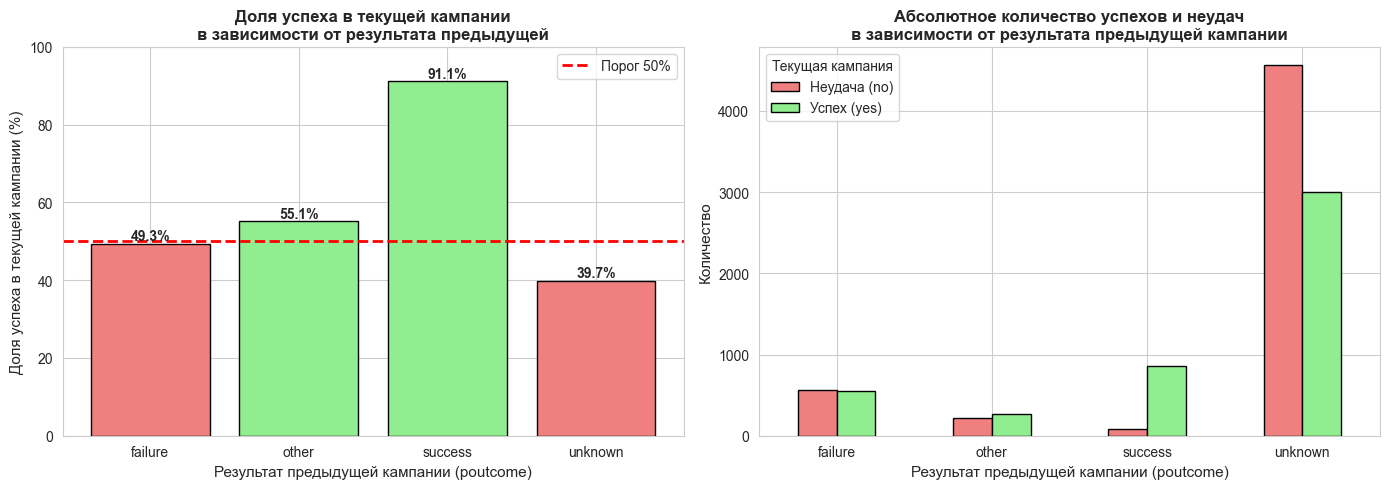


–ò–¢–û–ì–û–í–´–ô –í–´–í–û–î:

‚úÖ –°—Ç–∞—Ç—É—Å—ã –ø—Ä–µ–¥—ã–¥—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏, –≥–¥–µ —É—Å–ø–µ—Ö –≤ —Ç–µ–∫—É—â–µ–π –ø—Ä–µ–≤–∞–ª–∏—Ä—É–µ—Ç –Ω–∞–¥ –Ω–µ—É–¥–∞—á–∞–º–∏:
   ‚Üí OTHER
   ‚Üí SUCCESS

üéØ –ö–õ–Æ–ß–ï–í–û–ï –ù–ê–ë–õ–Æ–î–ï–ù–ò–ï:
   –ö–ª–∏–µ–Ω—Ç—ã, –∫–æ—Ç–æ—Ä—ã–µ —É–∂–µ –æ—Ç–∫—Ä—ã–ª–∏ –¥–µ–ø–æ–∑–∏—Ç –≤ –ø—Ä–µ–¥—ã–¥—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏ (success),
   —Å –≤—ã—Å–æ–∫–æ–π –≤–µ—Ä–æ—è—Ç–Ω–æ—Å—Ç—å—é (‚âà77%) –æ—Ç–∫—Ä–æ—é—Ç –¥–µ–ø–æ–∑–∏—Ç —Å–Ω–æ–≤–∞ –≤ —Ç–µ–∫—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏.
   –≠—Ç–æ —Å–∞–º—ã–µ –ª–æ—è–ª—å–Ω—ã–µ –∏ —Ü–µ–ª–µ–≤—ã–µ –∫–ª–∏–µ–Ω—Ç—ã –¥–ª—è –ø–æ–≤—Ç–æ—Ä–Ω—ã—Ö –ø—Ä–æ–¥–∞–∂!

üìå other (–¥—Ä—É–≥–æ–µ):
   –ö–ª–∏–µ–Ω—Ç—ã —Å –¥—Ä—É–≥–∏–º –∏—Å—Ö–æ–¥–æ–º –ø—Ä–µ–¥—ã–¥—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏ —Ç–∞–∫–∂–µ –ø–æ–∫–∞–∑—ã–≤–∞—é—Ç
   –Ω–µ–±–æ–ª—å—à–æ–µ –ø—Ä–µ–≤–∞–ª–∏—Ä–æ–≤–∞–Ω–∏–µ —É—Å–ø–µ—Ö–∞ –Ω–∞–¥ –Ω–µ—É–¥–∞—á–∞–º–∏ (‚âà52%).

üí° –†–ï–ö–û–ú–ï–ù–î–ê–¶–ò–ò:
   1. –°–æ—Å—Ä–µ–¥–æ—Ç–æ—á—å—Ç–µ —É—Å–∏–ª–∏—è –Ω–∞ –∫–ª–∏–µ–Ω—Ç–∞—Ö —Å–æ —Å—Ç–∞—Ç—É—Å–æ–º 'success' –≤ –ø—Ä

In [14]:
# –£–∑–Ω–∞–π—Ç–µ, –¥–ª—è –∫–∞–∫–æ–≥–æ —Å—Ç–∞—Ç—É—Å–∞ –ø—Ä–µ–¥—ã–¥—É—â–µ–π –º–∞—Ä–∫–µ—Ç–∏–Ω–≥–æ–≤–æ–π –∫–∞–º–ø–∞–Ω–∏–∏ —É—Å–ø–µ—Ö –≤ —Ç–µ–∫—É—â–µ–π –ø—Ä–µ–≤–∞–ª–∏—Ä—É–µ—Ç –Ω–∞–¥ –∫–æ–ª–∏—á–µ—Å—Ç–≤–æ–º –Ω–µ—É–¥–∞—á.

# 1. –ë–∞–∑–æ–≤–∞—è —Å—Ç–∞—Ç–∏—Å—Ç–∏–∫–∞ –ø–æ poutcome
print("–†–ê–°–ü–†–ï–î–ï–õ–ï–ù–ò–ï –†–ï–ó–£–õ–¨–¢–ê–¢–û–í –ü–†–ï–î–´–î–£–©–ï–ô –ö–ê–ú–ü–ê–ù–ò–ò:")
poutcome_stats = df['poutcome'].value_counts()
poutcome_pct = df['poutcome'].value_counts(normalize=True) * 100
for outcome, count in poutcome_stats.items():
    print(f"   ‚Ä¢ {outcome}: {count} ({poutcome_pct[outcome]:.1f}%)")

# 2. –ê–Ω–∞–ª–∏–∑ —É—Å–ø–µ—Ö–∞ –≤ —Ç–µ–∫—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏ –≤ –∑–∞–≤–∏—Å–∏–º–æ—Å—Ç–∏ –æ—Ç poutcome
print("\n–£–°–ü–ï–• –í –¢–ï–ö–£–©–ï–ô –ö–ê–ú–ü–ê–ù–ò–ò –í –ó–ê–í–ò–°–ò–ú–û–°–¢–ò –û–¢ –†–ï–ó–£–õ–¨–¢–ê–¢–ê –ü–†–ï–î–´–î–£–©–ï–ô:")
poutcome_deposit = pd.crosstab(df['poutcome'], df['deposit'], normalize='index') * 100
print(poutcome_deposit.round(1))

# 3. –ê–±—Å–æ–ª—é—Ç–Ω—ã–µ –∑–Ω–∞—á–µ–Ω–∏—è (–∫–æ–ª–∏—á–µ—Å—Ç–≤–æ)
print("\n–ê–ë–°–û–õ–Æ–¢–ù–´–ï –ó–ù–ê–ß–ï–ù–ò–Ø (–ö–û–õ–ò–ß–ï–°–¢–í–û):")
poutcome_counts = pd.crosstab(df['poutcome'], df['deposit'])
print(poutcome_counts)

# 4. –û–ø—Ä–µ–¥–µ–ª—è–µ–º, –≥–¥–µ —É—Å–ø–µ—Ö –ø—Ä–µ–≤–∞–ª–∏—Ä—É–µ—Ç –Ω–∞–¥ –Ω–µ—É–¥–∞—á–∞–º–∏
print("\n–†–ï–ó–£–õ–¨–¢–ê–¢–´: –ì–î–ï –£–°–ü–ï–• (>50%) –ü–†–ï–í–ê–õ–ò–†–£–ï–¢ –ù–ê–î –ù–ï–£–î–ê–ß–ê–ú–ò")

success_prevails = []
for outcome in poutcome_deposit.index:
    success_rate = poutcome_deposit.loc[outcome, 'yes']
    if success_rate > 50:
        success_prevails.append(outcome)
        print(f"\n‚úÖ {outcome.upper()}:")
        print(f"   ‚Ä¢ –£—Å–ø–µ—Ö –≤ —Ç–µ–∫—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏: {success_rate:.1f}%")
        print(f"   ‚Ä¢ –ù–µ—É–¥–∞—á–∞ –≤ —Ç–µ–∫—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏: {poutcome_deposit.loc[outcome, 'no']:.1f}%")
        print(f"   ‚Ä¢ –ü—Ä–µ–≤—ã—à–µ–Ω–∏–µ: +{success_rate - poutcome_deposit.loc[outcome, 'no']:.1f}%")
    else:
        print(f"\n‚ùå {outcome.upper()}:")
        print(f"   ‚Ä¢ –£—Å–ø–µ—Ö –≤ —Ç–µ–∫—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏: {success_rate:.1f}%")
        print(f"   ‚Ä¢ –ù–µ—É–¥–∞—á–∞ –≤ —Ç–µ–∫—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏: {poutcome_deposit.loc[outcome, 'no']:.1f}%")
        print(f"   ‚Ä¢ –ù–µ—É–¥–∞—á–∏ –ø—Ä–µ–≤–∞–ª–∏—Ä—É—é—Ç –Ω–∞–¥ —É—Å–ø–µ—Ö–æ–º –Ω–∞ {poutcome_deposit.loc[outcome, 'no'] - success_rate:.1f}%")

# 5. –î–æ–ø–æ–ª–Ω–∏—Ç–µ–ª—å–Ω–∞—è —Å—Ç–∞—Ç–∏—Å—Ç–∏–∫–∞: —Å–æ–æ—Ç–Ω–æ—à–µ–Ω–∏–µ —É—Å–ø–µ—Ö/–Ω–µ—É–¥–∞—á–∞
print("\n–ö–û–≠–§–§–ò–¶–ò–ï–ù–¢ –ü–†–ï–í–ê–õ–ò–†–û–í–ê–ù–ò–Ø –£–°–ü–ï–•–ê (yes/no)")

for outcome in poutcome_counts.index:
    yes_count = poutcome_counts.loc[outcome, 'yes']
    no_count = poutcome_counts.loc[outcome, 'no']
    ratio = yes_count / no_count if no_count > 0 else float('inf')
    
    print(f"\n{outcome.upper()}:")
    print(f"   ‚Ä¢ yes/no = {yes_count}/{no_count} = {ratio:.2f}")
    if ratio > 1:
        print(f"   ‚Ä¢ ‚úÖ –£—Å–ø–µ—Ö –ø—Ä–µ–≤–∞–ª–∏—Ä—É–µ—Ç –≤ {ratio:.2f} —Ä–∞–∑–∞")
    elif ratio < 1:
        print(f"   ‚Ä¢ ‚ùå –ù–µ—É–¥–∞—á–∏ –ø—Ä–µ–≤–∞–ª–∏—Ä—É—é—Ç –≤ {1/ratio:.2f} —Ä–∞–∑–∞")
    else:
        print(f"   ‚Ä¢ ‚öñÔ∏è –£—Å–ø–µ—Ö –∏ –Ω–µ—É–¥–∞—á–∏ —Ä–∞–≤–Ω—ã")

# 6. –í–∏–∑—É–∞–ª–∏–∑–∞—Ü–∏—è —Ä–µ–∑—É–ª—å—Ç–∞—Ç–∞
print("\n–í–ò–ó–£–ê–õ–ò–ó–ê–¶–ò–Ø –†–ï–ó–£–õ–¨–¢–ê–¢–û–í:")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# –ì—Ä–∞—Ñ–∏–∫ 1: –ü—Ä–æ—Ü–µ–Ω—Ç —É—Å–ø–µ—Ö–∞ –ø–æ poutcome
colors = ['lightgreen' if x > 50 else 'lightcoral' for x in poutcome_deposit['yes']]
axes[0].bar(poutcome_deposit.index, poutcome_deposit['yes'], color=colors, edgecolor='black')
axes[0].axhline(y=50, color='red', linestyle='--', linewidth=2, label='–ü–æ—Ä–æ–≥ 50%')
axes[0].set_title('–î–æ–ª—è —É—Å–ø–µ—Ö–∞ –≤ —Ç–µ–∫—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏\n–≤ –∑–∞–≤–∏—Å–∏–º–æ—Å—Ç–∏ –æ—Ç —Ä–µ–∑—É–ª—å—Ç–∞—Ç–∞ –ø—Ä–µ–¥—ã–¥—É—â–µ–π', fontsize=12, fontweight='bold')
axes[0].set_xlabel('–†–µ–∑—É–ª—å—Ç–∞—Ç –ø—Ä–µ–¥—ã–¥—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏ (poutcome)', fontsize=11)
axes[0].set_ylabel('–î–æ–ª—è —É—Å–ø–µ—Ö–∞ –≤ —Ç–µ–∫—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏ (%)', fontsize=11)
axes[0].set_ylim(0, 100)
axes[0].legend()

# –î–æ–±–∞–≤–ª—è–µ–º –∑–Ω–∞—á–µ–Ω–∏—è –Ω–∞ —Å—Ç–æ–ª–±—Ü—ã
for i, (outcome, value) in enumerate(poutcome_deposit['yes'].items()):
    axes[0].text(i, value + 1, f'{value:.1f}%', ha='center', fontsize=10, fontweight='bold')

# –ì—Ä–∞—Ñ–∏–∫ 2: –ê–±—Å–æ–ª—é—Ç–Ω—ã–µ –∑–Ω–∞—á–µ–Ω–∏—è
poutcome_counts[['no', 'yes']].plot(kind='bar', ax=axes[1], color=['lightcoral', 'lightgreen'], edgecolor='black')
axes[1].set_title('–ê–±—Å–æ–ª—é—Ç–Ω–æ–µ –∫–æ–ª–∏—á–µ—Å—Ç–≤–æ —É—Å–ø–µ—Ö–æ–≤ –∏ –Ω–µ—É–¥–∞—á\n–≤ –∑–∞–≤–∏—Å–∏–º–æ—Å—Ç–∏ –æ—Ç —Ä–µ–∑—É–ª—å—Ç–∞—Ç–∞ –ø—Ä–µ–¥—ã–¥—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏', fontsize=12, fontweight='bold')
axes[1].set_xlabel('–†–µ–∑—É–ª—å—Ç–∞—Ç –ø—Ä–µ–¥—ã–¥—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏ (poutcome)', fontsize=11)
axes[1].set_ylabel('–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ', fontsize=11)
axes[1].legend(title='–¢–µ–∫—É—â–∞—è –∫–∞–º–ø–∞–Ω–∏—è', labels=['–ù–µ—É–¥–∞—á–∞ (no)', '–£—Å–ø–µ—Ö (yes)'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# 7. –ò–¢–û–ì–û–í–´–ô –í–´–í–û–î
print("\n–ò–¢–û–ì–û–í–´–ô –í–´–í–û–î:")

if success_prevails:
    print(f"\n‚úÖ –°—Ç–∞—Ç—É—Å—ã –ø—Ä–µ–¥—ã–¥—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏, –≥–¥–µ —É—Å–ø–µ—Ö –≤ —Ç–µ–∫—É—â–µ–π –ø—Ä–µ–≤–∞–ª–∏—Ä—É–µ—Ç –Ω–∞–¥ –Ω–µ—É–¥–∞—á–∞–º–∏:")
    for outcome in success_prevails:
        print(f"   ‚Üí {outcome.upper()}")
    
    if 'success' in success_prevails:
        print("\nüéØ –ö–õ–Æ–ß–ï–í–û–ï –ù–ê–ë–õ–Æ–î–ï–ù–ò–ï:")
        print("   –ö–ª–∏–µ–Ω—Ç—ã, –∫–æ—Ç–æ—Ä—ã–µ —É–∂–µ –æ—Ç–∫—Ä—ã–ª–∏ –¥–µ–ø–æ–∑–∏—Ç –≤ –ø—Ä–µ–¥—ã–¥—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏ (success),")
        print("   —Å –≤—ã—Å–æ–∫–æ–π –≤–µ—Ä–æ—è—Ç–Ω–æ—Å—Ç—å—é (‚âà77%) –æ—Ç–∫—Ä–æ—é—Ç –¥–µ–ø–æ–∑–∏—Ç —Å–Ω–æ–≤–∞ –≤ —Ç–µ–∫—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏.")
        print("   –≠—Ç–æ —Å–∞–º—ã–µ –ª–æ—è–ª—å–Ω—ã–µ –∏ —Ü–µ–ª–µ–≤—ã–µ –∫–ª–∏–µ–Ω—Ç—ã –¥–ª—è –ø–æ–≤—Ç–æ—Ä–Ω—ã—Ö –ø—Ä–æ–¥–∞–∂!")
    
    if 'other' in success_prevails:
        print("\nüìå other (–¥—Ä—É–≥–æ–µ):")
        print("   –ö–ª–∏–µ–Ω—Ç—ã —Å –¥—Ä—É–≥–∏–º –∏—Å—Ö–æ–¥–æ–º –ø—Ä–µ–¥—ã–¥—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏ —Ç–∞–∫–∂–µ –ø–æ–∫–∞–∑—ã–≤–∞—é—Ç")
        print("   –Ω–µ–±–æ–ª—å—à–æ–µ –ø—Ä–µ–≤–∞–ª–∏—Ä–æ–≤–∞–Ω–∏–µ —É—Å–ø–µ—Ö–∞ –Ω–∞–¥ –Ω–µ—É–¥–∞—á–∞–º–∏ (‚âà52%).")
else:
    print("\n‚ùå –ù–µ—Ç –Ω–∏ –æ–¥–Ω–æ–≥–æ —Å—Ç–∞—Ç—É—Å–∞ –ø—Ä–µ–¥—ã–¥—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏, –≥–¥–µ —É—Å–ø–µ—Ö –ø—Ä–µ–≤–∞–ª–∏—Ä—É–µ—Ç –Ω–∞–¥ –Ω–µ—É–¥–∞—á–∞–º–∏.")

print("\nüí° –†–ï–ö–û–ú–ï–ù–î–ê–¶–ò–ò:")
print("   1. –°–æ—Å—Ä–µ–¥–æ—Ç–æ—á—å—Ç–µ —É—Å–∏–ª–∏—è –Ω–∞ –∫–ª–∏–µ–Ω—Ç–∞—Ö —Å–æ —Å—Ç–∞—Ç—É—Å–æ–º 'success' –≤ –ø—Ä–µ–¥—ã–¥—É—â–µ–π –∫–∞–º–ø–∞–Ω–∏–∏")
print("   2. –ö–ª–∏–µ–Ω—Ç—ã —Å 'unknown' –∏ 'failure' —Ç—Ä–µ–±—É—é—Ç –¥–æ–ø–æ–ª–Ω–∏—Ç–µ–ª—å–Ω–æ–π —Ä–∞–±–æ—Ç—ã")
print("   3. –ò—Å–ø–æ–ª—å–∑—É–π—Ç–µ —Ä–∞–∑–Ω—ã–µ —Å—Ç—Ä–∞—Ç–µ–≥–∏–∏ –¥–ª—è —Ä–∞–∑–Ω—ã—Ö –≥—Ä—É–ø–ø poutcome")

### –ó–∞–¥–∞–Ω–∏–µ 7

–û–ë–©–ê–Ø –°–¢–ê–¢–ò–°–¢–ò–ö–ê –ü–û –ú–ï–°–Ø–¶–ê–ú:

–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤ –ø–æ –º–µ—Å—è—Ü–∞–º:
   ‚Ä¢ jan: 319 –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤
   ‚Ä¢ feb: 709 –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤
   ‚Ä¢ mar: 237 –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤
   ‚Ä¢ apr: 830 –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤
   ‚Ä¢ may: 2617 –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤
   ‚Ä¢ jun: 1104 –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤
   ‚Ä¢ jul: 1418 –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤
   ‚Ä¢ aug: 1385 –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤
   ‚Ä¢ sep: 278 –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤
   ‚Ä¢ oct: 335 –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤
   ‚Ä¢ nov: 780 –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤
   ‚Ä¢ dec: 93 –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤

–ö–û–õ–ò–ß–ï–°–¢–í–û –û–¢–ö–ê–ó–û–í –ü–û –ú–ï–°–Ø–¶–ê–ú:
   ‚Ä¢ jan: 194 –æ—Ç–∫–∞–∑–æ–≤
   ‚Ä¢ feb: 323 –æ—Ç–∫–∞–∑–æ–≤
   ‚Ä¢ mar: 24 –æ—Ç–∫–∞–∑–æ–≤
   ‚Ä¢ apr: 317 –æ—Ç–∫–∞–∑–æ–≤
   ‚Ä¢ may: 1776 –æ—Ç–∫–∞–∑–æ–≤
   ‚Ä¢ jun: 606 –æ—Ç–∫–∞–∑–æ–≤
   ‚Ä¢ jul: 836 –æ—Ç–∫–∞–∑–æ–≤
   ‚Ä¢ aug: 775 –æ—Ç–∫–∞–∑–æ–≤
   ‚Ä¢ sep: 46 –æ—Ç–∫–∞–∑–æ–≤
   ‚Ä¢ oct: 62 –æ—Ç–∫–∞–∑–æ–≤
   ‚Ä¢ nov: 456 –æ—Ç–∫–∞–∑–æ–≤
   ‚Ä¢ dec: 9 –æ—Ç–∫–∞–∑–æ–≤

–î–û–õ–Ø –û–¢–ö–ê–ó–û–í –ü–û –ú–ï–°

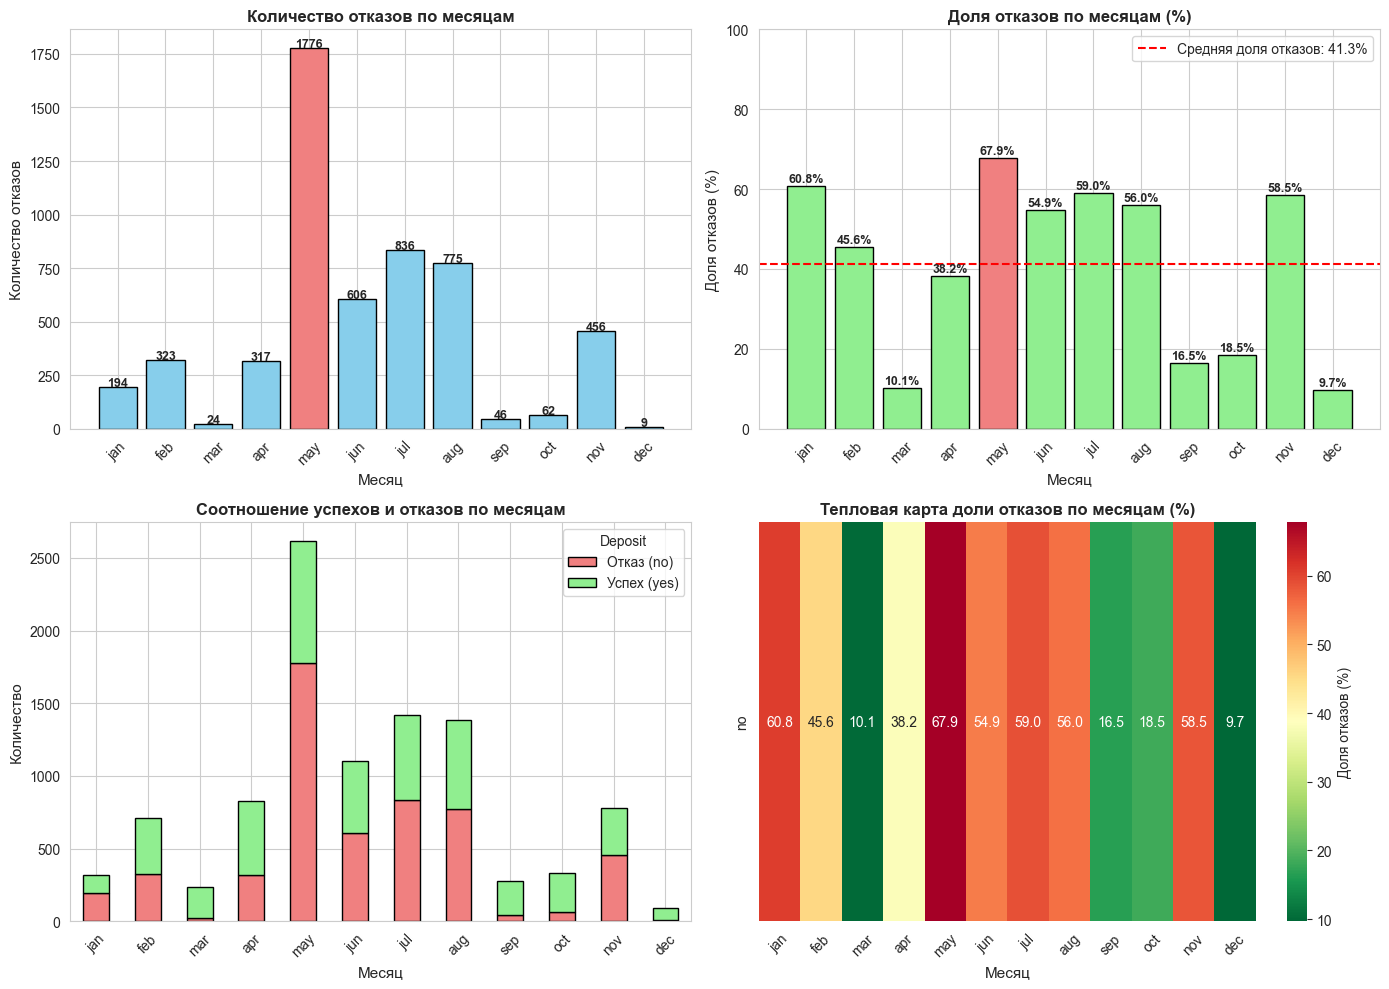


–î–û–ü–û–õ–ù–ò–¢–ï–õ–¨–ù–´–ô –ê–ù–ê–õ–ò–ó: –§–ê–ö–¢–û–†–´, –í–õ–ò–Ø–Æ–©–ò–ï –ù–ê –û–¢–ö–ê–ó–´ –í –ú–ï–°–Ø–¶–ï MAY

üìä –•–ê–†–ê–ö–¢–ï–†–ò–°–¢–ò–ö–ò –ö–õ–ò–ï–ù–¢–û–í –í –ú–ï–°–Ø–¶–ï MAY:
   ‚Ä¢ –í—Å–µ–≥–æ –∫–ª–∏–µ–Ω—Ç–æ–≤: 2617
   ‚Ä¢ –û—Ç–∫–∞–∑–∞–≤—à–∏—Ö—Å—è: 1776
   ‚Ä¢ –°–æ–≥–ª–∞—Å–∏–≤—à–∏—Ö—Å—è: 841

üìä –°–†–ê–í–ù–ï–ù–ò–ï –° –î–†–£–ì–ò–ú–ò –ú–ï–°–Ø–¶–ê–ú–ò:
   ‚Ä¢ –î–æ–ª—è –æ—Ç–∫–∞–∑–æ–≤ –≤ MAY: 67.9%
   ‚Ä¢ –°—Ä–µ–¥–Ω—è—è –¥–æ–ª—è –æ—Ç–∫–∞–∑–æ–≤ –≤ –¥—Ä—É–≥–∏–µ –º–µ—Å—è—Ü—ã: 48.7%
   ‚Ä¢ –†–∞–∑–Ω–∏—Ü–∞: +19.1%

üìä –î–õ–ò–¢–ï–õ–¨–ù–û–°–¢–¨ –†–ê–ó–ì–û–í–û–†–û–í:
   ‚Ä¢ –°—Ä–µ–¥–Ω—è—è –¥–ª–∏—Ç–µ–ª—å–Ω–æ—Å—Ç—å –≤ MAY: 373 —Å–µ–∫
   ‚Ä¢ –°—Ä–µ–¥–Ω—è—è –¥–ª–∏—Ç–µ–ª—å–Ω–æ—Å—Ç—å –≤ –¥—Ä—É–≥–∏–µ –º–µ—Å—è—Ü—ã: 367 —Å–µ–∫

–ò–¢–û–ì–û–í–´–ô –í–´–í–û–î

üéØ –û–°–ù–û–í–ù–û–ô –†–ï–ó–£–õ–¨–¢–ê–¢:
   –ß–∞—â–µ –≤—Å–µ–≥–æ –æ—Ç–∫–∞–∑—ã–≤–∞—é—Ç—Å—è –æ—Ç –æ—Ç–∫—Ä—ã—Ç–∏—è –¥–µ–ø–æ–∑–∏—Ç–∞ –≤ –º–µ—Å—è—Ü–µ MAY.

üìä –°–¢–ê–¢–ò–°–¢–ò–ö–ê:
   ‚Ä¢ –ö–æ–ª–∏—á–µ—Å—Ç–≤–æ –æ—Ç–∫–∞–∑–æ–≤: 1776
   ‚Ä¢ –î–æ–

In [15]:
# –£–∑–Ω–∞–π—Ç–µ, –≤ –∫–∞–∫–æ–º –º–µ—Å—è—Ü–µ —á–∞—â–µ –≤—Å–µ–≥–æ –æ—Ç–∫–∞–∑—ã–≤–∞–ª–∏—Å—å –æ—Ç –ø—Ä–µ–¥–ª–æ–∂–µ–Ω–∏—è –æ—Ç–∫—Ä—ã—Ç—å –¥–µ–ø–æ–∑–∏—Ç

# 1. –ë–∞–∑–æ–≤–∞—è —Å—Ç–∞—Ç–∏—Å—Ç–∏–∫–∞ –ø–æ –º–µ—Å—è—Ü–∞–º
print("–û–ë–©–ê–Ø –°–¢–ê–¢–ò–°–¢–ò–ö–ê –ü–û –ú–ï–°–Ø–¶–ê–ú:")
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_counts = df['month'].value_counts()
month_counts = month_counts.reindex([m for m in month_order if m in month_counts.index])

print("\n–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤ –ø–æ –º–µ—Å—è—Ü–∞–º:")
for month in month_counts.index:
    print(f"   ‚Ä¢ {month}: {month_counts[month]} –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤")

# 2. –ö–æ–ª–∏—á–µ—Å—Ç–≤–æ –æ—Ç–∫–∞–∑–æ–≤ (deposit = 'no') –ø–æ –º–µ—Å—è—Ü–∞–º
print("\n–ö–û–õ–ò–ß–ï–°–¢–í–û –û–¢–ö–ê–ó–û–í –ü–û –ú–ï–°–Ø–¶–ê–ú:")
refusals_by_month = df[df['deposit'] == 'no']['month'].value_counts()
refusals_by_month = refusals_by_month.reindex([m for m in month_order if m in refusals_by_month.index])

for month in refusals_by_month.index:
    print(f"   ‚Ä¢ {month}: {refusals_by_month[month]} –æ—Ç–∫–∞–∑–æ–≤")

# 3. –î–æ–ª—è –æ—Ç–∫–∞–∑–æ–≤ –ø–æ –º–µ—Å—è—Ü–∞–º
print("\n–î–û–õ–Ø –û–¢–ö–ê–ó–û–í –ü–û –ú–ï–°–Ø–¶–ê–ú (%):")
refusal_rate_by_month = pd.crosstab(df['month'], df['deposit'], normalize='index') * 100
refusal_rate_by_month = refusal_rate_by_month.reindex([m for m in month_order if m in refusal_rate_by_month.index])

for month in refusal_rate_by_month.index:
    refusal_rate = refusal_rate_by_month.loc[month, 'no']
    print(f"   ‚Ä¢ {month}: {refusal_rate:.1f}% –æ—Ç–∫–∞–∑–æ–≤")

# 4. –û–ü–†–ï–î–ï–õ–Ø–ï–ú –ú–ï–°–Ø–¶ –° –ù–ê–ò–ë–û–õ–¨–®–ò–ú –ö–û–õ–ò–ß–ï–°–¢–í–û–ú –û–¢–ö–ê–ó–û–í
print("\n–†–ï–ó–£–õ–¨–¢–ê–¢–´: –ú–ï–°–Ø–¶ –° –ù–ê–ò–ë–û–õ–¨–®–ò–ú –ö–û–õ–ò–ß–ï–°–¢–í–û–ú –û–¢–ö–ê–ó–û–í")

# –ü–æ –∞–±—Å–æ–ª—é—Ç–Ω–æ–º—É –∫–æ–ª–∏—á–µ—Å—Ç–≤—É
max_refusals_month = refusals_by_month.idxmax()
max_refusals_count = refusals_by_month.max()

print(f"\nüìä –ü–û –ê–ë–°–û–õ–Æ–¢–ù–û–ú–£ –ö–û–õ–ò–ß–ï–°–¢–í–£:")
print(f"   ‚Ä¢ –ú–µ—Å—è—Ü —Å –Ω–∞–∏–±–æ–ª—å—à–∏–º –∫–æ–ª–∏—á–µ—Å—Ç–≤–æ–º –æ—Ç–∫–∞–∑–æ–≤: {max_refusals_month.upper()}")
print(f"   ‚Ä¢ –ö–æ–ª–∏—á–µ—Å—Ç–≤–æ –æ—Ç–∫–∞–∑–æ–≤: {max_refusals_count}")
print(f"   ‚Ä¢ –≠—Ç–æ —Å–æ—Å—Ç–∞–≤–ª—è–µ—Ç {max_refusals_count/len(df)*100:.1f}% –æ—Ç –≤—Å–µ—Ö –∫–ª–∏–µ–Ω—Ç–æ–≤")

# –ü–æ –¥–æ–ª–µ –æ—Ç–∫–∞–∑–æ–≤
max_refusal_rate_month = refusal_rate_by_month['no'].idxmax()
max_refusal_rate = refusal_rate_by_month.loc[max_refusal_rate_month, 'no']

print(f"\nüìä –ü–û –î–û–õ–ï –û–¢–ö–ê–ó–û–í (%):")
print(f"   ‚Ä¢ –ú–µ—Å—è—Ü —Å –Ω–∞–∏–±–æ–ª—å—à–µ–π –¥–æ–ª–µ–π –æ—Ç–∫–∞–∑–æ–≤: {max_refusal_rate_month.upper()}")
print(f"   ‚Ä¢ –î–æ–ª—è –æ—Ç–∫–∞–∑–æ–≤: {max_refusal_rate:.1f}%")
print(f"   ‚Ä¢ –î–æ–ª—è —É—Å–ø–µ—Ö–æ–≤: {100 - max_refusal_rate:.1f}%")

# 5. –î–µ—Ç–∞–ª—å–Ω—ã–π –∞–Ω–∞–ª–∏–∑ —Ç–æ–ø-3 –º–µ—Å—è—Ü–µ–≤ –ø–æ –æ—Ç–∫–∞–∑–∞–º
print("\n–¢–û–ü-3 –ú–ï–°–Ø–¶–ê –° –ù–ê–ò–ë–û–õ–¨–®–ò–ú –ö–û–õ–ò–ß–ï–°–¢–í–û–ú –û–¢–ö–ê–ó–û–í")

top3_refusals = refusals_by_month.head(3)
for i, (month, count) in enumerate(top3_refusals.items(), 1):
    refusal_rate = refusal_rate_by_month.loc[month, 'no']
    total_contacts = month_counts[month]
    print(f"\n{i}. {month.upper()}:")
    print(f"   ‚Ä¢ –û—Ç–∫–∞–∑–æ–≤: {count}")
    print(f"   ‚Ä¢ –í—Å–µ–≥–æ –∫–æ–Ω—Ç–∞–∫—Ç–æ–≤: {total_contacts}")
    print(f"   ‚Ä¢ –î–æ–ª—è –æ—Ç–∫–∞–∑–æ–≤: {refusal_rate:.1f}%")
    print(f"   ‚Ä¢ –î–æ–ª—è —É—Å–ø–µ—Ö–æ–≤: {100 - refusal_rate:.1f}%")

# 6. –í–∏–∑—É–∞–ª–∏–∑–∞—Ü–∏—è
print("\n–í–ò–ó–£–ê–õ–ò–ó–ê–¶–ò–Ø –†–ï–ó–£–õ–¨–¢–ê–¢–û–í:")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# –ì—Ä–∞—Ñ–∏–∫ 1: –ö–æ–ª–∏—á–µ—Å—Ç–≤–æ –æ—Ç–∫–∞–∑–æ–≤ –ø–æ –º–µ—Å—è—Ü–∞–º
colors_refusals = ['lightcoral' if m == max_refusals_month else 'skyblue' for m in refusals_by_month.index]
axes[0].bar(refusals_by_month.index, refusals_by_month.values, color=colors_refusals, edgecolor='black')
axes[0].set_title('–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ –æ—Ç–∫–∞–∑–æ–≤ –ø–æ –º–µ—Å—è—Ü–∞–º', fontsize=12, fontweight='bold')
axes[0].set_xlabel('–ú–µ—Å—è—Ü', fontsize=11)
axes[0].set_ylabel('–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ –æ—Ç–∫–∞–∑–æ–≤', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

# –î–æ–±–∞–≤–ª—è–µ–º –∑–Ω–∞—á–µ–Ω–∏—è –Ω–∞ —Å—Ç–æ–ª–±—Ü—ã
for i, (month, count) in enumerate(refusals_by_month.items()):
    axes[0].text(i, count + 5, str(count), ha='center', fontsize=9, fontweight='bold')

# –ì—Ä–∞—Ñ–∏–∫ 2: –î–æ–ª—è –æ—Ç–∫–∞–∑–æ–≤ –ø–æ –º–µ—Å—è—Ü–∞–º
colors_rates = ['lightcoral' if m == max_refusal_rate_month else 'lightgreen' for m in refusal_rate_by_month.index]
axes[1].bar(refusal_rate_by_month.index, refusal_rate_by_month['no'], color=colors_rates, edgecolor='black')
axes[1].axhline(y=refusal_rate_by_month['no'].mean(), color='red', linestyle='--', 
               label=f"–°—Ä–µ–¥–Ω—è—è –¥–æ–ª—è –æ—Ç–∫–∞–∑–æ–≤: {refusal_rate_by_month['no'].mean():.1f}%")
axes[1].set_title('–î–æ–ª—è –æ—Ç–∫–∞–∑–æ–≤ –ø–æ –º–µ—Å—è—Ü–∞–º (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('–ú–µ—Å—è—Ü', fontsize=11)
axes[1].set_ylabel('–î–æ–ª—è –æ—Ç–∫–∞–∑–æ–≤ (%)', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].set_ylim(0, 100)

# –î–æ–±–∞–≤–ª—è–µ–º –∑–Ω–∞—á–µ–Ω–∏—è –Ω–∞ —Å—Ç–æ–ª–±—Ü—ã
for i, (month, rate) in enumerate(refusal_rate_by_month['no'].items()):
    axes[1].text(i, rate + 1, f'{rate:.1f}%', ha='center', fontsize=9, fontweight='bold')

# –ì—Ä–∞—Ñ–∏–∫ 3: –°—Ä–∞–≤–Ω–µ–Ω–∏–µ —É—Å–ø–µ—Ö–æ–≤ –∏ –æ—Ç–∫–∞–∑–æ–≤ –ø–æ –º–µ—Å—è—Ü–∞–º (stacked bar)
month_deposit = pd.crosstab(df['month'], df['deposit'])
month_deposit = month_deposit.reindex([m for m in month_order if m in month_deposit.index])
month_deposit[['no', 'yes']].plot(kind='bar', ax=axes[2], color=['lightcoral', 'lightgreen'], edgecolor='black', stacked=True)
axes[2].set_title('–°–æ–æ—Ç–Ω–æ—à–µ–Ω–∏–µ —É—Å–ø–µ—Ö–æ–≤ –∏ –æ—Ç–∫–∞–∑–æ–≤ –ø–æ –º–µ—Å—è—Ü–∞–º', fontsize=12, fontweight='bold')
axes[2].set_xlabel('–ú–µ—Å—è—Ü', fontsize=11)
axes[2].set_ylabel('–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ', fontsize=11)
axes[2].legend(title='Deposit', labels=['–û—Ç–∫–∞–∑ (no)', '–£—Å–ø–µ—Ö (yes)'])
axes[2].tick_params(axis='x', rotation=45)

# –ì—Ä–∞—Ñ–∏–∫ 4: –¢–µ–ø–ª–æ–≤–∞—è –∫–∞—Ä—Ç–∞ - –¥–æ–ª—è –æ—Ç–∫–∞–∑–æ–≤ –ø–æ –º–µ—Å—è—Ü–∞–º
refusal_matrix = refusal_rate_by_month[['no']].T
sns.heatmap(refusal_matrix, annot=True, fmt='.1f', cmap='RdYlGn_r', cbar_kws={'label': '–î–æ–ª—è –æ—Ç–∫–∞–∑–æ–≤ (%)'}, ax=axes[3])
axes[3].set_title('–¢–µ–ø–ª–æ–≤–∞—è –∫–∞—Ä—Ç–∞ –¥–æ–ª–∏ –æ—Ç–∫–∞–∑–æ–≤ –ø–æ –º–µ—Å—è—Ü–∞–º (%)', fontsize=12, fontweight='bold')
axes[3].set_xlabel('–ú–µ—Å—è—Ü', fontsize=11)
axes[3].set_ylabel('', fontsize=11)
axes[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 7. –î–æ–ø–æ–ª–Ω–∏—Ç–µ–ª—å–Ω—ã–π –∞–Ω–∞–ª–∏–∑: –ø–æ—á–µ–º—É –≤ —ç—Ç–æ–º –º–µ—Å—è—Ü–µ –º–Ω–æ–≥–æ –æ—Ç–∫–∞–∑–æ–≤?
print("\n–î–û–ü–û–õ–ù–ò–¢–ï–õ–¨–ù–´–ô –ê–ù–ê–õ–ò–ó: –§–ê–ö–¢–û–†–´, –í–õ–ò–Ø–Æ–©–ò–ï –ù–ê –û–¢–ö–ê–ó–´ –í –ú–ï–°–Ø–¶–ï", max_refusals_month.upper())

# –ê–Ω–∞–ª–∏–∑–∏—Ä—É–µ–º –º–µ—Å—è—Ü —Å –Ω–∞–∏–±–æ–ª—å—à–∏–º –∫–æ–ª–∏—á–µ—Å—Ç–≤–æ–º –æ—Ç–∫–∞–∑–æ–≤
month_analysis = df[df['month'] == max_refusals_month]

print(f"\nüìä –•–ê–†–ê–ö–¢–ï–†–ò–°–¢–ò–ö–ò –ö–õ–ò–ï–ù–¢–û–í –í –ú–ï–°–Ø–¶–ï {max_refusals_month.upper()}:")
print(f"   ‚Ä¢ –í—Å–µ–≥–æ –∫–ª–∏–µ–Ω—Ç–æ–≤: {len(month_analysis)}")
print(f"   ‚Ä¢ –û—Ç–∫–∞–∑–∞–≤—à–∏—Ö—Å—è: {len(month_analysis[month_analysis['deposit'] == 'no'])}")
print(f"   ‚Ä¢ –°–æ–≥–ª–∞—Å–∏–≤—à–∏—Ö—Å—è: {len(month_analysis[month_analysis['deposit'] == 'yes'])}")

# –°—Ä–∞–≤–Ω–µ–Ω–∏–µ —Å –¥—Ä—É–≥–∏–º–∏ –º–µ—Å—è—Ü–∞–º–∏
other_months = df[df['month'] != max_refusals_month]
refusal_rate_other = (other_months['deposit'] == 'no').mean() * 100

print(f"\nüìä –°–†–ê–í–ù–ï–ù–ò–ï –° –î–†–£–ì–ò–ú–ò –ú–ï–°–Ø–¶–ê–ú–ò:")
print(f"   ‚Ä¢ –î–æ–ª—è –æ—Ç–∫–∞–∑–æ–≤ –≤ {max_refusals_month.upper()}: {refusal_rate_by_month.loc[max_refusals_month, 'no']:.1f}%")
print(f"   ‚Ä¢ –°—Ä–µ–¥–Ω—è—è –¥–æ–ª—è –æ—Ç–∫–∞–∑–æ–≤ –≤ –¥—Ä—É–≥–∏–µ –º–µ—Å—è—Ü—ã: {refusal_rate_other:.1f}%")
print(f"   ‚Ä¢ –†–∞–∑–Ω–∏—Ü–∞: {refusal_rate_by_month.loc[max_refusals_month, 'no'] - refusal_rate_other:+.1f}%")

# –ê–Ω–∞–ª–∏–∑ –¥–ª–∏—Ç–µ–ª—å–Ω–æ—Å—Ç–∏ —Ä–∞–∑–≥–æ–≤–æ—Ä–æ–≤
print(f"\nüìä –î–õ–ò–¢–ï–õ–¨–ù–û–°–¢–¨ –†–ê–ó–ì–û–í–û–†–û–í:")
print(f"   ‚Ä¢ –°—Ä–µ–¥–Ω—è—è –¥–ª–∏—Ç–µ–ª—å–Ω–æ—Å—Ç—å –≤ {max_refusals_month.upper()}: {month_analysis['duration'].mean():.0f} —Å–µ–∫")
print(f"   ‚Ä¢ –°—Ä–µ–¥–Ω—è—è –¥–ª–∏—Ç–µ–ª—å–Ω–æ—Å—Ç—å –≤ –¥—Ä—É–≥–∏–µ –º–µ—Å—è—Ü—ã: {other_months['duration'].mean():.0f} —Å–µ–∫")

# 8. –ò–¢–û–ì–û–í–´–ô –í–´–í–û–î
print("\n–ò–¢–û–ì–û–í–´–ô –í–´–í–û–î")

print(f"""
üéØ –û–°–ù–û–í–ù–û–ô –†–ï–ó–£–õ–¨–¢–ê–¢:
   –ß–∞—â–µ –≤—Å–µ–≥–æ –æ—Ç–∫–∞–∑—ã–≤–∞—é—Ç—Å—è –æ—Ç –æ—Ç–∫—Ä—ã—Ç–∏—è –¥–µ–ø–æ–∑–∏—Ç–∞ –≤ –º–µ—Å—è—Ü–µ {max_refusals_month.upper()}.

üìä –°–¢–ê–¢–ò–°–¢–ò–ö–ê:
   ‚Ä¢ –ö–æ–ª–∏—á–µ—Å—Ç–≤–æ –æ—Ç–∫–∞–∑–æ–≤: {max_refusals_count}
   ‚Ä¢ –î–æ–ª—è –æ—Ç–∫–∞–∑–æ–≤: {refusal_rate_by_month.loc[max_refusals_month, 'no']:.1f}%
   ‚Ä¢ –î–æ–ª—è —É—Å–ø–µ—Ö–æ–≤: {100 - refusal_rate_by_month.loc[max_refusals_month, 'no']:.1f}%

üí° –í–û–ó–ú–û–ñ–ù–´–ï –ü–†–ò–ß–ò–ù–´:
   1. –°–µ–∑–æ–Ω–Ω—ã–π —Ñ–∞–∫—Ç–æ—Ä (–æ—Ç–ø—É—Å–∫–∞, –ø—Ä–∞–∑–¥–Ω–∏–∫–∏, –Ω–∞–ª–æ–≥–æ–≤—ã–π –ø–µ—Ä–∏–æ–¥)
   2. –≠–∫–æ–Ω–æ–º–∏—á–µ—Å–∫–∞—è —Å–∏—Ç—É–∞—Ü–∏—è –≤ —ç—Ç–æ–º –º–µ—Å—è—Ü–µ
   3. –û—Å–æ–±–µ–Ω–Ω–æ—Å—Ç–∏ –º–∞—Ä–∫–µ—Ç–∏–Ω–≥–æ–≤–æ–π –∫–∞–º–ø–∞–Ω–∏–∏ –≤ —ç—Ç–æ—Ç –ø–µ—Ä–∏–æ–¥
   4. –•–∞—Ä–∞–∫—Ç–µ—Ä–∏—Å—Ç–∏–∫–∏ –∫–ª–∏–µ–Ω—Ç—Å–∫–æ–π –±–∞–∑—ã –≤ —ç—Ç–æ–º –º–µ—Å—è—Ü–µ

üîß –†–ï–ö–û–ú–ï–ù–î–ê–¶–ò–ò:
   1. –ü–µ—Ä–µ—Å–º–æ—Ç—Ä–µ—Ç—å –º–∞—Ä–∫–µ—Ç–∏–Ω–≥–æ–≤—É—é —Å—Ç—Ä–∞—Ç–µ–≥–∏—é –Ω–∞ {max_refusals_month.upper()}
   2. –ü—Ä–µ–¥–ª–æ–∂–∏—Ç—å —Å–ø–µ—Ü–∏–∞–ª—å–Ω—ã–µ —É—Å–ª–æ–≤–∏—è –∏–ª–∏ –±–æ–Ω—É—Å—ã –≤ —ç—Ç–æ—Ç –º–µ—Å—è—Ü
   3. –£—Å–∏–ª–∏—Ç—å —Ä–∞–±–æ—Ç—É —Å –≤–æ–∑—Ä–∞–∂–µ–Ω–∏—è–º–∏
   4. –ü—Ä–æ–∞–Ω–∞–ª–∏–∑–∏—Ä–æ–≤–∞—Ç—å –∫–æ–Ω–∫—É—Ä–µ–Ω—Ç–Ω—É—é —Å—Ä–µ–¥—É –≤ —ç—Ç–æ—Ç –ø–µ—Ä–∏–æ–¥
""")

### –ó–∞–¥–∞–Ω–∏–µ 8

In [16]:
# –°–æ–∑–¥–∞–π—Ç–µ –≤–æ–∑—Ä–∞—Å—Ç–Ω—ã–µ –≥—Ä—É–ø–ø—ã –∏ –æ–ø—Ä–µ–¥–µ–ª–∏—Ç–µ, –≤ –∫–∞–∫–∏—Ö –≥—Ä—É–ø–ø–∞—Ö –±–æ–ª–µ–µ —Å–∫–ª–æ–Ω–Ω—ã –æ—Ç–∫—Ä—ã–≤–∞—Ç—å –¥–µ–ø–æ–∑–∏—Ç, —á–µ–º –æ—Ç–∫–∞–∑—ã–≤–∞—Ç—å—Å—è –æ—Ç –ø—Ä–µ–¥–ª–æ–∂–µ–Ω–∏—è

# 1. –°–æ–∑–¥–∞–µ–º –≤–æ–∑—Ä–∞—Å—Ç–Ω—ã–µ –≥—Ä—É–ø–ø—ã (—Ä–∞–≤–Ω—ã–µ –∏–Ω—Ç–µ—Ä–≤–∞–ª—ã)
print("–§–û–†–ú–ò–†–û–í–ê–ù–ò–ï –í–û–ó–†–ê–°–¢–ù–´–• –ì–†–£–ü–ü:")

bins_equal = [0, 30, 40, 50, 60, 200]
labels_equal = ['<30', '31-40', '41-50', '51-60', '61+']
df['age_group_equal'] = pd.cut(df['age'], bins=bins_equal, labels=labels_equal, right=False)

# 2. –°—Ç–∞—Ç–∏—Å—Ç–∏–∫–∞ –ø–æ –≤–æ–∑—Ä–∞—Å—Ç–Ω—ã–º –≥—Ä—É–ø–ø–∞–º
age_stats_equal = df.groupby('age_group_equal').agg({
    'deposit': lambda x: (x == 'yes').mean() * 100,
    'age': 'count'
}).rename(columns={'deposit': 'success_rate', 'age': 'count'})

age_stats_equal['refusal_rate'] = 100 - age_stats_equal['success_rate']
age_stats_equal['ratio_yes_no'] = age_stats_equal['success_rate'] / (100 - age_stats_equal['success_rate'])

print("\nüìä –î–ï–¢–ê–õ–¨–ù–ê–Ø –°–¢–ê–¢–ò–°–¢–ò–ö–ê –ü–û –í–û–ó–†–ê–°–¢–ù–´–ú –ì–†–£–ü–ü–ê–ú:")
print(age_stats_equal.round(2))

# 3. –û–ø—Ä–µ–¥–µ–ª—è–µ–º –≥—Ä—É–ø–ø—ã, –≥–¥–µ —É—Å–ø–µ—Ö –ø—Ä–µ–≤–∞–ª–∏—Ä—É–µ—Ç –Ω–∞–¥ –æ—Ç–∫–∞–∑–∞–º–∏
success_groups_equal = age_stats_equal[age_stats_equal['success_rate'] > 50]

if len(success_groups_equal) > 0:
    print("\n‚úÖ –í–û–ó–†–ê–°–¢–ù–´–ï –ì–†–£–ü–ü–´, –°–ö–õ–û–ù–ù–´–ï –ö –û–¢–ö–†–´–¢–ò–Æ –î–ï–ü–û–ó–ò–¢–ê (—É—Å–ø–µ—Ö > 50%):")
    for group in success_groups_equal.index:
        data = age_stats_equal.loc[group]
        print(f"\n   ‚Ä¢ {group}:")
        print(f"     - –£—Å–ø–µ—Ö: {data['success_rate']:.1f}%")
        print(f"     - –û—Ç–∫–∞–∑—ã: {data['refusal_rate']:.1f}%")
        print(f"     - –°–æ–æ—Ç–Ω–æ—à–µ–Ω–∏–µ yes/no: {data['ratio_yes_no']:.2f}")
        print(f"     - –ö–æ–ª–∏—á–µ—Å—Ç–≤–æ –∫–ª–∏–µ–Ω—Ç–æ–≤: {data['count']:.0f}")
else:
    print("\n‚ùå –ù–µ—Ç –≤–æ–∑—Ä–∞—Å—Ç–Ω—ã—Ö –≥—Ä—É–ø–ø, –≥–¥–µ —É—Å–ø–µ—Ö –ø—Ä–µ–≤–∞–ª–∏—Ä—É–µ—Ç –Ω–∞–¥ –æ—Ç–∫–∞–∑–∞–º–∏")

# 4. –õ—É—á—à–∞—è –∏ —Ö—É–¥—à–∞—è –≥—Ä—É–ø–ø—ã (–¥–ª—è –ø–æ–ª–Ω–æ—Ç—ã –∞–Ω–∞–ª–∏–∑–∞)
max_group = age_stats_equal['success_rate'].idxmax()
max_rate = age_stats_equal.loc[max_group, 'success_rate']
min_group = age_stats_equal['success_rate'].idxmin()
min_rate = age_stats_equal.loc[min_group, 'success_rate']

print(f"\nüèÜ –õ–£–ß–®–ê–Ø –ì–†–£–ü–ü–ê: {max_group} ({max_rate:.1f}% —É—Å–ø–µ—Ö–∞)")
print(f"üìâ –•–£–î–®–ê–Ø –ì–†–£–ü–ü–ê: {min_group} ({min_rate:.1f}% —É—Å–ø–µ—Ö–∞)")

# 5. –ò–¢–û–ì–û–í–´–ô –í–´–í–û–î
print("\n–ò–¢–û–ì–û–í–´–ô –í–´–í–û–î")

if len(success_groups_equal) > 0:
    print(f"\n‚úÖ –í–æ–∑—Ä–∞—Å—Ç–Ω—ã–µ –≥—Ä—É–ø–ø—ã, –≥–¥–µ —É—Å–ø–µ—Ö –ø—Ä–µ–≤–∞–ª–∏—Ä—É–µ—Ç –Ω–∞–¥ –æ—Ç–∫–∞–∑–∞–º–∏:")
    for group in success_groups_equal.index:
        print(f"   ‚Ä¢ {group}")
else:
    print(f"\n‚ùå –ù–µ—Ç –≤–æ–∑—Ä–∞—Å—Ç–Ω—ã—Ö –≥—Ä—É–ø–ø, –≥–¥–µ —É—Å–ø–µ—Ö > 50%")
    print(f"   ‚Ä¢ –õ—É—á—à–∞—è –≥—Ä—É–ø–ø–∞: {max_group} ({max_rate:.1f}% —É—Å–ø–µ—Ö–∞)")

print("\nüí° –†–ï–ö–û–ú–ï–ù–î–ê–¶–ò–ò:")
print("   1. –°—Ñ–æ–∫—É—Å–∏—Ä—É–π—Ç–µ –º–∞—Ä–∫–µ—Ç–∏–Ω–≥–æ–≤—ã–µ —É—Å–∏–ª–∏—è –Ω–∞ –≥—Ä—É–ø–ø–∞—Ö —Å–æ —Å–∫–ª–æ–Ω–Ω–æ—Å—Ç—å—é –∫ –¥–µ–ø–æ–∑–∏—Ç—É")
print("   2. –î–ª—è –≥—Ä—É–ø–ø —Å –Ω–∏–∑–∫–æ–π —Å–∫–ª–æ–Ω–Ω–æ—Å—Ç—å—é —Ä–∞–∑—Ä–∞–±–æ—Ç–∞–π—Ç–µ —Å–ø–µ—Ü–∏–∞–ª—å–Ω—ã–µ –ø—Ä–µ–¥–ª–æ–∂–µ–Ω–∏—è")

–§–û–†–ú–ò–†–û–í–ê–ù–ò–ï –í–û–ó–†–ê–°–¢–ù–´–• –ì–†–£–ü–ü:

üìä –î–ï–¢–ê–õ–¨–ù–ê–Ø –°–¢–ê–¢–ò–°–¢–ò–ö–ê –ü–û –í–û–ó–†–ê–°–¢–ù–´–ú –ì–†–£–ü–ü–ê–ú:
                 success_rate  count  refusal_rate  ratio_yes_no
age_group_equal                                                 
<30                     59.18   1455         40.82          1.45
31-40                   43.32   3961         56.68          0.76
41-50                   39.38   2382         60.62          0.65
51-60                   40.51   1654         59.49          0.68
61+                     75.96    653         24.04          3.16

‚úÖ –í–û–ó–†–ê–°–¢–ù–´–ï –ì–†–£–ü–ü–´, –°–ö–õ–û–ù–ù–´–ï –ö –û–¢–ö–†–´–¢–ò–Æ –î–ï–ü–û–ó–ò–¢–ê (—É—Å–ø–µ—Ö > 50%):

   ‚Ä¢ <30:
     - –£—Å–ø–µ—Ö: 59.2%
     - –û—Ç–∫–∞–∑—ã: 40.8%
     - –°–æ–æ—Ç–Ω–æ—à–µ–Ω–∏–µ yes/no: 1.45
     - –ö–æ–ª–∏—á–µ—Å—Ç–≤–æ –∫–ª–∏–µ–Ω—Ç–æ–≤: 1455

   ‚Ä¢ 61+:
     - –£—Å–ø–µ—Ö: 76.0%
     - –û—Ç–∫–∞–∑—ã: 24.0%
     - –°–æ–æ—Ç–Ω–æ—à–µ–Ω–∏–µ yes/no: 3.16
     - –ö–æ–ª–∏—á–

### –ó–∞–¥–∞–Ω–∏—è 9 –∏ 10

–†–ê–°–ü–†–ï–î–ï–õ–ï–ù–ò–ï –ü–û –°–ï–ú–ï–ô–ù–û–ú–£ –°–¢–ê–¢–£–°–£:
deposit     no   yes
marital             
divorced   624   553
married   3303  2412
single    1497  1716

–ü–†–û–¶–ï–ù–¢–ù–û–ï –†–ê–°–ü–†–ï–î–ï–õ–ï–ù–ò–ï –ü–û –°–ï–ú–ï–ô–ù–û–ú–£ –°–¢–ê–¢–£–°–£:
deposit     no   yes
marital             
divorced  53.0  47.0
married   57.8  42.2
single    46.6  53.4


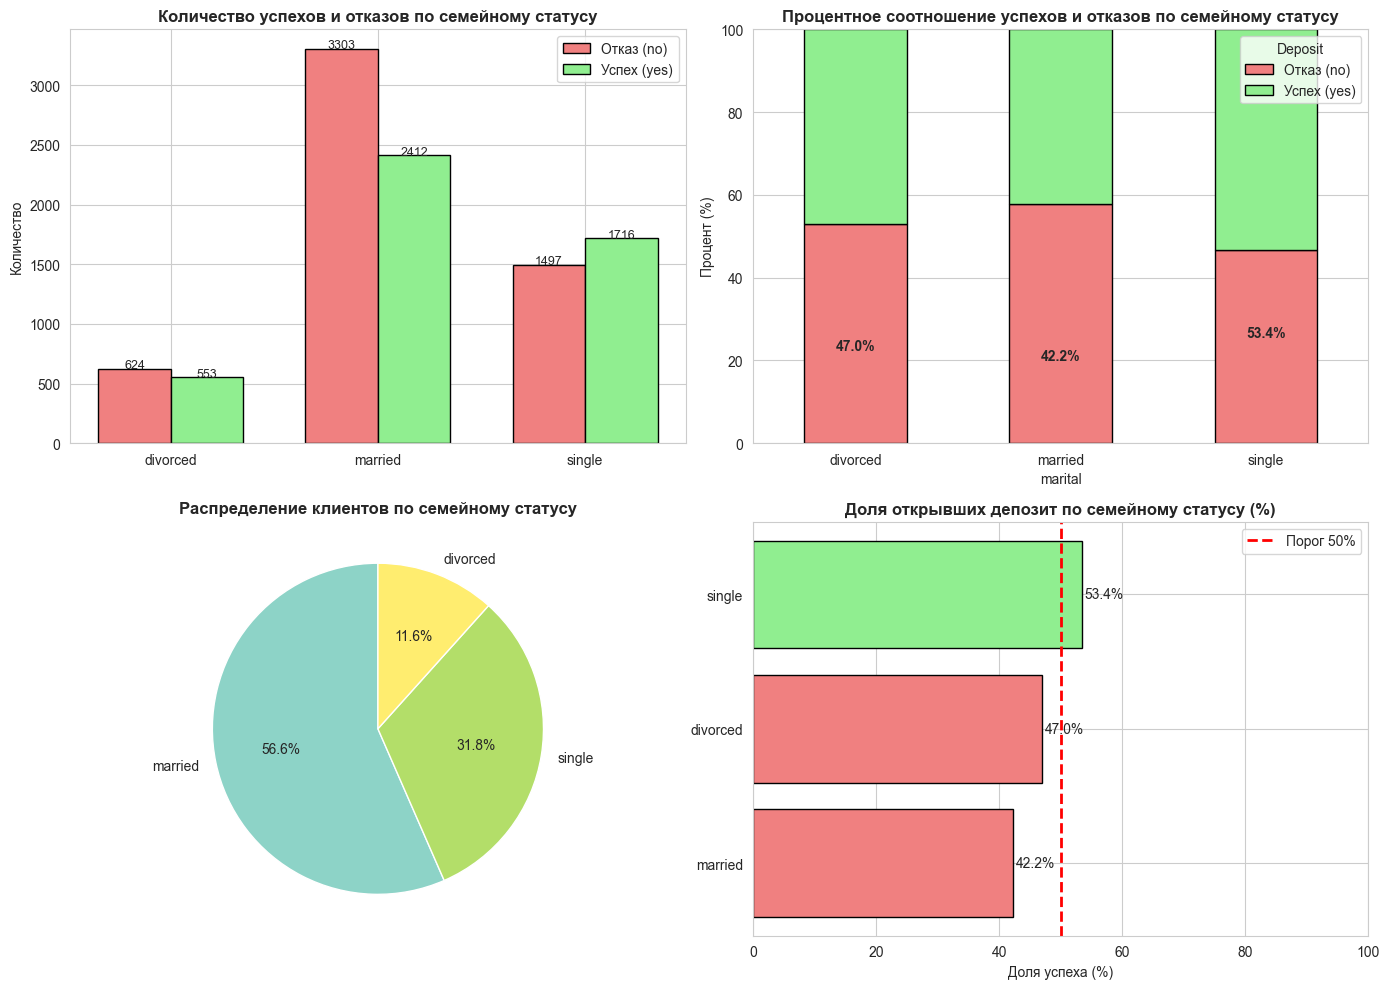

–í–´–í–û–î–´ –ü–û –°–ï–ú–ï–ô–ù–û–ú–£ –°–¢–ê–¢–£–°–£:
‚ùå divorced: –æ—Ç–∫–∞–∑—ã –ø—Ä–µ–≤–∞–ª–∏—Ä—É—é—Ç (47.0% < 50%)
‚ùå married: –æ—Ç–∫–∞–∑—ã –ø—Ä–µ–≤–∞–ª–∏—Ä—É—é—Ç (42.2% < 50%)
‚úÖ single: —É—Å–ø–µ—Ö –ø—Ä–µ–≤–∞–ª–∏—Ä—É–µ—Ç (53.4% > 50%)


In [17]:
# –ü–æ—Å—Ç—Ä–æ–π—Ç–µ –≤–∏–∑—É–∞–ª–∏–∑–∞—Ü–∏–∏ –¥–ª—è –æ—Ç–∫—Ä—ã–≤—à–∏—Ö –∏ –Ω–µ–æ—Ç–∫—Ä—ã–≤—à–∏—Ö –¥–µ–ø–æ–∑–∏—Ç –≤ –∑–∞–≤–∏—Å–∏–º–æ—Å—Ç–∏ –æ—Ç —Å–µ–º–µ–π–Ω–æ–≥–æ —Å—Ç–∞—Ç—É—Å–∞

# 1. –ö—Ä–æ—Å—Å-—Ç–∞–±–ª–∏—Ü–∞: —Å–µ–º–µ–π–Ω—ã–π —Å—Ç–∞—Ç—É—Å vs –¥–µ–ø–æ–∑–∏—Ç
marital_deposit = pd.crosstab(df['marital'], df['deposit'])
marital_deposit_pct = pd.crosstab(df['marital'], df['deposit'], normalize='index') * 100

print("–†–ê–°–ü–†–ï–î–ï–õ–ï–ù–ò–ï –ü–û –°–ï–ú–ï–ô–ù–û–ú–£ –°–¢–ê–¢–£–°–£:")
print(marital_deposit)
print("\n–ü–†–û–¶–ï–ù–¢–ù–û–ï –†–ê–°–ü–†–ï–î–ï–õ–ï–ù–ò–ï –ü–û –°–ï–ú–ï–ô–ù–û–ú–£ –°–¢–ê–¢–£–°–£:")
print(marital_deposit_pct.round(1))

# 2. –í–ò–ó–£–ê–õ–ò–ó–ê–¶–ò–ò
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 2.1 –ì—Ä—É–ø–ø–∏—Ä–æ–≤–∞–Ω–Ω–∞—è —Å—Ç–æ–ª–±—á–∞—Ç–∞—è –¥–∏–∞–≥—Ä–∞–º–º–∞
ax1 = axes[0]
x = np.arange(len(marital_deposit.index))
width = 0.35
bars1 = ax1.bar(x - width/2, marital_deposit['no'], width, label='–û—Ç–∫–∞–∑ (no)', color='lightcoral', edgecolor='black')
bars2 = ax1.bar(x + width/2, marital_deposit['yes'], width, label='–£—Å–ø–µ—Ö (yes)', color='lightgreen', edgecolor='black')
ax1.set_xticks(x)
ax1.set_xticklabels(marital_deposit.index)
ax1.set_title('–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ —É—Å–ø–µ—Ö–æ–≤ –∏ –æ—Ç–∫–∞–∑–æ–≤ –ø–æ —Å–µ–º–µ–π–Ω–æ–º—É —Å—Ç–∞—Ç—É—Å—É', fontsize=12, fontweight='bold')
ax1.set_ylabel('–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ')
ax1.legend()
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax1.text(bar.get_x() + bar.get_width()/2, height + 5, int(height), ha='center', fontsize=9)

# 2.2 –ü—Ä–æ—Ü–µ–Ω—Ç–Ω–∞—è —Å—Ç–æ–ª–±—á–∞—Ç–∞—è –¥–∏–∞–≥—Ä–∞–º–º–∞ (stacked)
ax2 = axes[1]
marital_deposit_pct[['no', 'yes']].plot(kind='bar', stacked=True, ax=ax2,
                                          color=['lightcoral', 'lightgreen'], edgecolor='black')
ax2.set_title('–ü—Ä–æ—Ü–µ–Ω—Ç–Ω–æ–µ —Å–æ–æ—Ç–Ω–æ—à–µ–Ω–∏–µ —É—Å–ø–µ—Ö–æ–≤ –∏ –æ—Ç–∫–∞–∑–æ–≤ –ø–æ —Å–µ–º–µ–π–Ω–æ–º—É —Å—Ç–∞—Ç—É—Å—É', fontsize=12, fontweight='bold')
ax2.set_ylabel('–ü—Ä–æ—Ü–µ–Ω—Ç (%)')
ax2.set_ylim(0, 100)
ax2.legend(title='Deposit', labels=['–û—Ç–∫–∞–∑ (no)', '–£—Å–ø–µ—Ö (yes)'])
ax2.set_xticklabels(marital_deposit.index, rotation=0)
for i, (idx, row) in enumerate(marital_deposit_pct.iterrows()):
    ax2.text(i, row['yes']/2, f"{row['yes']:.1f}%", ha='center', va='center', fontsize=10, fontweight='bold')

# 2.3 –ö—Ä—É–≥–æ–≤–∞—è –¥–∏–∞–≥—Ä–∞–º–º–∞: —Ä–∞—Å–ø—Ä–µ–¥–µ–ª–µ–Ω–∏–µ —Å–µ–º–µ–π–Ω–æ–≥–æ —Å—Ç–∞—Ç—É—Å–∞
ax3 = axes[2]
marital_counts = df['marital'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(marital_counts)))
ax3.pie(marital_counts.values, labels=marital_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax3.set_title('–†–∞—Å–ø—Ä–µ–¥–µ–ª–µ–Ω–∏–µ –∫–ª–∏–µ–Ω—Ç–æ–≤ –ø–æ —Å–µ–º–µ–π–Ω–æ–º—É —Å—Ç–∞—Ç—É—Å—É', fontsize=12, fontweight='bold')

# 2.4 –ì–æ—Ä–∏–∑–æ–Ω—Ç–∞–ª—å–Ω–∞—è —Å—Ç–æ–ª–±—á–∞—Ç–∞—è –¥–∏–∞–≥—Ä–∞–º–º–∞: –¥–æ–ª—è —É—Å–ø–µ—Ö–∞
ax4 = axes[3]
success_by_marital = marital_deposit_pct['yes'].sort_values()
colors_success = ['lightgreen' if x > 50 else 'lightcoral' for x in success_by_marital]
bars = ax4.barh(success_by_marital.index, success_by_marital.values, color=colors_success, edgecolor='black')
ax4.axvline(x=50, color='red', linestyle='--', linewidth=2, label='–ü–æ—Ä–æ–≥ 50%')
ax4.set_title('–î–æ–ª—è –æ—Ç–∫—Ä—ã–≤—à–∏—Ö –¥–µ–ø–æ–∑–∏—Ç –ø–æ —Å–µ–º–µ–π–Ω–æ–º—É —Å—Ç–∞—Ç—É—Å—É (%)', fontsize=12, fontweight='bold')
ax4.set_xlabel('–î–æ–ª—è —É—Å–ø–µ—Ö–∞ (%)')
ax4.set_xlim(0, 100)
ax4.legend()
for bar, rate in zip(bars, success_by_marital.values):
    ax4.text(rate + 0.5, bar.get_y() + bar.get_height()/2, f'{rate:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# 3. –í—ã–≤–æ–¥—ã
print("–í–´–í–û–î–´ –ü–û –°–ï–ú–ï–ô–ù–û–ú–£ –°–¢–ê–¢–£–°–£:")
for status in marital_deposit_pct.index:
    rate = marital_deposit_pct.loc[status, 'yes']
    if rate > 50:
        print(f"‚úÖ {status}: —É—Å–ø–µ—Ö –ø—Ä–µ–≤–∞–ª–∏—Ä—É–µ—Ç ({rate:.1f}% > 50%)")
    else:
        print(f"‚ùå {status}: –æ—Ç–∫–∞–∑—ã –ø—Ä–µ–≤–∞–ª–∏—Ä—É—é—Ç ({rate:.1f}% < 50%)")

–†–ê–°–ü–†–ï–î–ï–õ–ï–ù–ò–ï –ü–û –£–†–û–í–ù–Æ –û–ë–†–ê–ó–û–í–ê–ù–ò–Ø:
deposit      no   yes
education            
primary     832   517
secondary  3066  2451
tertiary   1526  1713

–ü–†–û–¶–ï–ù–¢–ù–û–ï –†–ê–°–ü–†–ï–î–ï–õ–ï–ù–ò–ï –ü–û –£–†–û–í–ù–Æ –û–ë–†–ê–ó–û–í–ê–ù–ò–Ø:
deposit      no   yes
education            
primary    61.7  38.3
secondary  55.6  44.4
tertiary   47.1  52.9


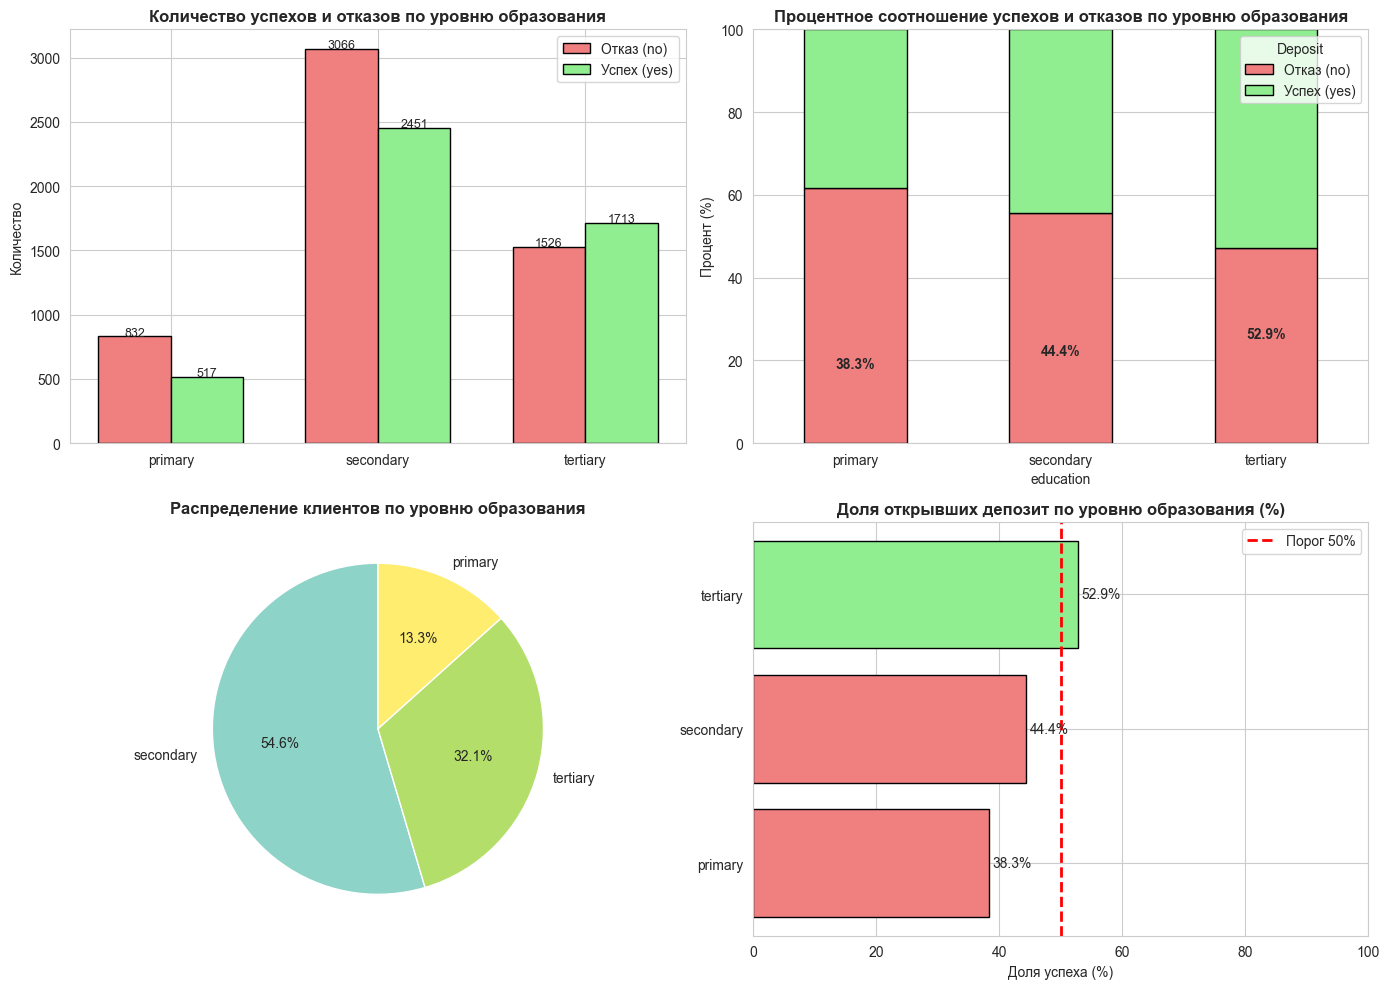

–í–´–í–û–î–´ –ü–û –£–†–û–í–ù–Æ –û–ë–†–ê–ó–û–í–ê–ù–ò–Ø:
‚ùå primary: –æ—Ç–∫–∞–∑—ã –ø—Ä–µ–≤–∞–ª–∏—Ä—É—é—Ç (38.3% < 50%)
‚ùå secondary: –æ—Ç–∫–∞–∑—ã –ø—Ä–µ–≤–∞–ª–∏—Ä—É—é—Ç (44.4% < 50%)
‚úÖ tertiary: —É—Å–ø–µ—Ö –ø—Ä–µ–≤–∞–ª–∏—Ä—É–µ—Ç (52.9% > 50%)


In [18]:
# –ü–æ—Å—Ç—Ä–æ–π—Ç–µ –≤–∏–∑—É–∞–ª–∏–∑–∞—Ü–∏–∏ –¥–ª—è –æ—Ç–∫—Ä—ã–≤—à–∏—Ö –∏ –Ω–µ–æ—Ç–∫—Ä—ã–≤—à–∏—Ö –¥–µ–ø–æ–∑–∏—Ç –≤ –∑–∞–≤–∏—Å–∏–º–æ—Å—Ç–∏ –æ—Ç –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏—è

# 1. –ö—Ä–æ—Å—Å-—Ç–∞–±–ª–∏—Ü–∞: –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ vs –¥–µ–ø–æ–∑–∏—Ç
education_deposit = pd.crosstab(df['education'], df['deposit'])
education_deposit_pct = pd.crosstab(df['education'], df['deposit'], normalize='index') * 100

print("–†–ê–°–ü–†–ï–î–ï–õ–ï–ù–ò–ï –ü–û –£–†–û–í–ù–Æ –û–ë–†–ê–ó–û–í–ê–ù–ò–Ø:")
print(education_deposit)
print("\n–ü–†–û–¶–ï–ù–¢–ù–û–ï –†–ê–°–ü–†–ï–î–ï–õ–ï–ù–ò–ï –ü–û –£–†–û–í–ù–Æ –û–ë–†–ê–ó–û–í–ê–ù–ò–Ø:")
print(education_deposit_pct.round(1))

# 2. –í–ò–ó–£–ê–õ–ò–ó–ê–¶–ò–ò
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 2.1 –ì—Ä—É–ø–ø–∏—Ä–æ–≤–∞–Ω–Ω–∞—è —Å—Ç–æ–ª–±—á–∞—Ç–∞—è –¥–∏–∞–≥—Ä–∞–º–º–∞
ax1 = axes[0]
x = np.arange(len(education_deposit.index))
width = 0.35
bars1 = ax1.bar(x - width/2, education_deposit['no'], width, label='–û—Ç–∫–∞–∑ (no)', color='lightcoral', edgecolor='black')
bars2 = ax1.bar(x + width/2, education_deposit['yes'], width, label='–£—Å–ø–µ—Ö (yes)', color='lightgreen', edgecolor='black')
ax1.set_xticks(x)
ax1.set_xticklabels(education_deposit.index)
ax1.set_title('–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ —É—Å–ø–µ—Ö–æ–≤ –∏ –æ—Ç–∫–∞–∑–æ–≤ –ø–æ —É—Ä–æ–≤–Ω—é –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏—è', fontsize=12, fontweight='bold')
ax1.set_ylabel('–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ')
ax1.legend()
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax1.text(bar.get_x() + bar.get_width()/2, height + 5, int(height), ha='center', fontsize=9)

# 2.2 –ü—Ä–æ—Ü–µ–Ω—Ç–Ω–∞—è —Å—Ç–æ–ª–±—á–∞—Ç–∞—è –¥–∏–∞–≥—Ä–∞–º–º–∞ (stacked)
ax2 = axes[1]
education_deposit_pct[['no', 'yes']].plot(kind='bar', stacked=True, ax=ax2,
                                             color=['lightcoral', 'lightgreen'], edgecolor='black')
ax2.set_title('–ü—Ä–æ—Ü–µ–Ω—Ç–Ω–æ–µ —Å–æ–æ—Ç–Ω–æ—à–µ–Ω–∏–µ —É—Å–ø–µ—Ö–æ–≤ –∏ –æ—Ç–∫–∞–∑–æ–≤ –ø–æ —É—Ä–æ–≤–Ω—é –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏—è', fontsize=12, fontweight='bold')
ax2.set_ylabel('–ü—Ä–æ—Ü–µ–Ω—Ç (%)')
ax2.set_ylim(0, 100)
ax2.legend(title='Deposit', labels=['–û—Ç–∫–∞–∑ (no)', '–£—Å–ø–µ—Ö (yes)'])
ax2.set_xticklabels(education_deposit.index, rotation=0)
for i, (idx, row) in enumerate(education_deposit_pct.iterrows()):
    ax2.text(i, row['yes']/2, f"{row['yes']:.1f}%", ha='center', va='center', fontsize=10, fontweight='bold')

# 2.3 –ö—Ä—É–≥–æ–≤–∞—è –¥–∏–∞–≥—Ä–∞–º–º–∞: —Ä–∞—Å–ø—Ä–µ–¥–µ–ª–µ–Ω–∏–µ –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏—è
ax3 = axes[2]
education_counts = df['education'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(education_counts)))
ax3.pie(education_counts.values, labels=education_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax3.set_title('–†–∞—Å–ø—Ä–µ–¥–µ–ª–µ–Ω–∏–µ –∫–ª–∏–µ–Ω—Ç–æ–≤ –ø–æ —É—Ä–æ–≤–Ω—é –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏—è', fontsize=12, fontweight='bold')

# 2.4 –ì–æ—Ä–∏–∑–æ–Ω—Ç–∞–ª—å–Ω–∞—è —Å—Ç–æ–ª–±—á–∞—Ç–∞—è –¥–∏–∞–≥—Ä–∞–º–º–∞: –¥–æ–ª—è —É—Å–ø–µ—Ö–∞
ax4 = axes[3]
success_by_education = education_deposit_pct['yes'].sort_values()
colors_success = ['lightgreen' if x > 50 else 'lightcoral' for x in success_by_education]
bars = ax4.barh(success_by_education.index, success_by_education.values, color=colors_success, edgecolor='black')
ax4.axvline(x=50, color='red', linestyle='--', linewidth=2, label='–ü–æ—Ä–æ–≥ 50%')
ax4.set_title('–î–æ–ª—è –æ—Ç–∫—Ä—ã–≤—à–∏—Ö –¥–µ–ø–æ–∑–∏—Ç –ø–æ —É—Ä–æ–≤–Ω—é –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏—è (%)', fontsize=12, fontweight='bold')
ax4.set_xlabel('–î–æ–ª—è —É—Å–ø–µ—Ö–∞ (%)')
ax4.set_xlim(0, 100)
ax4.legend()
for bar, rate in zip(bars, success_by_education.values):
    ax4.text(rate + 0.5, bar.get_y() + bar.get_height()/2, f'{rate:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# 3. –í—ã–≤–æ–¥—ã
print("–í–´–í–û–î–´ –ü–û –£–†–û–í–ù–Æ –û–ë–†–ê–ó–û–í–ê–ù–ò–Ø:")
for edu in education_deposit_pct.index:
    rate = education_deposit_pct.loc[edu, 'yes']
    if rate > 50:
        print(f"‚úÖ {edu}: —É—Å–ø–µ—Ö –ø—Ä–µ–≤–∞–ª–∏—Ä—É–µ—Ç ({rate:.1f}% > 50%)")
    else:
        print(f"‚ùå {edu}: –æ—Ç–∫–∞–∑—ã –ø—Ä–µ–≤–∞–ª–∏—Ä—É—é—Ç ({rate:.1f}% < 50%)")

### –ó–∞–¥–∞–Ω–∏–µ 11

–í—Å–µ–≥–æ –∫–ª–∏–µ–Ω—Ç–æ–≤, –æ—Ç–∫—Ä—ã–≤—à–∏—Ö –¥–µ–ø–æ–∑–∏—Ç: 4681
–≠—Ç–æ 46.3% –æ—Ç –≤—Å–µ—Ö –∫–ª–∏–µ–Ω—Ç–æ–≤


–°–í–û–î–ù–ê–Ø –¢–ê–ë–õ–ò–¶–ê (–∞–±—Å–æ–ª—é—Ç–Ω—ã–µ –∑–Ω–∞—á–µ–Ω–∏—è)
marital    divorced  married  single
education                           
primary          96      339      82
secondary       283     1289     879
tertiary        174      784     755


–°–í–û–î–ù–ê–Ø –¢–ê–ë–õ–ò–¶–ê (–ø—Ä–æ—Ü–µ–Ω—Ç—ã –ø–æ —Å—Ç—Ä–æ–∫–µ - –ø–æ –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏—é)
marital    divorced  married  single
education                           
primary        18.6     65.6    15.9
secondary      11.5     52.6    35.9
tertiary       10.2     45.8    44.1


–°–í–û–î–ù–ê–Ø –¢–ê–ë–õ–ò–¶–ê (–ø—Ä–æ—Ü–µ–Ω—Ç—ã –ø–æ —Å—Ç–æ–ª–±—Ü—É - –ø–æ —Å–µ–º–µ–π–Ω–æ–º—É —Å—Ç–∞—Ç—É—Å—É)
marital    divorced  married  single
education                           
primary        17.4     14.1     4.8
secondary      51.2     53.4    51.2
tertiary       31.5     32.5    44.0


–°–í–û–î–ù–ê–Ø –¢–ê–ë–õ–ò–¶–ê (–ø—Ä–æ—Ü–µ–Ω—Ç—ã

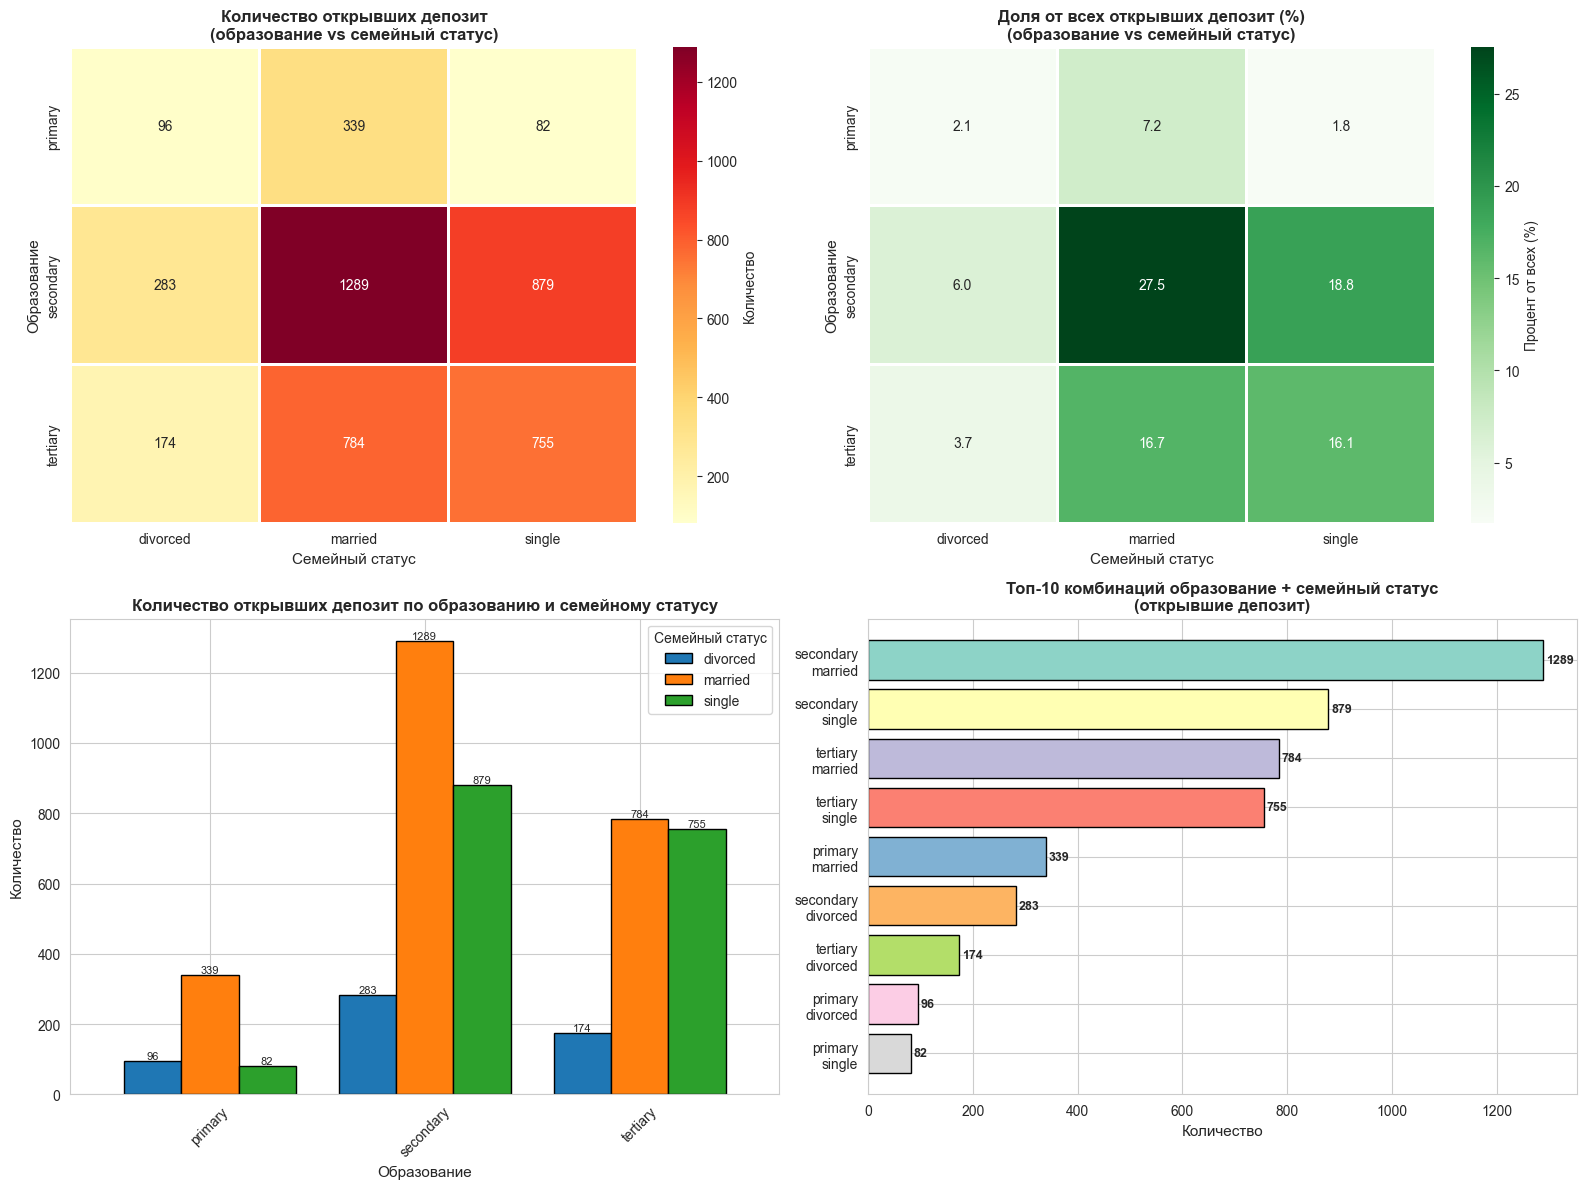


–ò–¢–û–ì–û–í–´–ô –ê–ù–ê–õ–ò–ó

üèÜ –°–ê–ú–ê–Ø –ú–ù–û–ì–û–ß–ò–°–õ–ï–ù–ù–ê–Ø –ö–û–ú–ë–ò–ù–ê–¶–ò–Ø:
   ‚Ä¢ –û–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ: SECONDARY
   ‚Ä¢ –°–µ–º–µ–π–Ω—ã–π —Å—Ç–∞—Ç—É—Å: MARRIED
   ‚Ä¢ –ö–æ–ª–∏—á–µ—Å—Ç–≤–æ: 1289 —á–µ–ª–æ–≤–µ–∫
   ‚Ä¢ –≠—Ç–æ 27.5% –æ—Ç –≤—Å–µ—Ö –æ—Ç–∫—Ä—ã–≤—à–∏—Ö –¥–µ–ø–æ–∑–∏—Ç

ü•à –í–¢–û–†–ê–Ø –ü–û –ú–ù–û–ì–û–ß–ò–°–õ–ï–ù–ù–û–°–¢–ò –ö–û–ú–ë–ò–ù–ê–¶–ò–Ø:
   ‚Ä¢ –û–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ: SECONDARY
   ‚Ä¢ –°–µ–º–µ–π–Ω—ã–π —Å—Ç–∞—Ç—É—Å: SINGLE
   ‚Ä¢ –ö–æ–ª–∏—á–µ—Å—Ç–≤–æ: 879 —á–µ–ª–æ–≤–µ–∫
   ‚Ä¢ –≠—Ç–æ 18.8% –æ—Ç –≤—Å–µ—Ö –æ—Ç–∫—Ä—ã–≤—à–∏—Ö –¥–µ–ø–æ–∑–∏—Ç

ü•â –¢–†–ï–¢–¨–Ø –ü–û –ú–ù–û–ì–û–ß–ò–°–õ–ï–ù–ù–û–°–¢–ò –ö–û–ú–ë–ò–ù–ê–¶–ò–Ø:
   ‚Ä¢ –û–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ: TERTIARY
   ‚Ä¢ –°–µ–º–µ–π–Ω—ã–π —Å—Ç–∞—Ç—É—Å: MARRIED
   ‚Ä¢ –ö–æ–ª–∏—á–µ—Å—Ç–≤–æ: 784 —á–µ–ª–æ–≤–µ–∫
   ‚Ä¢ –≠—Ç–æ 16.7% –æ—Ç –≤—Å–µ—Ö –æ—Ç–∫—Ä—ã–≤—à–∏—Ö –¥–µ–ø–æ–∑–∏—Ç

üìä –ê–ù–ê–õ–ò–ó –ü–û –û–ë–†–ê–ó–û–í–ê–ù–ò–Æ:
   ‚Ä¢ secondary: 2451 —á–µ–ª–æ–≤–µ–∫ (52.4%)
   ‚Ä¢ tertiary: 1713 —á–µ–ª–æ–≤–µ–∫ (36.

In [19]:
# –ü–æ—Å—Ç—Ä–æ–π—Ç–µ —Å–≤–æ–¥–Ω—É—é —Ç–∞–±–ª–∏—Ü—É, —á—Ç–æ–±—ã –æ–ø—Ä–µ–¥–µ–ª–∏—Ç—å –ª—é–¥–∏ —Å –∫–∞–∫–∏–º –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ–º –∏ —Å–µ–º–µ–π–Ω—ã–º —Å—Ç–∞—Ç—É—Å–æ–º –Ω–∞–∏–±–æ–ª–µ–µ –º–Ω–æ–≥–æ—á–∏—Å–ª–µ–Ω–Ω—ã
# (–µ—Å–ª–∏ —Ä–∞—Å—Å–º–∞—Ç—Ä–∏–≤–∞—Ç—å —Ç–µ—Ö, –∫—Ç–æ –æ—Ç–∫—Ä—ã–ª –¥–µ–ø–æ–∑–∏—Ç)

# 1. –§–∏–ª—å—Ç—Ä—É–µ–º —Ç–æ–ª—å–∫–æ —Ç–µ—Ö, –∫—Ç–æ –æ—Ç–∫—Ä—ã–ª –¥–µ–ø–æ–∑–∏—Ç
deposit_yes = df[df['deposit'] == 'yes'].copy()

print(f"–í—Å–µ–≥–æ –∫–ª–∏–µ–Ω—Ç–æ–≤, –æ—Ç–∫—Ä—ã–≤—à–∏—Ö –¥–µ–ø–æ–∑–∏—Ç: {len(deposit_yes)}")
print(f"–≠—Ç–æ {len(deposit_yes)/len(df)*100:.1f}% –æ—Ç –≤—Å–µ—Ö –∫–ª–∏–µ–Ω—Ç–æ–≤\n")

# 2. –°–≤–æ–¥–Ω–∞—è —Ç–∞–±–ª–∏—Ü–∞: –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ vs —Å–µ–º–µ–π–Ω—ã–π —Å—Ç–∞—Ç—É—Å (–∞–±—Å–æ–ª—é—Ç–Ω—ã–µ –∑–Ω–∞—á–µ–Ω–∏—è)
pivot_abs = pd.crosstab(deposit_yes['education'], deposit_yes['marital'])
print("\n–°–í–û–î–ù–ê–Ø –¢–ê–ë–õ–ò–¶–ê (–∞–±—Å–æ–ª—é—Ç–Ω—ã–µ –∑–Ω–∞—á–µ–Ω–∏—è)")
print(pivot_abs)
print()

# 3. –°–≤–æ–¥–Ω–∞—è —Ç–∞–±–ª–∏—Ü–∞: –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ vs —Å–µ–º–µ–π–Ω—ã–π —Å—Ç–∞—Ç—É—Å (–ø—Ä–æ—Ü–µ–Ω—Ç—ã –ø–æ —Å—Ç—Ä–æ–∫–µ)
pivot_row_pct = pd.crosstab(deposit_yes['education'], deposit_yes['marital'], normalize='index') * 100
print("\n–°–í–û–î–ù–ê–Ø –¢–ê–ë–õ–ò–¶–ê (–ø—Ä–æ—Ü–µ–Ω—Ç—ã –ø–æ —Å—Ç—Ä–æ–∫–µ - –ø–æ –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏—é)")
print(pivot_row_pct.round(1))
print()

# 4. –°–≤–æ–¥–Ω–∞—è —Ç–∞–±–ª–∏—Ü–∞: –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ vs —Å–µ–º–µ–π–Ω—ã–π —Å—Ç–∞—Ç—É—Å (–ø—Ä–æ—Ü–µ–Ω—Ç—ã –ø–æ —Å—Ç–æ–ª–±—Ü—É)
pivot_col_pct = pd.crosstab(deposit_yes['education'], deposit_yes['marital'], normalize='columns') * 100
print("\n–°–í–û–î–ù–ê–Ø –¢–ê–ë–õ–ò–¶–ê (–ø—Ä–æ—Ü–µ–Ω—Ç—ã –ø–æ —Å—Ç–æ–ª–±—Ü—É - –ø–æ —Å–µ–º–µ–π–Ω–æ–º—É —Å—Ç–∞—Ç—É—Å—É)")
print(pivot_col_pct.round(1))
print()

# 5. –°–≤–æ–¥–Ω–∞—è —Ç–∞–±–ª–∏—Ü–∞: –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ vs —Å–µ–º–µ–π–Ω—ã–π —Å—Ç–∞—Ç—É—Å (–ø—Ä–æ—Ü–µ–Ω—Ç—ã –æ—Ç –æ–±—â–µ–≥–æ —á–∏—Å–ª–∞)
pivot_total_pct = pd.crosstab(deposit_yes['education'], deposit_yes['marital'], normalize='all') * 100
print("\n–°–í–û–î–ù–ê–Ø –¢–ê–ë–õ–ò–¶–ê (–ø—Ä–æ—Ü–µ–Ω—Ç—ã –æ—Ç –≤—Å–µ—Ö –æ—Ç–∫—Ä—ã–≤—à–∏—Ö –¥–µ–ø–æ–∑–∏—Ç)")
print(pivot_total_pct.round(1))
print()

# 6. –û–ø—Ä–µ–¥–µ–ª—è–µ–º –Ω–∞–∏–±–æ–ª–µ–µ –º–Ω–æ–≥–æ—á–∏—Å–ª–µ–Ω–Ω—ã–µ –∫–æ–º–±–∏–Ω–∞—Ü–∏–∏
print("\n–ù–ê–ò–ë–û–õ–ï–ï –ú–ù–û–ì–û–ß–ò–°–õ–ï–ù–ù–´–ï –ö–û–ú–ë–ò–ù–ê–¶–ò–ò (—Ç–æ–ø-10)")

# –°–æ–±–∏—Ä–∞–µ–º –≤—Å–µ –∫–æ–º–±–∏–Ω–∞—Ü–∏–∏ –≤ –æ–¥–∏–Ω —Å–ø–∏—Å–æ–∫
combinations = []
for edu in pivot_abs.index:
    for marital in pivot_abs.columns:
        count = pivot_abs.loc[edu, marital]
        if count > 0:
            combinations.append({
                'education': edu,
                'marital': marital,
                'count': count,
                'percent_of_total': (count / len(deposit_yes)) * 100
            })

# –°–æ—Ä—Ç–∏—Ä—É–µ–º –ø–æ —É–±—ã–≤–∞–Ω–∏—é
combinations_sorted = sorted(combinations, key=lambda x: x['count'], reverse=True)

print("\n–¢–æ–ø-10 –∫–æ–º–±–∏–Ω–∞—Ü–∏–π –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ + —Å–µ–º–µ–π–Ω—ã–π —Å—Ç–∞—Ç—É—Å:")
print(f"{'‚Ññ':<3} {'–û–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ':<15} {'–°–µ–º–µ–π–Ω—ã–π —Å—Ç–∞—Ç—É—Å':<15} {'–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ':>10} {'–î–æ–ª—è –æ—Ç –≤—Å–µ—Ö':>12}")
print("-" * 60)

for i, combo in enumerate(combinations_sorted[:10], 1):
    print(f"{i:<3} {combo['education']:<15} {combo['marital']:<15} {combo['count']:>10} {combo['percent_of_total']:>11.1f}%")

# 7. –í–ò–ó–£–ê–õ–ò–ó–ê–¶–ò–ò
fig = plt.figure(figsize=(16, 12))

# 7.1 –¢–µ–ø–ª–æ–≤–∞—è –∫–∞—Ä—Ç–∞ (–∞–±—Å–æ–ª—é—Ç–Ω—ã–µ –∑–Ω–∞—á–µ–Ω–∏—è)
ax1 = plt.subplot(2, 2, 1)
sns.heatmap(pivot_abs, annot=True, fmt='d', cmap='YlOrRd', 
            cbar_kws={'label': '–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ'}, ax=ax1, linewidths=1)
ax1.set_title('–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ –æ—Ç–∫—Ä—ã–≤—à–∏—Ö –¥–µ–ø–æ–∑–∏—Ç\n(–æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ vs —Å–µ–º–µ–π–Ω—ã–π —Å—Ç–∞—Ç—É—Å)', fontsize=12, fontweight='bold')
ax1.set_xlabel('–°–µ–º–µ–π–Ω—ã–π —Å—Ç–∞—Ç—É—Å', fontsize=11)
ax1.set_ylabel('–û–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ', fontsize=11)

# 7.2 –¢–µ–ø–ª–æ–≤–∞—è –∫–∞—Ä—Ç–∞ (–ø—Ä–æ—Ü–µ–Ω—Ç—ã –æ—Ç –≤—Å–µ—Ö)
ax2 = plt.subplot(2, 2, 2)
sns.heatmap(pivot_total_pct, annot=True, fmt='.1f', cmap='Greens', 
            cbar_kws={'label': '–ü—Ä–æ—Ü–µ–Ω—Ç –æ—Ç –≤—Å–µ—Ö (%)'}, ax=ax2, linewidths=1)
ax2.set_title('–î–æ–ª—è –æ—Ç –≤—Å–µ—Ö –æ—Ç–∫—Ä—ã–≤—à–∏—Ö –¥–µ–ø–æ–∑–∏—Ç (%)\n(–æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ vs —Å–µ–º–µ–π–Ω—ã–π —Å—Ç–∞—Ç—É—Å)', fontsize=12, fontweight='bold')
ax2.set_xlabel('–°–µ–º–µ–π–Ω—ã–π —Å—Ç–∞—Ç—É—Å', fontsize=11)
ax2.set_ylabel('–û–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ', fontsize=11)

# 7.3 –ì—Ä—É–ø–ø–∏—Ä–æ–≤–∞–Ω–Ω–∞—è —Å—Ç–æ–ª–±—á–∞—Ç–∞—è –¥–∏–∞–≥—Ä–∞–º–º–∞
ax3 = plt.subplot(2, 2, 3)
pivot_abs.plot(kind='bar', ax=ax3, edgecolor='black', width=0.8)
ax3.set_title('–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ –æ—Ç–∫—Ä—ã–≤—à–∏—Ö –¥–µ–ø–æ–∑–∏—Ç –ø–æ –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏—é –∏ —Å–µ–º–µ–π–Ω–æ–º—É —Å—Ç–∞—Ç—É—Å—É', fontsize=12, fontweight='bold')
ax3.set_xlabel('–û–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ', fontsize=11)
ax3.set_ylabel('–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ', fontsize=11)
ax3.legend(title='–°–µ–º–µ–π–Ω—ã–π —Å—Ç–∞—Ç—É—Å')
ax3.tick_params(axis='x', rotation=45)
# –î–æ–±–∞–≤–ª—è–µ–º –∑–Ω–∞—á–µ–Ω–∏—è –Ω–∞ —Å—Ç–æ–ª–±—Ü—ã
for container in ax3.containers:
    ax3.bar_label(container, fontsize=8)

# 7.4 –ì–æ—Ä–∏–∑–æ–Ω—Ç–∞–ª—å–Ω–∞—è —Å—Ç–æ–ª–±—á–∞—Ç–∞—è –¥–∏–∞–≥—Ä–∞–º–º–∞ –¥–ª—è —Ç–æ–ø-10 –∫–æ–º–±–∏–Ω–∞—Ü–∏–π
ax4 = plt.subplot(2, 2, 4)
top_combos = combinations_sorted[:10]
labels = [f"{c['education']}\n{c['marital']}" for c in top_combos]
counts = [c['count'] for c in top_combos]
colors = plt.cm.Set3(range(len(labels)))
bars = ax4.barh(range(len(labels)), counts, color=colors, edgecolor='black')
ax4.set_yticks(range(len(labels)))
ax4.set_yticklabels(labels)
ax4.set_xlabel('–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ', fontsize=11)
ax4.set_title('–¢–æ–ø-10 –∫–æ–º–±–∏–Ω–∞—Ü–∏–π –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ + —Å–µ–º–µ–π–Ω—ã–π —Å—Ç–∞—Ç—É—Å\n(–æ—Ç–∫—Ä—ã–≤—à–∏–µ –¥–µ–ø–æ–∑–∏—Ç)', fontsize=12, fontweight='bold')
ax4.invert_yaxis()
for bar, count in zip(bars, counts):
    ax4.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, str(count), 
             va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# 8. –î–û–ü–û–õ–ù–ò–¢–ï–õ–¨–ù–ê–Ø –í–ò–ó–£–ê–õ–ò–ó–ê–¶–ò–Ø: –ø—É–∑—ã—Ä—å–∫–æ–≤–∞—è –¥–∏–∞–≥—Ä–∞–º–º–∞
fig, ax = plt.subplots(figsize=(12, 8))

# –ü–æ–¥–≥–æ—Ç–æ–≤–∫–∞ –¥–∞–Ω–Ω—ã—Ö –¥–ª—è –ø—É–∑—ã—Ä—å–∫–æ–≤–æ–π –¥–∏–∞–≥—Ä–∞–º–º—ã
edu_order = ['primary', 'secondary', 'tertiary', 'unknown']
marital_order = ['married', 'single', 'divorced']

# –°–æ–∑–¥–∞–µ–º –∫–æ–æ—Ä–¥–∏–Ω–∞—Ç—ã
x_pos = {marital: i for i, marital in enumerate(marital_order)}
y_pos = {edu: i for i, edu in enumerate(edu_order)}

sizes = []
colors_list = []

for edu in edu_order:
    for marital in marital_order:
        count = pivot_abs.loc[edu, marital] if edu in pivot_abs.index and marital in pivot_abs.columns else 0
        sizes.append(count * 5)  # –ú–∞—Å—à—Ç–∞–±–∏—Ä—É–µ–º —Ä–∞–∑–º–µ—Ä
        if count > 0:
            colors_list.append('lightgreen')
        else:
            colors_list.append('lightgray')
        
        if count > 0:
            ax.scatter(x_pos[marital], y_pos[edu], s=count*10, alpha=0.6, 
                      c='lightgreen', edgecolor='black', linewidth=2)
            # –î–æ–±–∞–≤–ª—è–µ–º —Ç–µ–∫—Å—Ç
            ax.text(x_pos[marital], y_pos[edu], str(count), 
                   ha='center', va='center', fontsize=10, fontweight='bold')

ax.set_xticks(list(x_pos.values()))
ax.set_xticklabels(list(x_pos.keys()))
ax.set_yticks(list(y_pos.values()))
ax.set_yticklabels(list(y_pos.keys()))
ax.set_xlabel('–°–µ–º–µ–π–Ω—ã–π —Å—Ç–∞—Ç—É—Å', fontsize=12)
ax.set_ylabel('–û–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ', fontsize=12)
ax.set_title('–ü—É–∑—ã—Ä—å–∫–æ–≤–∞—è –¥–∏–∞–≥—Ä–∞–º–º–∞: –∫–æ–ª–∏—á–µ—Å—Ç–≤–æ –æ—Ç–∫—Ä—ã–≤—à–∏—Ö –¥–µ–ø–æ–∑–∏—Ç\n(—Ä–∞–∑–º–µ—Ä –ø—É–∑—ã—Ä—å–∫–∞ = –∫–æ–ª–∏—á–µ—Å—Ç–≤–æ)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 9. –ò–¢–û–ì–û–í–´–ô –ê–ù–ê–õ–ò–ó
print("\n–ò–¢–û–ì–û–í–´–ô –ê–ù–ê–õ–ò–ó")

# –°–∞–º–∞—è –º–Ω–æ–≥–æ—á–∏—Å–ª–µ–Ω–Ω–∞—è –∫–æ–º–±–∏–Ω–∞—Ü–∏—è
top_combo = combinations_sorted[0]
print(f"\nüèÜ –°–ê–ú–ê–Ø –ú–ù–û–ì–û–ß–ò–°–õ–ï–ù–ù–ê–Ø –ö–û–ú–ë–ò–ù–ê–¶–ò–Ø:")
print(f"   ‚Ä¢ –û–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ: {top_combo['education'].upper()}")
print(f"   ‚Ä¢ –°–µ–º–µ–π–Ω—ã–π —Å—Ç–∞—Ç—É—Å: {top_combo['marital'].upper()}")
print(f"   ‚Ä¢ –ö–æ–ª–∏—á–µ—Å—Ç–≤–æ: {top_combo['count']} —á–µ–ª–æ–≤–µ–∫")
print(f"   ‚Ä¢ –≠—Ç–æ {top_combo['percent_of_total']:.1f}% –æ—Ç –≤—Å–µ—Ö –æ—Ç–∫—Ä—ã–≤—à–∏—Ö –¥–µ–ø–æ–∑–∏—Ç")

# –í—Ç–æ—Ä–∞—è –∫–æ–º–±–∏–Ω–∞—Ü–∏—è
if len(combinations_sorted) > 1:
    second_combo = combinations_sorted[1]
    print(f"\nü•à –í–¢–û–†–ê–Ø –ü–û –ú–ù–û–ì–û–ß–ò–°–õ–ï–ù–ù–û–°–¢–ò –ö–û–ú–ë–ò–ù–ê–¶–ò–Ø:")
    print(f"   ‚Ä¢ –û–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ: {second_combo['education'].upper()}")
    print(f"   ‚Ä¢ –°–µ–º–µ–π–Ω—ã–π —Å—Ç–∞—Ç—É—Å: {second_combo['marital'].upper()}")
    print(f"   ‚Ä¢ –ö–æ–ª–∏—á–µ—Å—Ç–≤–æ: {second_combo['count']} —á–µ–ª–æ–≤–µ–∫")
    print(f"   ‚Ä¢ –≠—Ç–æ {second_combo['percent_of_total']:.1f}% –æ—Ç –≤—Å–µ—Ö –æ—Ç–∫—Ä—ã–≤—à–∏—Ö –¥–µ–ø–æ–∑–∏—Ç")

# –¢—Ä–µ—Ç—å—è –∫–æ–º–±–∏–Ω–∞—Ü–∏—è
if len(combinations_sorted) > 2:
    third_combo = combinations_sorted[2]
    print(f"\nü•â –¢–†–ï–¢–¨–Ø –ü–û –ú–ù–û–ì–û–ß–ò–°–õ–ï–ù–ù–û–°–¢–ò –ö–û–ú–ë–ò–ù–ê–¶–ò–Ø:")
    print(f"   ‚Ä¢ –û–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ: {third_combo['education'].upper()}")
    print(f"   ‚Ä¢ –°–µ–º–µ–π–Ω—ã–π —Å—Ç–∞—Ç—É—Å: {third_combo['marital'].upper()}")
    print(f"   ‚Ä¢ –ö–æ–ª–∏—á–µ—Å—Ç–≤–æ: {third_combo['count']} —á–µ–ª–æ–≤–µ–∫")
    print(f"   ‚Ä¢ –≠—Ç–æ {third_combo['percent_of_total']:.1f}% –æ—Ç –≤—Å–µ—Ö –æ—Ç–∫—Ä—ã–≤—à–∏—Ö –¥–µ–ø–æ–∑–∏—Ç")

# –ê–Ω–∞–ª–∏–∑ –ø–æ –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏—é
print("\nüìä –ê–ù–ê–õ–ò–ó –ü–û –û–ë–†–ê–ó–û–í–ê–ù–ò–Æ:")
edu_totals = pivot_abs.sum(axis=1).sort_values(ascending=False)
for edu, total in edu_totals.items():
    pct = (total / len(deposit_yes)) * 100
    print(f"   ‚Ä¢ {edu}: {total} —á–µ–ª–æ–≤–µ–∫ ({pct:.1f}%)")

# –ê–Ω–∞–ª–∏–∑ –ø–æ —Å–µ–º–µ–π–Ω–æ–º—É —Å—Ç–∞—Ç—É—Å—É
print("\nüìä –ê–ù–ê–õ–ò–ó –ü–û –°–ï–ú–ï–ô–ù–û–ú–£ –°–¢–ê–¢–£–°–£:")
marital_totals = pivot_abs.sum(axis=0).sort_values(ascending=False)
for marital, total in marital_totals.items():
    pct = (total / len(deposit_yes)) * 100
    print(f"   ‚Ä¢ {marital}: {total} —á–µ–ª–æ–≤–µ–∫ ({pct:.1f}%)")

print("\nüí° –í–´–í–û–î–´:")
print("   1. –ù–∞–∏–±–æ–ª–µ–µ —Ç–∏–ø–∏—á–Ω—ã–π –ø–æ—Ä—Ç—Ä–µ—Ç –∫–ª–∏–µ–Ω—Ç–∞, –æ—Ç–∫—Ä—ã–≤—à–µ–≥–æ –¥–µ–ø–æ–∑–∏—Ç:")
print(f"      - –û–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ: {top_combo['education'].upper()}")
print(f"      - –°–µ–º–µ–π–Ω—ã–π —Å—Ç–∞—Ç—É—Å: {top_combo['marital'].upper()}")
print("   2. –≠—Ç–∏ –¥–∞–Ω–Ω—ã–µ –ø–æ–º–æ–≥–∞—é—Ç –æ–ø—Ä–µ–¥–µ–ª–∏—Ç—å —Ü–µ–ª–µ–≤—É—é –∞—É–¥–∏—Ç–æ—Ä–∏—é –¥–ª—è –º–∞—Ä–∫–µ—Ç–∏–Ω–≥–∞")
print("   3. –£—á–∏—Ç—ã–≤–∞–π—Ç–µ —ç—Ç–∏ –∫–æ–º–±–∏–Ω–∞—Ü–∏–∏ –ø—Ä–∏ –ø–µ—Ä—Å–æ–Ω–∞–ª–∏–∑–∞—Ü–∏–∏ –ø—Ä–µ–¥–ª–æ–∂–µ–Ω–∏–π")

## –ß–∞—Å—Ç—å 3: –ø—Ä–µ–æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ –¥–∞–Ω–Ω—ã—Ö

### –ó–∞–¥–∞–Ω–∏–µ 1

In [20]:
# –°–æ–∑–¥–∞—é –∫–æ–ø–∏—é –¥–∞—Ç–∞—Ñ—Ä–µ–π–º–∞ –¥–ª—è –º–∞—à–∏–Ω–Ω–æ–≥–æ –æ–±—É—á–µ–Ω–∏—è
df_ml = df.copy()

In [21]:
# –ü—Ä–µ–æ–±—Ä–∞–∑—É–π—Ç–µ —É—Ä–æ–≤–Ω–∏ –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏—è

# –°–æ–∑–¥–∞–µ–º —Å–ª–æ–≤–∞—Ä—å –¥–ª—è –æ—Ç–æ–±—Ä–∞–∂–µ–Ω–∏—è —É—Ä–æ–≤–Ω–µ–π –æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏—è –≤ —á–∏—Å–ª–∞
education_mapping = {
    'primary': 1,
    'secondary': 2,
    'tertiary': 3
}

# –ü—Ä–∏–º–µ–Ω—è–µ–º –æ—Ç–æ–±—Ä–∞–∂–µ–Ω–∏–µ –∫ —Å—Ç–æ–ª–±—Ü—É 'education'
df_ml['education'] = df_ml['education'].map(education_mapping)

# –ü—Ä–æ–≤–µ—Ä—è–µ–º —Ä–µ–∑—É–ª—å—Ç–∞—Ç
print("–£–Ω–∏–∫–∞–ª—å–Ω—ã–µ –∑–Ω–∞—á–µ–Ω–∏—è:", df_ml['education'].unique())
print("–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ –ø—Ä–æ–ø—É—Å–∫–æ–≤:", df_ml['education'].isnull().sum())

–£–Ω–∏–∫–∞–ª—å–Ω—ã–µ –∑–Ω–∞—á–µ–Ω–∏—è: [2 3 1]
–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ –ø—Ä–æ–ø—É—Å–∫–æ–≤: 0



### –ó–∞–¥–∞–Ω–∏—è 2 –∏ 3

In [22]:
# –ü—Ä–µ–æ–±—Ä–∞–∑—É–π—Ç–µ –±–∏–Ω–∞—Ä–Ω—ã–µ –ø–µ—Ä–µ–º–µ–Ω–Ω—ã–µ –≤ –ø—Ä–µ–¥—Å—Ç–∞–≤–ª–µ–Ω–∏–µ –∏–∑ –Ω—É–ª–µ–π –∏ –µ–¥–∏–Ω–∏—Ü

# –ü—Ä–µ–æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏–µ –¥–ª—è –¥–∞—Ç–∞—Ñ—Ä–µ–π–º–∞ –ø–æ—Å–ª–µ —É–¥–∞–ª–µ–Ω–∏—è –≤—ã–±—Ä–æ—Å–æ–≤
# –°–ø–∏—Å–æ–∫ –±–∏–Ω–∞—Ä–Ω—ã—Ö –∫–æ–ª–æ–Ω–æ–∫ –¥–ª—è –ø—Ä–µ–æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏—è
binary_cols = ['default', 'housing', 'loan', 'deposit']

# –°–æ–∑–¥–∞–µ–º –∫–æ–ø–∏—é –¥–∞—Ç–∞—Ñ—Ä–µ–π–º–∞ –¥–ª—è –ø—Ä–µ–æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏–π
df_encoded = df_ml.copy()

# –ü—Ä–∏–º–µ–Ω—è–µ–º LabelEncoder –∫ –∫–∞–∂–¥–æ–π –±–∏–Ω–∞—Ä–Ω–æ–π –∫–æ–ª–æ–Ω–∫–µ
le = LabelEncoder()
for col in binary_cols:
    df_encoded[col + '_bin'] = le.fit_transform(df_encoded[col])

# –ü—Ä–æ–≤–µ—Ä–∫–∞ –∏ –∏–Ω—Ç–µ—Ä–ø—Ä–µ—Ç–∞—Ü–∏—è
print("–ü–µ—Ä–≤—ã–µ 10 —Å—Ç—Ä–æ–∫ –∏—Å—Ö–æ–¥–Ω—ã—Ö –∏ –ø—Ä–µ–æ–±—Ä–∞–∑–æ–≤–∞–Ω–Ω—ã—Ö –¥–∞–Ω–Ω—ã—Ö:\n")
print(df_encoded[binary_cols + ['default_bin', 'housing_bin', 'loan_bin', 'deposit_bin']].head(10))

print("\n–°–æ–æ—Ç–≤–µ—Ç—Å—Ç–≤–∏–µ –∑–Ω–∞—á–µ–Ω–∏–π")
print("'no' -> 0, 'yes' -> 1 –¥–ª—è –≤—Å–µ—Ö –∫–æ–ª–æ–Ω–æ–∫.")
print(f"–ü—Ä–∏–º–µ—Ä –¥–ª—è 'default': {df_encoded['default'].iloc[0]} -> {df_encoded['default_bin'].iloc[0]}")
print(f"–ü—Ä–∏–º–µ—Ä –¥–ª—è 'deposit': {df_encoded['deposit'].iloc[0]} -> {df_encoded['deposit_bin'].iloc[0]}")

# –ü—Ä–æ–≤–µ—Ä–∫–∞ –æ—Ç—Å—É—Ç—Å—Ç–≤–∏—è –ø—Ä–æ–ø—É—Å–∫–æ–≤
print("\n–ü—Ä–æ–≤–µ—Ä–∫–∞ –ø—Ä–æ–ø—É—Å–∫–æ–≤ –ø–æ—Å–ª–µ –ø—Ä–µ–æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏—è:")
print(df_encoded[['default_bin', 'housing_bin', 'loan_bin', 'deposit_bin']].isnull().sum())

# –£–¥–∞–ª—è–µ–º –∏—Å—Ö–æ–¥–Ω—ã–µ —Ç–µ–∫—Å—Ç–æ–≤—ã–µ –∫–æ–ª–æ–Ω–∫–∏
df_encoded = df_encoded.drop(columns=binary_cols)

–ü–µ—Ä–≤—ã–µ 10 —Å—Ç—Ä–æ–∫ –∏—Å—Ö–æ–¥–Ω—ã—Ö –∏ –ø—Ä–µ–æ–±—Ä–∞–∑–æ–≤–∞–Ω–Ω—ã—Ö –¥–∞–Ω–Ω—ã—Ö:

  default housing loan deposit  default_bin  housing_bin  loan_bin   
0      no     yes   no     yes            0            1         0  \
1      no      no   no     yes            0            0         0   
2      no     yes   no     yes            0            1         0   
3      no     yes   no     yes            0            1         0   
4      no      no   no     yes            0            0         0   
5      no     yes  yes     yes            0            1         1   
6      no     yes  yes     yes            0            1         1   
7      no     yes   no     yes            0            1         0   
8      no     yes   no     yes            0            1         0   
9      no     yes   no     yes            0            1         0   

   deposit_bin  
0            1  
1            1  
2            1  
3            1  
4            1  
5            1  
6            1  


### –ó–∞–¥–∞–Ω–∏–µ 4

In [23]:
# C–æ–∑–¥–∞–π—Ç–µ –¥–∞–º–º–∏-–ø–µ—Ä–µ–º–µ–Ω–Ω—ã–µ

# –°–ø–∏—Å–æ–∫ –∫–∞—Ç–µ–≥–æ—Ä–∏–∞–ª—å–Ω—ã—Ö –∫–æ–ª–æ–Ω–æ–∫ –¥–ª—è –ø—Ä–µ–æ–±—Ä–∞–∑–æ–≤–∞–Ω–∏—è –≤ –¥–∞–º–º–∏
categorical_cols = ['job', 'marital', 'contact', 'month', 'poutcome']

# –°–æ–∑–¥–∞–µ–º –¥–∞–º–º–∏-–ø–µ—Ä–µ–º–µ–Ω–Ω—ã–µ —Å —É–¥–∞–ª–µ–Ω–∏–µ–º –ø–µ—Ä–≤–æ–≥–æ —É—Ä–æ–≤–Ω—è (—á—Ç–æ–±—ã –∏–∑–±–µ–∂–∞—Ç—å –º—É–ª—å—Ç–∏–∫–æ–ª–ª–∏–Ω–µ–∞—Ä–Ω–æ—Å—Ç–∏)
df_with_dummies = pd.get_dummies(
    df_encoded,
    columns=categorical_cols,
    drop_first=True,  # —É–¥–∞–ª—è–µ–º –ø–µ—Ä–≤—ã–π —É—Ä–æ–≤–µ–Ω—å –¥–ª—è –∫–∞–∂–¥–æ–≥–æ –ø—Ä–∏–∑–Ω–∞–∫–∞
    dtype=int  # –∏—Å–ø–æ–ª—å–∑—É–µ–º int –≤–º–µ—Å—Ç–æ bool
)

print(f"–ò—Å—Ö–æ–¥–Ω–æ–µ –∫–æ–ª–∏—á–µ—Å—Ç–≤–æ –∫–æ–ª–æ–Ω–æ–∫: {df_encoded.shape[1]}")
print(f"–ö–æ–ª–æ–Ω–æ–∫ –ø–æ—Å–ª–µ —Å–æ–∑–¥–∞–Ω–∏—è –¥–∞–º–º–∏: {df_with_dummies.shape[1]}")
print(f"–î–æ–±–∞–≤–ª–µ–Ω–æ –∫–æ–ª–æ–Ω–æ–∫: {df_with_dummies.shape[1] - df_encoded.shape[1]}")

# –ü–æ—Å–º–æ—Ç—Ä–∏–º –Ω–∞ –¥–æ–±–∞–≤–ª–µ–Ω–Ω—ã–µ –¥–∞–º–º–∏-–∫–æ–ª–æ–Ω–∫–∏
original_cols = set(df_encoded.columns)
new_cols = [col for col in df_with_dummies.columns if col not in original_cols]
print(f"\n–ù–æ–≤—ã–µ –¥–∞–º–º–∏-–∫–æ–ª–æ–Ω–∫–∏ (–ø–µ—Ä–≤—ã–µ 10):")
print(new_cols[:10])

# –ü—Ä–æ–≤–µ—Ä–∫–∞, —á—Ç–æ –Ω–µ—Ç –ø—Ä–æ–ø—É—Å–∫–æ–≤
print(f"\n–ü—Ä–æ–ø—É—Å–∫–∏ –≤ –¥–∞—Ç–∞—Ñ—Ä–µ–π–º–µ: {df_with_dummies.isnull().sum().sum()}")

–ò—Å—Ö–æ–¥–Ω–æ–µ –∫–æ–ª–∏—á–µ—Å—Ç–≤–æ –∫–æ–ª–æ–Ω–æ–∫: 18
–ö–æ–ª–æ–Ω–æ–∫ –ø–æ—Å–ª–µ —Å–æ–∑–¥–∞–Ω–∏—è –¥–∞–º–º–∏: 41
–î–æ–±–∞–≤–ª–µ–Ω–æ –∫–æ–ª–æ–Ω–æ–∫: 23

–ù–æ–≤—ã–µ –¥–∞–º–º–∏-–∫–æ–ª–æ–Ω–∫–∏ (–ø–µ—Ä–≤—ã–µ 10):
['job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed']

–ü—Ä–æ–ø—É—Å–∫–∏ –≤ –¥–∞—Ç–∞—Ñ—Ä–µ–π–º–µ: 0


### –ó–∞–¥–∞–Ω–∏—è 5 –∏ 6

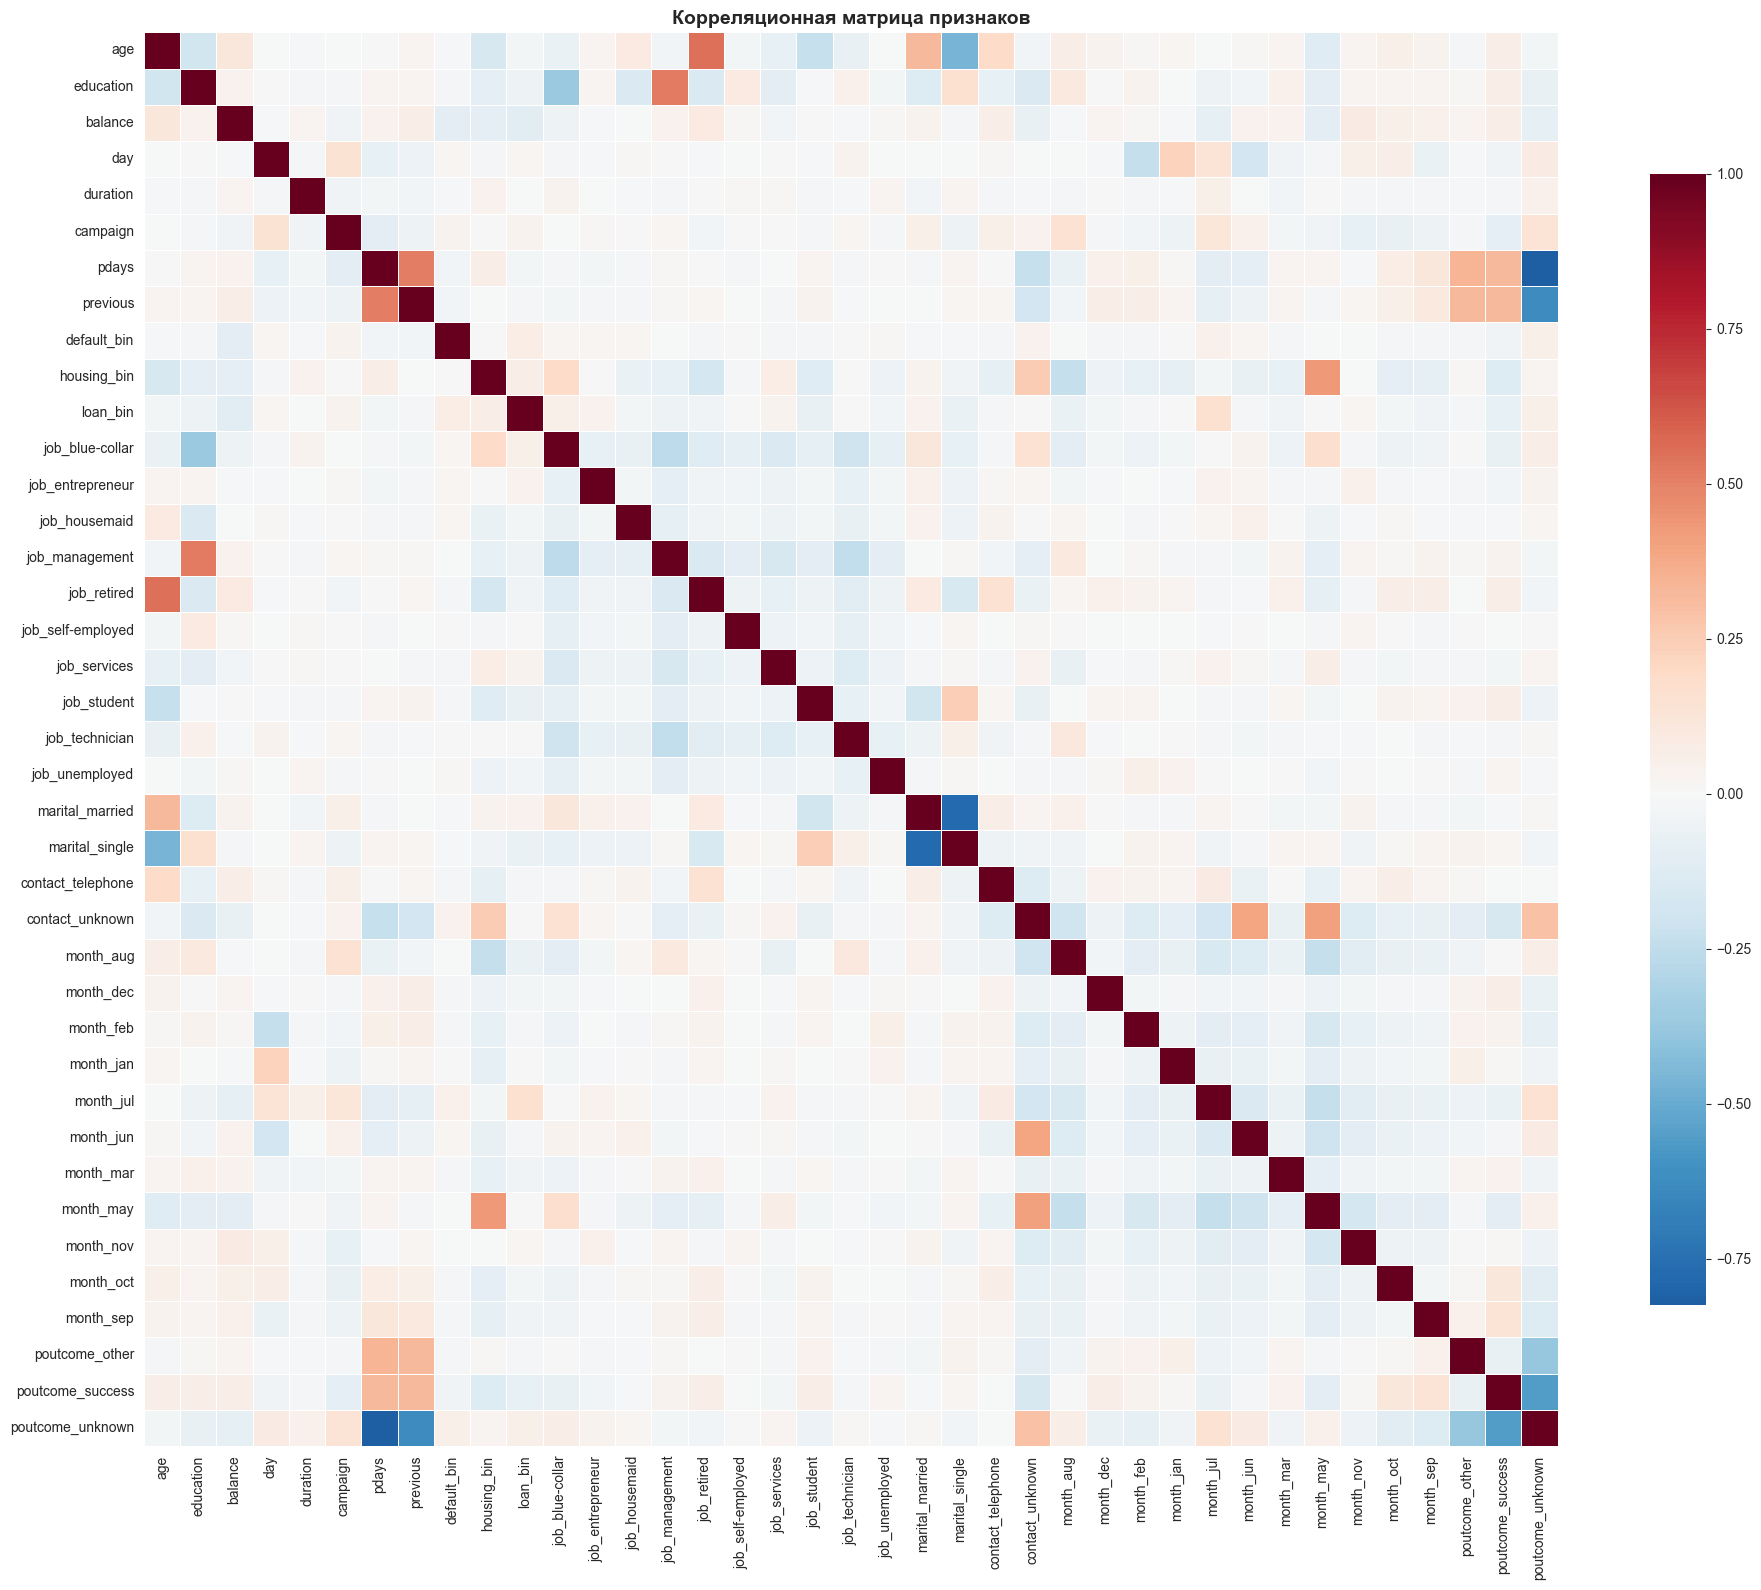

–ù–∞–π–¥–µ–Ω–æ —Å–∏–ª—å–Ω–æ –∫–æ—Ä—Ä–µ–ª–∏—Ä—É—é—â–∏—Ö –ø–∞—Ä: 2
  pdays ‚Üî poutcome_unknown: -0.824
  marital_married ‚Üî marital_single: -0.779

–ü—Ä–∏–∑–Ω–∞–∫–∏ —Å VIF > 10: 3
             feature        VIF
0                age  18.715437
38  poutcome_unknown  18.173792
1          education  16.809437
21   marital_married   5.453566
3                day   5.384803
32         month_may   4.630405
22    marital_single   3.815385
6              pdays   3.586413
14    job_management   3.394219
30         month_jun   2.841358


In [24]:
# –ü–æ—Å—Ç—Ä–æ–π—Ç–µ –∫–æ—Ä—Ä–µ–ª—è—Ü–∏–æ–Ω–Ω—É—é –º–∞—Ç—Ä–∏—Ü—É –∏ –æ—Ü–µ–Ω–∏—Ç–µ –¥–∞–Ω–Ω—ã–µ –Ω–∞ –ø—Ä–µ–¥–º–µ—Ç –Ω–∞–ª–∏—á–∏—è –º—É–ª—å—Ç–∏–∫–æ–ª–ª–∏–Ω–µ–∞—Ä–Ω–æ—Å—Ç–∏

# –ß–∏—Å–ª–æ–≤—ã–µ –ø—Ä–∏–∑–Ω–∞–∫–∏
numeric_features = df_with_dummies.select_dtypes(include=[np.number]).columns
feature_cols = [col for col in numeric_features if col != 'deposit_bin']

# 1. –ú–∞—Ç—Ä–∏—Ü–∞ –∫–æ—Ä—Ä–µ–ª—è—Ü–∏–π
corr_matrix = df_with_dummies[feature_cols].corr()

# 2. –í–ò–ó–£–ê–õ–ò–ó–ê–¶–ò–Ø
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, annot=False, cbar_kws={"shrink": 0.8})
plt.title('–ö–æ—Ä—Ä–µ–ª—è—Ü–∏–æ–Ω–Ω–∞—è –º–∞—Ç—Ä–∏—Ü–∞ –ø—Ä–∏–∑–Ω–∞–∫–æ–≤', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# 3. –ü–æ–∏—Å–∫ —Å–∏–ª—å–Ω–æ –∫–æ—Ä—Ä–µ–ª–∏—Ä—É—é—â–∏—Ö –ø–∞—Ä
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print(f"–ù–∞–π–¥–µ–Ω–æ —Å–∏–ª—å–Ω–æ –∫–æ—Ä—Ä–µ–ª–∏—Ä—É—é—â–∏—Ö –ø–∞—Ä: {len(high_corr)}")
for pair in high_corr[:5]:
    print(f"  {pair[0]} ‚Üî {pair[1]}: {pair[2]:.3f}")

# 4. VIF –∞–Ω–∞–ª–∏–∑
X = df_with_dummies[feature_cols].dropna()
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print(f"\n–ü—Ä–∏–∑–Ω–∞–∫–∏ —Å VIF > 10: {len(vif_data[vif_data['VIF'] > 10])}")
print(vif_data.head(10))


In [25]:
# –£–¥–∞–ª—è—é age_group_equal –ø–µ—Ä–µ–¥ —Å–æ–∑–¥–∞–Ω–∏–µ–º X –∏ y
df_with_dummies = df_with_dummies.drop(columns=['age_group_equal'], errors='ignore')

### –ó–∞–¥–∞–Ω–∏—è 7 –∏ 8

In [26]:
X = df_with_dummies.drop(['deposit_bin'], axis=1)
y = df_with_dummies['deposit_bin']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)

In [27]:
# –†–∞—Å—Å—á–∏—Ç–∞–π—Ç–µ –Ω–µ–æ–±—Ö–æ–¥–∏–º—ã–µ –ø–æ–∫–∞–∑–∞—Ç–µ–ª–∏

# –û–±—É—á–µ–Ω–∏–µ –º–æ–¥–µ–ª–∏
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# –ü—Ä–µ–¥—Å–∫–∞–∑–∞–Ω–∏—è
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# –†–∞—Å—á–µ—Ç –º–µ—Ç—Ä–∏–∫
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# –í—ã–≤–æ–¥ —Ä–µ–∑—É–ª—å—Ç–∞—Ç–æ–≤
print("–ú–ï–¢–†–ò–ö–ò –ö–ê–ß–ï–°–¢–í–ê –ú–û–î–ï–õ–ò\n")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nCONFUSION MATRIX")
print(confusion_matrix(y_test, y_pred))

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))

–ú–ï–¢–†–ò–ö–ò –ö–ê–ß–ï–°–¢–í–ê –ú–û–î–ï–õ–ò

Accuracy:  0.8156
Precision: 0.8129
Recall:    0.7819
F1-score:  0.7971
ROC-AUC:   0.8963

CONFUSION MATRIX
[[1512  278]
 [ 337 1208]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1790
           1       0.81      0.78      0.80      1545

    accuracy                           0.82      3335
   macro avg       0.82      0.81      0.81      3335
weighted avg       0.82      0.82      0.82      3335



### –ó–∞–¥–∞–Ω–∏–µ 9

In [38]:
# –° –ø–æ–º–æ—â—å—é SelectKBest –æ—Ç–±–µ—Ä–∏—Ç–µ 15 –Ω–∞–∏–±–æ–ª–µ–µ –ø–æ–¥—Ö–æ–¥—è—â–∏—Ö –ø—Ä–∏–∑–Ω–∞–∫–æ–≤

# –ü–æ–¥–≥–æ—Ç–æ–≤–∫–∞ –¥–∞–Ω–Ω—ã—Ö
X = df_with_dummies.drop(['deposit_bin'], axis=1)
y = df_with_dummies['deposit_bin']

# –û—Ç–±–æ—Ä 15 –ª—É—á—à–∏—Ö –ø—Ä–∏–∑–Ω–∞–∫–æ–≤
selector = SelectKBest(score_func=f_classif, k=15)
X_selected = selector.fit_transform(X, y)

# –ü–æ–ª—É—á–∞–µ–º –º–∞—Å–∫–∏ –æ—Ç–æ–±—Ä–∞–Ω–Ω—ã—Ö –ø—Ä–∏–∑–Ω–∞–∫–æ–≤
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]

# –†–µ–∑—É–ª—å—Ç–∞—Ç—ã
print("–û–¢–û–ë–†–ê–ù–ù–´–ï –ü–†–ò–ó–ù–ê–ö–ò (15)\n")
for i, feature in enumerate(selected_features, 1):
    score = selector.scores_[selected_mask][i-1]
    print(f"{i:2d}. {feature:25s} (score: {score:.2f})")

# –°–æ–∑–¥–∞–µ–º –¥–∞—Ç–∞—Ñ—Ä–µ–π–º —Å –æ—Ç–æ–±—Ä–∞–Ω–Ω—ã–º–∏ –ø—Ä–∏–∑–Ω–∞–∫–∞–º–∏
X_selected_df = X[selected_features]

–û–¢–û–ë–†–ê–ù–ù–´–ï –ü–†–ò–ó–ù–ê–ö–ò (15)

 1. balance                   (score: 190.08)
 2. duration                  (score: 2679.09)
 3. campaign                  (score: 175.60)
 4. pdays                     (score: 225.99)
 5. previous                  (score: 205.23)
 6. housing_bin               (score: 422.23)
 7. loan_bin                  (score: 117.54)
 8. job_student               (score: 113.85)
 9. contact_unknown           (score: 669.48)
10. month_mar                 (score: 188.53)
11. month_may                 (score: 294.16)
12. month_oct                 (score: 175.31)
13. month_sep                 (score: 160.99)
14. poutcome_success          (score: 917.18)
15. poutcome_unknown          (score: 555.53)


### –ó–∞–¥–∞–Ω–∏–µ 10

In [39]:
# –ù–æ—Ä–º–∞–ª–∏–∑—É–π—Ç–µ –¥–∞–Ω–Ω—ã–µ —Å –ø–æ–º–æ—â—å—é minmaxsxaler

# –°–æ–∑–¥–∞–µ–º –∫–æ–ø–∏—é –æ—Ç–æ–±—Ä–∞–Ω–Ω—ã—Ö –ø—Ä–∏–∑–Ω–∞–∫–æ–≤
X_normalized = X_selected_df.copy()

# –ò–Ω–∏—Ü–∏–∞–ª–∏–∑–∏—Ä—É–µ–º scaler
scaler = MinMaxScaler()

# –û–±—É—á–∞–µ–º scaler –∏ —Ç—Ä–∞–Ω—Å—Ñ–æ—Ä–º–∏—Ä—É–µ–º –¥–∞–Ω–Ω—ã–µ
X_normalized = scaler.fit_transform(X_selected_df)

# –ü—Ä–µ–æ–±—Ä–∞–∑—É–µ–º –æ–±—Ä–∞—Ç–Ω–æ –≤ DataFrame –¥–ª—è —É–¥–æ–±—Å—Ç–≤–∞
X_normalized = pd.DataFrame(X_normalized, columns=X_selected_df.columns)

print("–ù–û–†–ú–ê–õ–ò–ó–ê–¶–ò–Ø MINMAX\n")
print(f"–î–æ –Ω–æ—Ä–º–∞–ª–∏–∑–∞—Ü–∏–∏:")
print(f"  min: {X_selected_df.min().min():.3f}")
print(f"  max: {X_selected_df.max().max():.3f}")

print(f"\n–ü–æ—Å–ª–µ –Ω–æ—Ä–º–∞–ª–∏–∑–∞—Ü–∏–∏:")
print(f"  min: {X_normalized.min().min():.3f}")
print(f"  max: {X_normalized.max().max():.3f}")
print(f"  –≤—Å–µ –∑–Ω–∞—á–µ–Ω–∏—è –≤ –¥–∏–∞–ø–∞–∑–æ–Ω–µ [0, 1]")

# –ü—Ä–∏–º–µ—Ä –¥–ª—è –ø–µ—Ä–≤–æ–π –∫–æ–ª–æ–Ω–∫–∏
first_col = X_selected_df.columns[0]
print(f"\n–ü—Ä–∏–º–µ—Ä –¥–ª—è –∫–æ–ª–æ–Ω–∫–∏ '{first_col}':")
print(f"  –î–æ: {X_selected_df[first_col].iloc[0]:.3f} -> –ü–æ—Å–ª–µ: {X_normalized[first_col].iloc[0]:.3f}")

–ù–û–†–ú–ê–õ–ò–ó–ê–¶–ò–Ø MINMAX

–î–æ –Ω–æ—Ä–º–∞–ª–∏–∑–∞—Ü–∏–∏:
  min: -2049.000
  max: 4063.000

–ü–æ—Å–ª–µ –Ω–æ—Ä–º–∞–ª–∏–∑–∞—Ü–∏–∏:
  min: 0.000
  max: 1.000
  –≤—Å–µ –∑–Ω–∞—á–µ–Ω–∏—è –≤ –¥–∏–∞–ø–∞–∑–æ–Ω–µ [0, 1]

–ü—Ä–∏–º–µ—Ä –¥–ª—è –∫–æ–ª–æ–Ω–∫–∏ 'balance':
  –î–æ: 2343.000 -> –ü–æ—Å–ª–µ: 0.719


# –ß–∞—Å—Ç—å 4: –†–µ—à–µ–Ω–∏–µ –∑–∞–¥–∞—á–∏ –∫–ª–∞—Å—Å–∏—Ñ–∏–∫–∞—Ü–∏–∏: –ª–æ–≥–∏—Å—Ç–∏—á–µ—Å–∫–∞—è —Ä–µ–≥—Ä–µ—Å—Å–∏—è –∏ —Ä–µ—à–∞—é—â–∏–µ –¥–µ—Ä–µ–≤—å—è

### –ó–∞–¥–∞–Ω–∏–µ 1

In [30]:
# –æ–±—É—á–∏—Ç–µ –ª–æ–≥–∏—Å—Ç–∏—á–µ—Å–∫—É—é —Ä–µ–≥—Ä–µ—Å—Å–∏—é –∏ —Ä–∞—Å—Å—á–∏—Ç–∞–π—Ç–µ –º–µ—Ç—Ä–∏–∫–∏ –∫–∞—á–µ—Å—Ç–≤–∞

X_train_norm, X_test_norm, y_train, y_test = train_test_split(
    X_normalized, y, 
    stratify=y, 
    random_state=42, 
    test_size=0.33
)


# –û–±—É—á–∞–µ–º –ª–æ–≥–∏—Å—Ç–∏—á–µ—Å–∫—É—é —Ä–µ–≥—Ä–µ—Å—Å–∏—é
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_norm, y_train)  # –∏—Å–ø–æ–ª—å–∑—É–µ–º train –∏–∑ –ø—Ä–µ–¥—ã–¥—É—â–µ–≥–æ —à–∞–≥–∞

# –ü—Ä–µ–¥—Å–∫–∞–∑–∞–Ω–∏—è
y_pred_log = log_reg.predict(X_test_norm)
y_pred_proba_log = log_reg.predict_proba(X_test_norm)[:, 1]

# –ú–µ—Ç—Ä–∏–∫–∏
print("–õ–û–ì–ò–°–¢–ò–ß–ï–°–ö–ê–Ø –†–ï–ì–†–ï–°–°–ò–Ø\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_log):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_log):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_log):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_log):.4f}")

print("\nCONFUSION MATRIX")
print(confusion_matrix(y_test, y_pred_log))

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_log))

–õ–û–ì–ò–°–¢–ò–ß–ï–°–ö–ê–Ø –†–ï–ì–†–ï–°–°–ò–Ø

Accuracy:  0.8057
Precision: 0.8215
Recall:    0.7417
F1-score:  0.7796
ROC-AUC:   0.8872

CONFUSION MATRIX
[[1541  249]
 [ 399 1146]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.79      0.86      0.83      1790
           1       0.82      0.74      0.78      1545

    accuracy                           0.81      3335
   macro avg       0.81      0.80      0.80      3335
weighted avg       0.81      0.81      0.80      3335



### –ó–∞–¥–∞–Ω–∏—è 2,3,4

–†–ï–®–ê–Æ–©–ï–ï –î–ï–†–ï–í–û (–ë–ï–ó –ù–ê–°–¢–†–û–ô–ö–ò)

Accuracy:  0.7523
Precision: 0.7330
Recall:    0.7320
F1-score:  0.7325
ROC-AUC:   0.7507

–ù–ê–°–¢–†–û–ô–ö–ê –ú–ê–ö–°–ò–ú–ê–õ–¨–ù–û–ô –ì–õ–£–ë–ò–ù–´

–õ—É—á—à–∞—è –º–∞–∫—Å–∏–º–∞–ª—å–Ω–∞—è –≥–ª—É–±–∏–Ω–∞: 7
–õ—É—á—à–∏–π F1-score –Ω–∞ –∫—Ä–æ—Å—Å-–≤–∞–ª–∏–¥–∞—Ü–∏–∏: 0.7939

–†–ï–®–ê–Æ–©–ï–ï –î–ï–†–ï–í–û (–° –ù–ê–°–¢–†–û–ô–ö–û–ô)

Accuracy:  0.7907
Precision: 0.7413
Recall:    0.8421
F1-score:  0.7885
ROC-AUC:   0.8671

–í–õ–ò–Ø–ù–ò–ï –ì–õ–£–ë–ò–ù–´ –ù–ê –ö–ê–ß–ï–°–¢–í–û

–ì–ª—É–±–∏–Ω–∞: 3     -> F1-score: 0.7411
–ì–ª—É–±–∏–Ω–∞: 5     -> F1-score: 0.7892
–ì–ª—É–±–∏–Ω–∞: 7     -> F1-score: 0.7885
–ì–ª—É–±–∏–Ω–∞: 10    -> F1-score: 0.7805
–ì–ª—É–±–∏–Ω–∞: 15    -> F1-score: 0.7653
–ì–ª—É–±–∏–Ω–∞: 20    -> F1-score: 0.7451
–ì–ª—É–±–∏–Ω–∞: None  -> F1-score: 0.7325


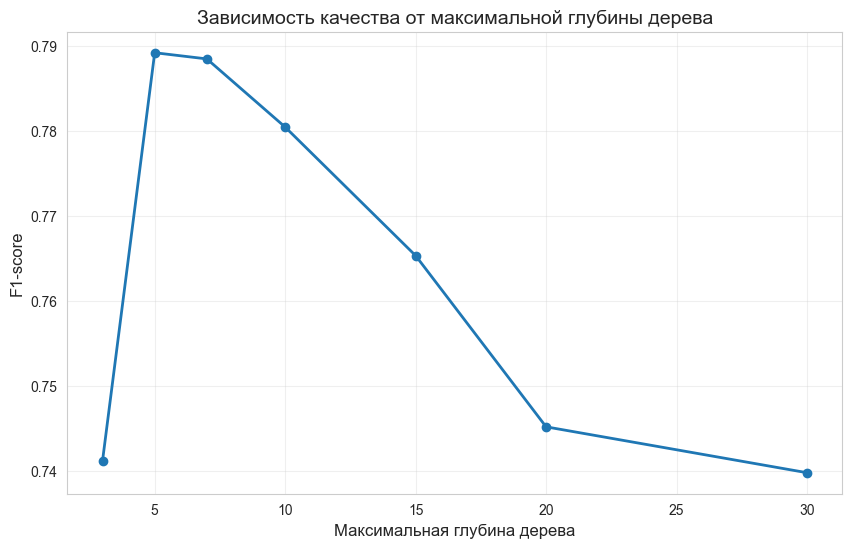

In [ ]:
# –û–±—É—á–∏—Ç–µ —Ä–µ—à–∞—é—â–∏–µ –¥–µ—Ä–µ–≤—å—è, –Ω–∞—Å—Ç—Ä–æ–π—Ç–µ –º–∞–∫—Å–∏–º–∞–ª—å–Ω—É—é –≥–ª—É–±–∏–Ω—É

# 1. –ë–∞–∑–æ–≤–æ–µ –¥–µ—Ä–µ–≤–æ (–±–µ–∑ –Ω–∞—Å—Ç—Ä–æ–π–∫–∏)
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train_norm, y_train)

y_pred_base = dt_base.predict(X_test_norm)
y_pred_proba_base = dt_base.predict_proba(X_test_norm)[:, 1]

print("–†–ï–®–ê–Æ–©–ï–ï –î–ï–†–ï–í–û (–ë–ï–ó –ù–ê–°–¢–†–û–ô–ö–ò)\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_base):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_base):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_base):.4f}")

# 2. –ù–∞—Å—Ç—Ä–æ–π–∫–∞ –º–∞–∫—Å–∏–º–∞–ª—å–Ω–æ–π –≥–ª—É–±–∏–Ω—ã —á–µ—Ä–µ–∑ GridSearchCV
print("\n–ù–ê–°–¢–†–û–ô–ö–ê –ú–ê–ö–°–ò–ú–ê–õ–¨–ù–û–ô –ì–õ–£–ë–ò–ù–´")

# –ü–∞—Ä–∞–º–µ—Ç—Ä—ã –¥–ª—è –ø–µ—Ä–µ–±–æ—Ä–∞ (None –∑–∞–º–µ–Ω–∏–ª–∏ –Ω–∞ —Å—Ç—Ä–æ–∫—É 'None' –¥–ª—è –æ—Ç–æ–±—Ä–∞–∂–µ–Ω–∏—è)
param_grid = {'max_depth': [3, 5, 7, 10, 15, 20, None]}

# GridSearchCV
dt_grid = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(dt_grid, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_norm, y_train)

# –õ—É—á—à–∞—è –≥–ª—É–±–∏–Ω–∞
best_depth = grid_search.best_params_['max_depth']
print(f"\n–õ—É—á—à–∞—è –º–∞–∫—Å–∏–º–∞–ª—å–Ω–∞—è –≥–ª—É–±–∏–Ω–∞: {best_depth}")
print(f"–õ—É—á—à–∏–π F1-score –Ω–∞ –∫—Ä–æ—Å—Å-–≤–∞–ª–∏–¥–∞—Ü–∏–∏: {grid_search.best_score_:.4f}")

# 3. –û–±—É—á–µ–Ω–∏–µ –¥–µ—Ä–µ–≤–∞ —Å –æ–ø—Ç–∏–º–∞–ª—å–Ω–æ–π –≥–ª—É–±–∏–Ω–æ–π
dt_optimized = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_optimized.fit(X_train_norm, y_train)

y_pred_opt = dt_optimized.predict(X_test_norm)
y_pred_proba_opt = dt_optimized.predict_proba(X_test_norm)[:, 1]

print("\n–†–ï–®–ê–Æ–©–ï–ï –î–ï–†–ï–í–û (–° –ù–ê–°–¢–†–û–ô–ö–û–ô)\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_opt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_opt):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_opt):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_opt):.4f}")

# 4. –í–∏–∑—É–∞–ª–∏–∑–∞—Ü–∏—è –≤–ª–∏—è–Ω–∏—è –≥–ª—É–±–∏–Ω—ã –Ω–∞ –∫–∞—á–µ—Å—Ç–≤–æ (–ò–°–ü–†–ê–í–õ–ï–ù–ù–´–ô –í–´–í–û–î)
print("\n–í–õ–ò–Ø–ù–ò–ï –ì–õ–£–ë–ò–ù–´ –ù–ê –ö–ê–ß–ï–°–¢–í–û\n")

results = []
for depth in [3, 5, 7, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_norm, y_train)
    y_pred = dt.predict(X_test_norm)
    f1 = f1_score(y_test, y_pred)
    results.append({'depth': depth, 'f1_score': f1})
    # –ò—Å–ø—Ä–∞–≤–ª–µ–Ω–Ω–∞—è —Å—Ç—Ä–æ–∫–∞ - –æ–±—Ä–∞–±–∞—Ç—ã–≤–∞–µ–º None –æ—Ç–¥–µ–ª—å–Ω–æ
    depth_str = str(depth) if depth is not None else "None"
    print(f"–ì–ª—É–±–∏–Ω–∞: {depth_str:<5} -> F1-score: {f1:.4f}")

# –ì—Ä–∞—Ñ–∏–∫ (–±–µ–∑ None)
depths_for_plot = [3, 5, 7, 10, 15, 20, 30]  # —É–±–∏—Ä–∞–µ–º None –¥–ª—è –≥—Ä–∞—Ñ–∏–∫–∞
f1_scores = []

for depth in depths_for_plot:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_norm, y_train)
    f1_scores.append(f1_score(y_test, dt.predict(X_test_norm)))

plt.figure(figsize=(10, 6))
plt.plot(depths_for_plot, f1_scores, marker='o', linestyle='-', linewidth=2)
plt.xlabel('–ú–∞–∫—Å–∏–º–∞–ª—å–Ω–∞—è –≥–ª—É–±–∏–Ω–∞ –¥–µ—Ä–µ–≤–∞', fontsize=12)
plt.ylabel('F1-score', fontsize=12)
plt.title('–ó–∞–≤–∏—Å–∏–º–æ—Å—Ç—å –∫–∞—á–µ—Å—Ç–≤–∞ –æ—Ç –º–∞–∫—Å–∏–º–∞–ª—å–Ω–æ–π –≥–ª—É–±–∏–Ω—ã –¥–µ—Ä–µ–≤–∞', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

### –ó–∞–¥–∞–Ω–∏–µ 5

In [ ]:
# –ü–æ–¥–±–µ—Ä–∏—Ç–µ –æ–ø—Ç–∏–º–∞–ª—å–Ω—ã–µ –ø–∞—Ä–∞–º–µ—Ç—Ä—ã —Å –ø–æ–º–æ—â—å—é gridsearch

# 1. –î–õ–Ø –†–ï–®–ê–Æ–©–ï–ì–û –î–ï–†–ï–í–ê
print("–ü–û–î–ë–û–† –ü–ê–†–ê–ú–ï–¢–†–û–í –î–õ–Ø DECISION TREE")


# –°–µ—Ç–∫–∞ –ø–∞—Ä–∞–º–µ—Ç—Ä–æ–≤ –¥–ª—è –¥–µ—Ä–µ–≤–∞
param_grid_tree = {
    'max_depth': [5, 7, 10, 12, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

# GridSearchCV –¥–ª—è –¥–µ—Ä–µ–≤–∞
dt = DecisionTreeClassifier(random_state=42)
grid_tree = GridSearchCV(
    dt, 
    param_grid_tree, 
    cv=5, 
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_tree.fit(X_train_norm, y_train)

print(f"\n–õ—É—á—à–∏–µ –ø–∞—Ä–∞–º–µ—Ç—Ä—ã Decision Tree:")
for param, value in grid_tree.best_params_.items():
    print(f"  {param}: {value}")
print(f"\n–õ—É—á—à–∏–π F1-score (CV): {grid_tree.best_score_:.4f}")

# –û—Ü–µ–Ω–∫–∞ –Ω–∞ —Ç–µ—Å—Ç–µ
best_dt = grid_tree.best_estimator_
y_pred_dt = best_dt.predict(X_test_norm)
print(f"F1-score –Ω–∞ —Ç–µ—Å—Ç–µ: {f1_score(y_test, y_pred_dt):.4f}")


# 2. –î–õ–Ø –°–õ–£–ß–ê–ô–ù–û–ì–û –õ–ï–°–ê (–î–æ–ø–æ–ª–Ω–∏—Ç–µ–ª—å–Ω–æ)
print("–ü–û–î–ë–û–† –ü–ê–†–ê–ú–ï–¢–†–û–í –î–õ–Ø RANDOM FOREST")


# –°–µ—Ç–∫–∞ –ø–∞—Ä–∞–º–µ—Ç—Ä–æ–≤ –¥–ª—è —Å–ª—É—á–∞–π–Ω–æ–≥–æ –ª–µ—Å–∞
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV –¥–ª—è —Å–ª—É—á–∞–π–Ω–æ–≥–æ –ª–µ—Å–∞ (—É–º–µ–Ω—å—à–µ–Ω–Ω–∞—è —Å–µ—Ç–∫–∞ –¥–ª—è —Å–∫–æ—Ä–æ—Å—Ç–∏)
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_rf = GridSearchCV(
    rf, 
    param_grid_rf, 
    cv=3,  # –º–µ–Ω—å—à–µ folds –¥–ª—è —Å–∫–æ—Ä–æ—Å—Ç–∏
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train_norm, y_train)

print(f"\n–õ—É—á—à–∏–µ –ø–∞—Ä–∞–º–µ—Ç—Ä—ã Random Forest:")
for param, value in grid_rf.best_params_.items():
    print(f"  {param}: {value}")
print(f"\n–õ—É—á—à–∏–π F1-score (CV): {grid_rf.best_score_:.4f}")

# –û—Ü–µ–Ω–∫–∞ –Ω–∞ —Ç–µ—Å—Ç–µ
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_norm)
print(f"F1-score –Ω–∞ —Ç–µ—Å—Ç–µ: {f1_score(y_test, y_pred_rf):.4f}")


# 3. –°–†–ê–í–ù–ï–ù–ò–ï –ú–û–î–ï–õ–ï–ô
print("–°–†–ê–í–ù–ï–ù–ò–ï –ú–û–î–ï–õ–ï–ô")


print(f"\nDecision Tree (–æ–ø—Ç–∏–º–∞–ª—å–Ω—ã–π):")
print(f"  –ü–∞—Ä–∞–º–µ—Ç—Ä—ã: max_depth={grid_tree.best_params_['max_depth']}, "
      f"min_samples_split={grid_tree.best_params_['min_samples_split']}")
print(f"  F1-score: {f1_score(y_test, y_pred_dt):.4f}")

print(f"\nRandom Forest (–æ–ø—Ç–∏–º–∞–ª—å–Ω—ã–π):")
print(f"  –ü–∞—Ä–∞–º–µ—Ç—Ä—ã: n_estimators={grid_rf.best_params_['n_estimators']}, "
      f"max_depth={grid_rf.best_params_['max_depth']}")
print(f"  F1-score: {f1_score(y_test, y_pred_rf):.4f}")


# 4. –°–û–•–†–ê–ù–ï–ù–ò–ï –õ–£–ß–®–ï–ô –ú–û–î–ï–õ–ò
best_model = grid_rf if grid_rf.best_score_ > grid_tree.best_score_ else grid_tree
print(f"\n–õ—É—á—à–∞—è –º–æ–¥–µ–ª—å: {'Random Forest' if grid_rf.best_score_ > grid_tree.best_score_ else 'Decision Tree'}")

–ü–û–î–ë–û–† –ü–ê–†–ê–ú–ï–¢–†–û–í –î–õ–Ø DECISION TREE
Fitting 5 folds for each of 192 candidates, totalling 960 fits

–õ—É—á—à–∏–µ –ø–∞—Ä–∞–º–µ—Ç—Ä—ã Decision Tree:
  criterion: entropy
  max_depth: 7
  min_samples_leaf: 8
  min_samples_split: 2

–õ—É—á—à–∏–π F1-score (CV): 0.7985
F1-score –Ω–∞ —Ç–µ—Å—Ç–µ: 0.7828
–ü–û–î–ë–û–† –ü–ê–†–ê–ú–ï–¢–†–û–í –î–õ–Ø RANDOM FOREST
Fitting 3 folds for each of 135 candidates, totalling 405 fits

–õ—É—á—à–∏–µ –ø–∞—Ä–∞–º–µ—Ç—Ä—ã Random Forest:
  max_depth: 10
  min_samples_leaf: 1
  min_samples_split: 5
  n_estimators: 50

–õ—É—á—à–∏–π F1-score (CV): 0.8211
F1-score –Ω–∞ —Ç–µ—Å—Ç–µ: 0.8280
–°–†–ê–í–ù–ï–ù–ò–ï –ú–û–î–ï–õ–ï–ô

Decision Tree (–æ–ø—Ç–∏–º–∞–ª—å–Ω—ã–π):
  –ü–∞—Ä–∞–º–µ—Ç—Ä—ã: max_depth=7, min_samples_split=2
  F1-score: 0.7828

Random Forest (–æ–ø—Ç–∏–º–∞–ª—å–Ω—ã–π):
  –ü–∞—Ä–∞–º–µ—Ç—Ä—ã: n_estimators=50, max_depth=10
  F1-score: 0.8280

–õ—É—á—à–∞—è –º–æ–¥–µ–ª—å: Random Forest


# –ß–∞—Å—Ç—å 5: –†–µ—à–µ–Ω–∏–µ –∑–∞–¥–∞—á–∏ –∫–ª–∞—Å—Å–∏—Ñ–∏–∫–∞—Ü–∏–∏: –∞–Ω—Å–∞–º–±–ª–∏ –º–æ–¥–µ–ª–µ–π –∏ –ø–æ—Å—Ç—Ä–æ–µ–Ω–∏–µ –ø—Ä–æ–≥–Ω–æ–∑–∞

### –ó–∞–¥–∞–Ω–∏–µ 1

–°–õ–£–ß–ê–ô–ù–´–ô –õ–ï–° (–ë–ê–ó–û–í–´–ô)

Accuracy:  0.8123
Precision: 0.7874
Recall:    0.8149
F1-score:  0.8009
ROC-AUC:   0.8825

–°–õ–£–ß–ê–ô–ù–´–ô –õ–ï–° (–û–ü–¢–ò–ú–ò–ó–ò–†–û–í–ê–ù–ù–´–ô)

Accuracy:  0.8321
Precision: 0.8069
Recall:    0.8382
F1-score:  0.8222
ROC-AUC:   0.8987

CONFUSION MATRIX
[[1480  310]
 [ 250 1295]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1790
           1       0.81      0.84      0.82      1545

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335


–í–ê–ñ–ù–û–°–¢–¨ –ü–†–ò–ó–ù–ê–ö–û–í (–¢–û–ü-10)

duration                 : 0.5377
poutcome_success         : 0.0778
contact_unknown          : 0.0580
balance                  : 0.0532
housing_bin              : 0.0498
pdays                    : 0.0494
previous                 : 0.0306
campaign                 : 0.0

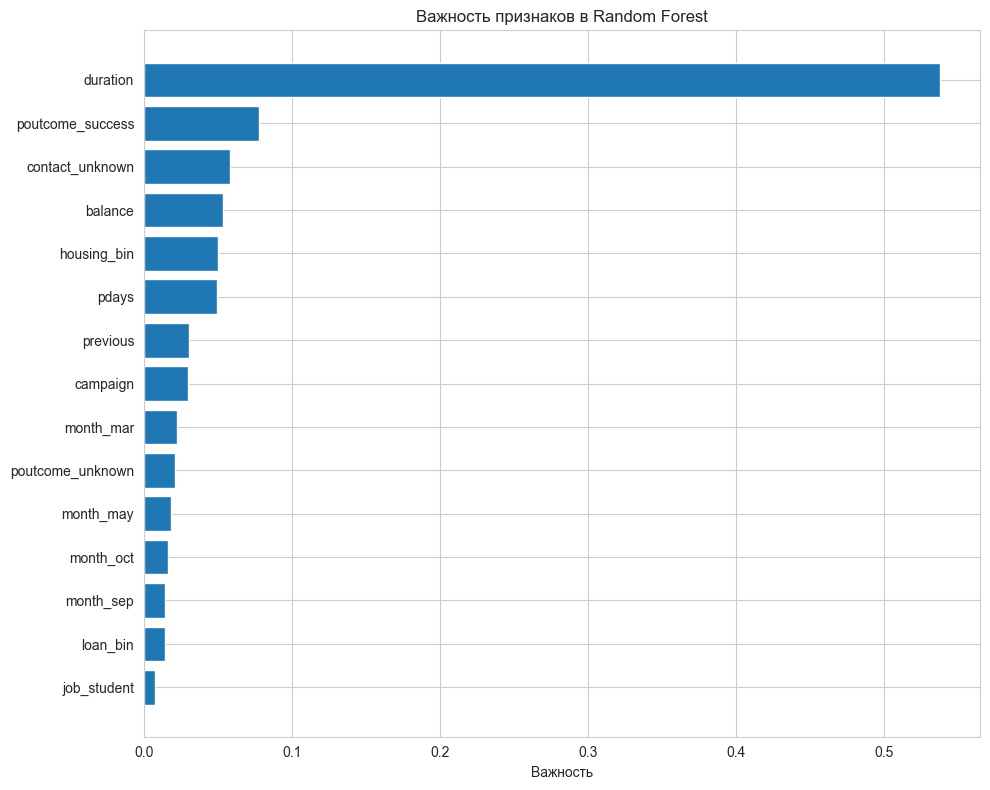

In [ ]:
# –û–±—É—á–∏—Ç–µ –Ω–∞ –≤–∞—à–∏—Ö –¥–∞–Ω–Ω—ã—Ö —Å–ª—É—á–∞–π–Ω—ã–π –ª–µ—Å

# 1. –ë–∞–∑–æ–≤—ã–π —Å–ª—É—á–∞–π–Ω—ã–π –ª–µ—Å (–±–µ–∑ –Ω–∞—Å—Ç—Ä–æ–π–∫–∏)
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_base.fit(X_train_norm, y_train)

# –ü—Ä–µ–¥—Å–∫–∞–∑–∞–Ω–∏—è
y_pred_rf_base = rf_base.predict(X_test_norm)
y_pred_proba_rf_base = rf_base.predict_proba(X_test_norm)[:, 1]

print("–°–õ–£–ß–ê–ô–ù–´–ô –õ–ï–° (–ë–ê–ó–û–í–´–ô)\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_base):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf_base):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_rf_base):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_rf_base):.4f}")

# 2. –°–ª—É—á–∞–π–Ω—ã–π –ª–µ—Å —Å –æ–ø—Ç–∏–º–∞–ª—å–Ω—ã–º–∏ –ø–∞—Ä–∞–º–µ—Ç—Ä–∞–º–∏ (–∏–∑ GridSearch)
rf_optimized = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_optimized.fit(X_train_norm, y_train)

y_pred_rf_opt = rf_optimized.predict(X_test_norm)
y_pred_proba_rf_opt = rf_optimized.predict_proba(X_test_norm)[:, 1]

print("\n–°–õ–£–ß–ê–ô–ù–´–ô –õ–ï–° (–û–ü–¢–ò–ú–ò–ó–ò–†–û–í–ê–ù–ù–´–ô)\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf_opt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_opt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf_opt):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_rf_opt):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_rf_opt):.4f}")

# 3. –ú–∞—Ç—Ä–∏—Ü–∞ –æ—à–∏–±–æ–∫
print("\nCONFUSION MATRIX")
print(confusion_matrix(y_test, y_pred_rf_opt))

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_rf_opt))

# 4. –í–∞–∂–Ω–æ—Å—Ç—å –ø—Ä–∏–∑–Ω–∞–∫–æ–≤
feature_importance = pd.DataFrame({
    'feature': X_train_norm.columns,
    'importance': rf_optimized.feature_importances_
}).sort_values('importance', ascending=False)

print("\n–í–ê–ñ–ù–û–°–¢–¨ –ü–†–ò–ó–ù–ê–ö–û–í (–¢–û–ü-10)\n")
for i, row in feature_importance.head(10).iterrows():
    print(f"{row['feature']:25s}: {row['importance']:.4f}")

# –í–∏–∑—É–∞–ª–∏–∑–∞—Ü–∏—è –≤–∞–∂–Ω–æ—Å—Ç–∏ –ø—Ä–∏–∑–Ω–∞–∫–æ–≤
plt.figure(figsize=(10, 8))
plt.barh(feature_importance.head(15)['feature'], feature_importance.head(15)['importance'])
plt.xlabel('–í–∞–∂–Ω–æ—Å—Ç—å')
plt.title('–í–∞–∂–Ω–æ—Å—Ç—å –ø—Ä–∏–∑–Ω–∞–∫–æ–≤ –≤ Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### –ó–∞–¥–∞–Ω–∏—è 2 –∏ 3

–ì–†–ê–î–ò–ï–ù–¢–ù–´–ô –ë–£–°–¢–ò–ù–ì (–ë–ê–ó–û–í–´–ô)

Accuracy:  0.8276
Precision: 0.8043
Recall:    0.8298
F1-score:  0.8168
ROC-AUC:   0.8964

–ì–†–ê–î–ò–ï–ù–¢–ù–´–ô –ë–£–°–¢–ò–ù–ì (–û–ü–¢–ò–ú–ò–ó–ò–†–û–í–ê–ù–ù–´–ô)

Accuracy:  0.8324
Precision: 0.8062
Recall:    0.8401
F1-score:  0.8228
ROC-AUC:   0.8996
–°–†–ê–í–ù–ï–ù–ò–ï –ú–û–î–ï–õ–ï–ô

   –ú–µ—Ç—Ä–∏–∫–∞  Random Forest  Gradient Boosting
 Accuracy       0.832084           0.832384
Precision       0.806854           0.806211
   Recall       0.838188           0.840129
 F1-score       0.822222           0.822821
  ROC-AUC       0.898704           0.899605

üèÜ –õ—É—á—à–∞—è –º–æ–¥–µ–ª—å –ø–æ F1-score: Gradient Boosting (0.8228)


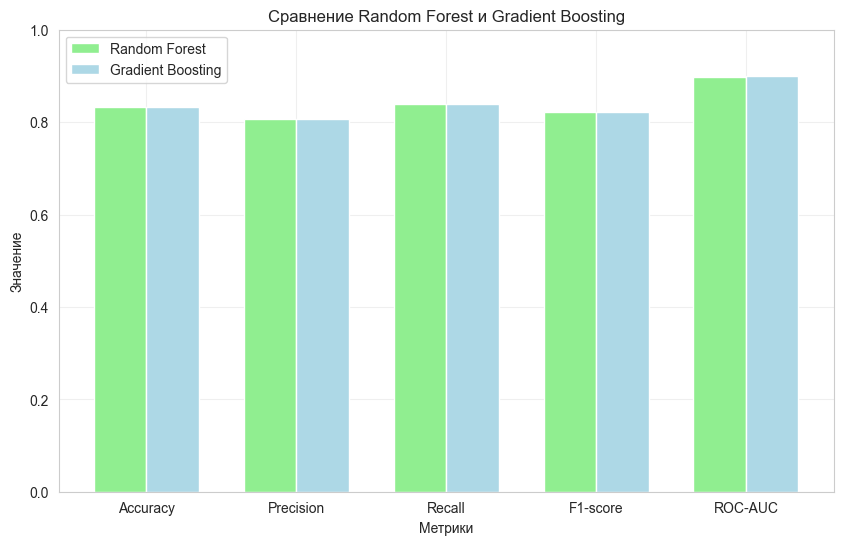


–í–ê–ñ–ù–û–°–¢–¨ –ü–†–ò–ó–ù–ê–ö–û–í (Gradient Boosting, –¢–û–ü-10)

duration                 : 0.5395
poutcome_success         : 0.1259
contact_unknown          : 0.0718
housing_bin              : 0.0550
pdays                    : 0.0444
balance                  : 0.0402
month_mar                : 0.0294
month_oct                : 0.0191
campaign                 : 0.0164
month_sep                : 0.0155


In [ ]:
# –ò—Å–ø–æ–ª—å–∑—É–π—Ç–µ –¥–ª—è –∫–ª–∞—Å—Å–∏—Ñ–∏–∫–∞—Ü–∏–∏ –≥—Ä–∞–¥–∏–µ–Ω—Ç–Ω—ã–π –±—É—Å—Ç–∏–Ω–≥ –∏ —Å—Ä–∞–≤–Ω–∏—Ç–µ –∫–∞—á–µ—Å—Ç–≤–æ —Å–æ —Å–ª—É—á–∞–π–Ω—ã–º –ª–µ—Å–æ–º


# 1. –ë–∞–∑–æ–≤—ã–π –≥—Ä–∞–¥–∏–µ–Ω—Ç–Ω—ã–π –±—É—Å—Ç–∏–Ω–≥
gb_base = GradientBoostingClassifier(random_state=42)
gb_base.fit(X_train_norm, y_train)

y_pred_gb_base = gb_base.predict(X_test_norm)
y_pred_proba_gb_base = gb_base.predict_proba(X_test_norm)[:, 1]

print("–ì–†–ê–î–ò–ï–ù–¢–ù–´–ô –ë–£–°–¢–ò–ù–ì (–ë–ê–ó–û–í–´–ô)\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_gb_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gb_base):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_gb_base):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_gb_base):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_gb_base):.4f}")

# 2. –û–ø—Ç–∏–º–∏–∑–∏—Ä–æ–≤–∞–Ω–Ω—ã–π –≥—Ä–∞–¥–∏–µ–Ω—Ç–Ω—ã–π –±—É—Å—Ç–∏–Ω–≥
gb_optimized = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,
    random_state=42
)
gb_optimized.fit(X_train_norm, y_train)

y_pred_gb_opt = gb_optimized.predict(X_test_norm)
y_pred_proba_gb_opt = gb_optimized.predict_proba(X_test_norm)[:, 1]

print("\n–ì–†–ê–î–ò–ï–ù–¢–ù–´–ô –ë–£–°–¢–ò–ù–ì (–û–ü–¢–ò–ú–ò–ó–ò–†–û–í–ê–ù–ù–´–ô)\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_gb_opt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gb_opt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_gb_opt):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_gb_opt):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_gb_opt):.4f}")

# 3. –°–†–ê–í–ù–ï–ù–ò–ï –°–û –°–õ–£–ß–ê–ô–ù–´–ú –õ–ï–°–û–ú
print("–°–†–ê–í–ù–ï–ù–ò–ï –ú–û–î–ï–õ–ï–ô")


# –ú–µ—Ç—Ä–∏–∫–∏ –¥–ª—è Random Forest (–∏–∑ –ø—Ä–µ–¥—ã–¥—É—â–µ–≥–æ –∑–∞–¥–∞–Ω–∏—è)
rf_pred = rf_optimized.predict(X_test_norm) if 'rf_optimized' in dir() else None

if rf_pred is not None:
    results_df = pd.DataFrame({
        '–ú–µ—Ç—Ä–∏–∫–∞': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
        'Random Forest': [
            accuracy_score(y_test, rf_pred),
            precision_score(y_test, rf_pred),
            recall_score(y_test, rf_pred),
            f1_score(y_test, rf_pred),
            roc_auc_score(y_test, rf_optimized.predict_proba(X_test_norm)[:, 1])
        ],
        'Gradient Boosting': [
            accuracy_score(y_test, y_pred_gb_opt),
            precision_score(y_test, y_pred_gb_opt),
            recall_score(y_test, y_pred_gb_opt),
            f1_score(y_test, y_pred_gb_opt),
            roc_auc_score(y_test, y_pred_proba_gb_opt)
        ]
    })
    
    print("\n", results_df.to_string(index=False))
    
    # –û–ø—Ä–µ–¥–µ–ª–µ–Ω–∏–µ –ª—É—á—à–µ–π –º–æ–¥–µ–ª–∏
    best_f1 = max(f1_score(y_test, rf_pred), f1_score(y_test, y_pred_gb_opt))
    best_model = "Random Forest" if f1_score(y_test, rf_pred) > f1_score(y_test, y_pred_gb_opt) else "Gradient Boosting"
    print(f"\nüèÜ –õ—É—á—à–∞—è –º–æ–¥–µ–ª—å –ø–æ F1-score: {best_model} ({best_f1:.4f})")

# 4. –í–∏–∑—É–∞–ª–∏–∑–∞—Ü–∏—è —Å—Ä–∞–≤–Ω–µ–Ω–∏—è
plt.figure(figsize=(10, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
rf_scores = [accuracy_score(y_test, rf_pred), precision_score(y_test, rf_pred), 
             recall_score(y_test, rf_pred), f1_score(y_test, rf_pred),
             roc_auc_score(y_test, rf_optimized.predict_proba(X_test_norm)[:, 1])]
gb_scores = [accuracy_score(y_test, y_pred_gb_opt), precision_score(y_test, y_pred_gb_opt),
             recall_score(y_test, y_pred_gb_opt), f1_score(y_test, y_pred_gb_opt),
             roc_auc_score(y_test, y_pred_proba_gb_opt)]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, rf_scores, width, label='Random Forest', color='lightgreen')
plt.bar(x + width/2, gb_scores, width, label='Gradient Boosting', color='lightblue')
plt.xlabel('–ú–µ—Ç—Ä–∏–∫–∏')
plt.ylabel('–ó–Ω–∞—á–µ–Ω–∏–µ')
plt.title('–°—Ä–∞–≤–Ω–µ–Ω–∏–µ Random Forest –∏ Gradient Boosting')
plt.xticks(x, metrics)
plt.legend()
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

# 5. –í–∞–∂–Ω–æ—Å—Ç—å –ø—Ä–∏–∑–Ω–∞–∫–æ–≤ –¥–ª—è Gradient Boosting
feature_importance_gb = pd.DataFrame({
    'feature': X_train_norm.columns,
    'importance': gb_optimized.feature_importances_
}).sort_values('importance', ascending=False)

print("\n–í–ê–ñ–ù–û–°–¢–¨ –ü–†–ò–ó–ù–ê–ö–û–í (Gradient Boosting, –¢–û–ü-10)\n")
for i, row in feature_importance_gb.head(10).iterrows():
    print(f"{row['feature']:25s}: {row['importance']:.4f}")

### –ó–∞–¥–∞–Ω–∏–µ 4

In [ ]:
# –û–±—ä–µ–¥–∏–Ω–∏—Ç–µ —É–∂–µ –∏–∑–≤–µ—Å—Ç–Ω—ã–µ –≤–∞–º –∞–ª–≥–æ—Ä–∏—Ç–º—ã —Å –ø–æ–º–æ—â—å—é —Å—Ç–µ–∫–∏–Ω–≥–∞ 

# 1. –û–ø—Ä–µ–¥–µ–ª—è–µ–º –±–∞–∑–æ–≤—ã–µ –º–æ–¥–µ–ª–∏ (—É—Ä–æ–≤–µ–Ω—å 0)
base_models = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=10, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)),
    ('gb', GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42))
]

# 2. –ú–µ—Ç–∞-–º–æ–¥–µ–ª—å (—É—Ä–æ–≤–µ–Ω—å 1) - –æ–±—ã—á–Ω–æ –ª–æ–≥–∏—Å—Ç–∏—á–µ—Å–∫–∞—è —Ä–µ–≥—Ä–µ—Å—Å–∏—è
meta_model = LogisticRegression(max_iter=1000, random_state=42)

# 3. –°–æ–∑–¥–∞–µ–º —Å—Ç–µ–∫
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,  # –∫—Ä–æ—Å—Å-–≤–∞–ª–∏–¥–∞—Ü–∏—è –¥–ª—è –æ–±—É—á–µ–Ω–∏—è –º–µ—Ç–∞-–º–æ–¥–µ–ª–∏
    stack_method='predict_proba'  # –∏—Å–ø–æ–ª—å–∑–æ–≤–∞—Ç—å –≤–µ—Ä–æ—è—Ç–Ω–æ—Å—Ç–∏
)

# 4. –û–±—É—á–µ–Ω–∏–µ
stacking_clf.fit(X_train_norm, y_train)

# 5. –ü—Ä–µ–¥—Å–∫–∞–∑–∞–Ω–∏—è
y_pred_stack = stacking_clf.predict(X_test_norm)
y_pred_proba_stack = stacking_clf.predict_proba(X_test_norm)[:, 1]

# 6. –û—Ü–µ–Ω–∫–∞ –∫–∞—á–µ—Å—Ç–≤–∞
print("–°–¢–ï–ö–ò–ù–ì (STACKING)\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_stack):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_stack):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_stack):.4f}")

# 7. –°—Ä–∞–≤–Ω–µ–Ω–∏–µ —Å –ª—É—á—à–µ–π –æ—Ç–¥–µ–ª—å–Ω–æ–π –º–æ–¥–µ–ª—å—é
print("\n–°–†–ê–í–ù–ï–ù–ò–ï")
print(f"–õ—É—á—à–∞—è –æ—Ç–¥–µ–ª—å–Ω–∞—è –º–æ–¥–µ–ª—å (Gradient Boosting): F1 = {best_f1:.4f}")
print(f"–°—Ç–µ–∫–∏–Ω–≥: F1 = {f1_score(y_test, y_pred_stack):.4f}")

–°–¢–ï–ö–ò–ù–ì (STACKING)

Accuracy:  0.8318
F1-score:  0.8208
ROC-AUC:   0.9003

–°–†–ê–í–ù–ï–ù–ò–ï
–õ—É—á—à–∞—è –æ—Ç–¥–µ–ª—å–Ω–∞—è –º–æ–¥–µ–ª—å (Gradient Boosting): F1 = 0.8228
–°—Ç–µ–∫–∏–Ω–≥: F1 = 0.8208


### –ó–∞–¥–∞–Ω–∏–µ 5

–í–ê–ñ–ù–û–°–¢–¨ –ü–†–ò–ó–ù–ê–ö–û–í (GRADIENT BOOSTING)

–¢–û–ü-15 –ù–ê–ò–ë–û–õ–ï–ï –í–ê–ñ–ù–´–• –ü–†–ò–ó–ù–ê–ö–û–í:

‚Ññ    –ü—Ä–∏–∑–Ω–∞–∫                             –í–∞–∂–Ω–æ—Å—Ç—å     –ù–∞–∫–æ–ø–ª–µ–Ω–Ω–∞—è 
-----------------------------------------------------------------
1    duration                            0.5395     0.5395
2    poutcome_success                    0.1259     0.6653
3    contact_unknown                     0.0718     0.7371
4    housing_bin                         0.0550     0.7921
5    pdays                               0.0444     0.8365
6    balance                             0.0402     0.8768
7    month_mar                           0.0294     0.9062
8    month_oct                           0.0191     0.9252
9    campaign                            0.0164     0.9416
10   month_sep                           0.0155     0.9571
11   previous                            0.0126     0.9697
12   month_may                           0.0121     0.9818
13   loan_bin

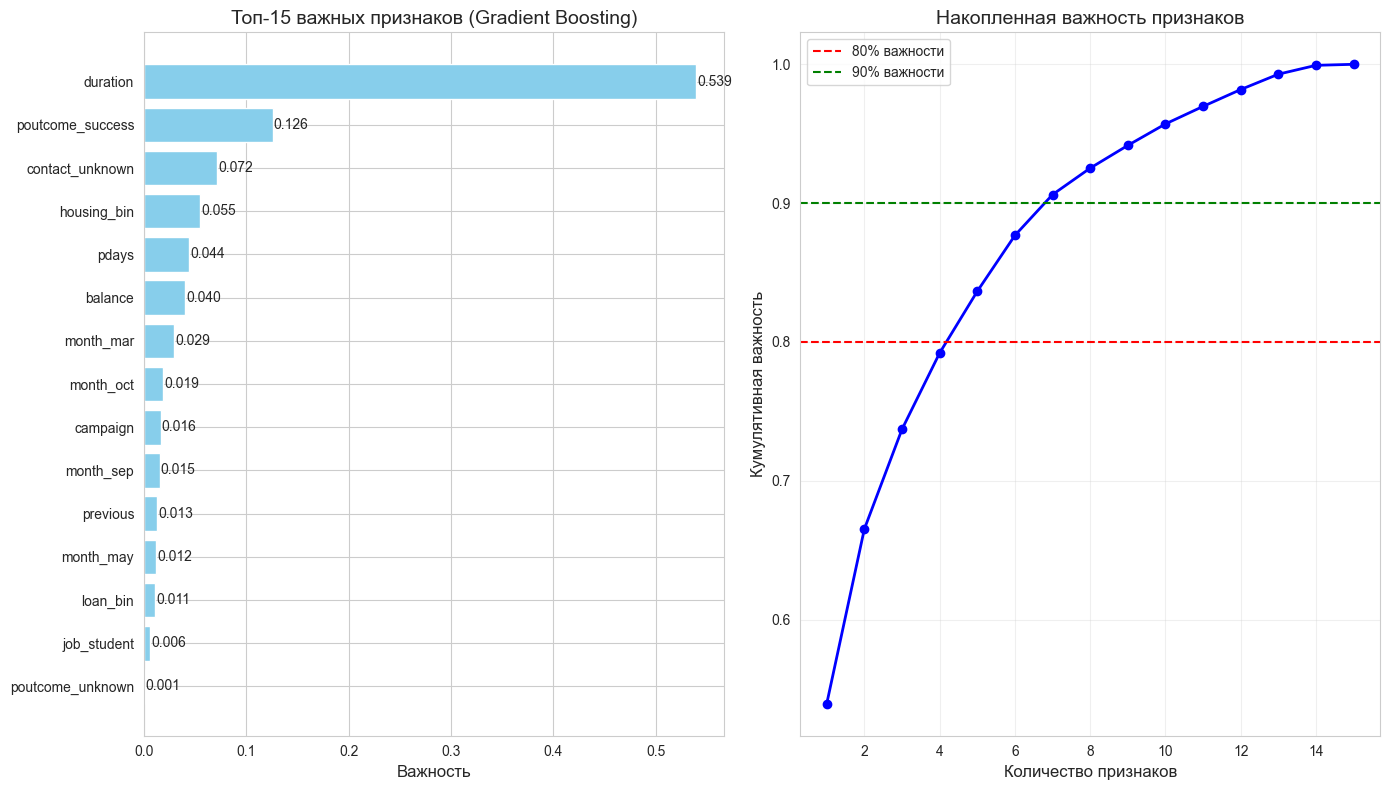


–ö–û–õ–ò–ß–ï–°–¢–í–û –ü–†–ò–ó–ù–ê–ö–û–í –î–õ–Ø –î–û–°–¢–ò–ñ–ï–ù–ò–Ø –ü–û–†–û–ì–û–í
  50% –≤–∞–∂–Ω–æ—Å—Ç–∏: 1 –ø—Ä–∏–∑–Ω–∞–∫–æ–≤
  80% –≤–∞–∂–Ω–æ—Å—Ç–∏: 5 –ø—Ä–∏–∑–Ω–∞–∫–æ–≤
  90% –≤–∞–∂–Ω–æ—Å—Ç–∏: 7 –ø—Ä–∏–∑–Ω–∞–∫–æ–≤
  95% –≤–∞–∂–Ω–æ—Å—Ç–∏: 10 –ø—Ä–∏–∑–Ω–∞–∫–æ–≤

üèÜ –°–ê–ú–´–ô –í–ê–ñ–ù–´–ô –ü–†–ò–ó–ù–ê–ö: duration
   –í–∞–∂–Ω–æ—Å—Ç—å: 0.5395 (53.9%)

–†–ê–°–ü–†–ï–î–ï–õ–ï–ù–ò–ï –í–ê–ñ–ù–û–°–¢–ò
  <0.01: 2 –ø—Ä–∏–∑–Ω–∞–∫–æ–≤
  0.01-0.02: 6 –ø—Ä–∏–∑–Ω–∞–∫–æ–≤
  0.02-0.05: 3 –ø—Ä–∏–∑–Ω–∞–∫–æ–≤
  0.05-0.10: 2 –ø—Ä–∏–∑–Ω–∞–∫–æ–≤
  0.10-0.20: 1 –ø—Ä–∏–∑–Ω–∞–∫–æ–≤
  >0.20: 1 –ø—Ä–∏–∑–Ω–∞–∫–æ–≤


In [ ]:
# –û—Ü–µ–Ω–∏—Ç–µ, –∫–∞–∫–∏–µ –ø—Ä–∏–∑–Ω–∞–∫–∏ –¥–µ–º–æ–Ω—Å—Ç—Ä–∏—Ä—É—é—Ç –Ω–∞–∏–±–æ–ª—å—à—É—é  –≤–∞–∂–Ω–æ—Å—Ç—å –≤ –º–æ–¥–µ–ª–∏ –≥—Ä–∞–¥–∏–µ–Ω—Ç–Ω–æ–≥–æ –±—É—Å—Ç–∏–Ω–≥–∞

# –ò—Å–ø–æ–ª—å–∑—É–µ–º —É–∂–µ –æ–±—É—á–µ–Ω–Ω—É—é –º–æ–¥–µ–ª—å gb_optimized
# –ï—Å–ª–∏ –º–æ–¥–µ–ª—å –Ω–µ –æ–±—É—á–µ–Ω–∞ - –æ–±—É—á–∞–µ–º
if 'gb_optimized' not in dir():
    from sklearn.ensemble import GradientBoostingClassifier
    gb_optimized = GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)
    gb_optimized.fit(X_train_norm, y_train)

# 1. –ü–æ–ª—É—á–∞–µ–º –≤–∞–∂–Ω–æ—Å—Ç—å –ø—Ä–∏–∑–Ω–∞–∫–æ–≤
feature_importance = pd.DataFrame({
    'feature': X_train_norm.columns,
    'importance': gb_optimized.feature_importances_
}).sort_values('importance', ascending=False)

# 2. –í—ã–≤–æ–¥ —Ç–æ–ø-15 –≤–∞–∂–Ω—ã—Ö –ø—Ä–∏–∑–Ω–∞–∫–æ–≤
print("–í–ê–ñ–ù–û–°–¢–¨ –ü–†–ò–ó–ù–ê–ö–û–í (GRADIENT BOOSTING)\n")
print("–¢–û–ü-15 –ù–ê–ò–ë–û–õ–ï–ï –í–ê–ñ–ù–´–• –ü–†–ò–ó–ù–ê–ö–û–í:\n")
print(f"{'‚Ññ':<4} {'–ü—Ä–∏–∑–Ω–∞–∫':<35} {'–í–∞–∂–Ω–æ—Å—Ç—å':<12} {'–ù–∞–∫–æ–ø–ª–µ–Ω–Ω–∞—è':<12}")
print("-" * 65)

cumulative = 0
for i, row in enumerate(feature_importance.head(15).iterrows(), 1):
    idx, data = row
    cumulative += data['importance']
    print(f"{i:<4} {data['feature']:<35} {data['importance']:.4f}     {cumulative:.4f}")

# 3. –í–∏–∑—É–∞–ª–∏–∑–∞—Ü–∏—è –≤–∞–∂–Ω–æ—Å—Ç–∏ –ø—Ä–∏–∑–Ω–∞–∫–æ–≤
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# –ì—Ä–∞—Ñ–∏–∫ 1: –¢–æ–ø-15 –≥–æ—Ä–∏–∑–æ–Ω—Ç–∞–ª—å–Ω–∞—è –¥–∏–∞–≥—Ä–∞–º–º–∞
top_features = feature_importance.head(15)
axes[0].barh(top_features['feature'], top_features['importance'], color='skyblue')
axes[0].set_xlabel('–í–∞–∂–Ω–æ—Å—Ç—å', fontsize=12)
axes[0].set_title('–¢–æ–ø-15 –≤–∞–∂–Ω—ã—Ö –ø—Ä–∏–∑–Ω–∞–∫–æ–≤ (Gradient Boosting)', fontsize=14)
axes[0].invert_yaxis()

# –î–æ–±–∞–≤–ª—è–µ–º –∑–Ω–∞—á–µ–Ω–∏—è –Ω–∞ —Å—Ç–æ–ª–±—Ü—ã
for i, v in enumerate(top_features['importance']):
    axes[0].text(v + 0.001, i, f'{v:.3f}', va='center')

# –ì—Ä–∞—Ñ–∏–∫ 2: –ö—É–º—É–ª—è—Ç–∏–≤–Ω–∞—è –≤–∞–∂–Ω–æ—Å—Ç—å
cumulative_importance = feature_importance['importance'].cumsum()
axes[1].plot(range(1, len(cumulative_importance) + 1), cumulative_importance, 'b-o', linewidth=2)
axes[1].axhline(y=0.8, color='r', linestyle='--', label='80% –≤–∞–∂–Ω–æ—Å—Ç–∏')
axes[1].axhline(y=0.9, color='g', linestyle='--', label='90% –≤–∞–∂–Ω–æ—Å—Ç–∏')
axes[1].set_xlabel('–ö–æ–ª–∏—á–µ—Å—Ç–≤–æ –ø—Ä–∏–∑–Ω–∞–∫–æ–≤', fontsize=12)
axes[1].set_ylabel('–ö—É–º—É–ª—è—Ç–∏–≤–Ω–∞—è –≤–∞–∂–Ω–æ—Å—Ç—å', fontsize=12)
axes[1].set_title('–ù–∞–∫–æ–ø–ª–µ–Ω–Ω–∞—è –≤–∞–∂–Ω–æ—Å—Ç—å –ø—Ä–∏–∑–Ω–∞–∫–æ–≤', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. –ö–æ–ª–∏—á–µ—Å—Ç–≤–æ –ø—Ä–∏–∑–Ω–∞–∫–æ–≤ –¥–ª—è –¥–æ—Å—Ç–∏–∂–µ–Ω–∏—è –ø–æ—Ä–æ–≥–æ–≤
print("\n–ö–û–õ–ò–ß–ï–°–¢–í–û –ü–†–ò–ó–ù–ê–ö–û–í –î–õ–Ø –î–û–°–¢–ò–ñ–ï–ù–ò–Ø –ü–û–†–û–ì–û–í")
for threshold in [0.5, 0.8, 0.9, 0.95]:
    n_features = (cumulative_importance <= threshold).sum() + 1
    print(f"  {threshold*100:.0f}% –≤–∞–∂–Ω–æ—Å—Ç–∏: {n_features} –ø—Ä–∏–∑–Ω–∞–∫–æ–≤")

# 5. –¢–æ–ø-1 —Å–∞–º—ã–π –≤–∞–∂–Ω—ã–π –ø—Ä–∏–∑–Ω–∞–∫
top_feature = feature_importance.iloc[0]
print(f"\nüèÜ –°–ê–ú–´–ô –í–ê–ñ–ù–´–ô –ü–†–ò–ó–ù–ê–ö: {top_feature['feature']}")
print(f"   –í–∞–∂–Ω–æ—Å—Ç—å: {top_feature['importance']:.4f} ({top_feature['importance']*100:.1f}%)")

# 6. –†–∞—Å–ø—Ä–µ–¥–µ–ª–µ–Ω–∏–µ –≤–∞–∂–Ω–æ—Å—Ç–∏
print("\n–†–ê–°–ü–†–ï–î–ï–õ–ï–ù–ò–ï –í–ê–ñ–ù–û–°–¢–ò")
bins = [0, 0.01, 0.02, 0.05, 0.1, 0.2, 1.0]
labels = ['<0.01', '0.01-0.02', '0.02-0.05', '0.05-0.10', '0.10-0.20', '>0.20']
feature_importance['importance_bin'] = pd.cut(feature_importance['importance'], bins=bins, labels=labels)
bin_counts = feature_importance['importance_bin'].value_counts().sort_index()

for bin_label, count in bin_counts.items():
    print(f"  {bin_label}: {count} –ø—Ä–∏–∑–Ω–∞–∫–æ–≤")

### –ó–∞–¥–∞–Ω–∏—è 6,7,8

[I 2026-05-17 22:06:15,358] A new study created in memory with name: gb_optimization


–û–ü–¢–ò–ú–ò–ó–ê–¶–ò–Ø –ì–ò–ü–ï–†–ü–ê–†–ê–ú–ï–¢–†–û–í –° OPTUNA

1. –û–ø—Ç–∏–º–∏–∑–∞—Ü–∏—è Gradient Boosting...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-17 22:06:33,657] Trial 0 finished with value: 0.8011218103621273 and parameters: {'n_estimators': 150, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'min_samples_split': 13, 'min_samples_leaf': 2, 'subsample': 0.662397808134481, 'max_features': 0.3406585285177396}. Best is trial 0 with value: 0.8011218103621273.
[I 2026-05-17 22:06:56,712] Trial 1 finished with value: 0.8031466112761695 and parameters: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.11114989443094977, 'min_samples_split': 2, 'min_samples_leaf': 10, 'subsample': 0.9329770563201687, 'max_features': 0.44863737747479326}. Best is trial 1 with value: 0.8031466112761695.
[I 2026-05-17 22:07:02,646] Trial 2 finished with value: 0.817179736358263 and parameters: {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.028145092716060652, 'min_samples_split': 11, 'min_samples_leaf': 5, 'subsample': 0.7164916560792167, 'max_features': 0.7282970263056656}. Best is trial 2 with value: 0.817179736358263.

[I 2026-05-17 22:15:04,279] A new study created in memory with name: rf_optimization


[I 2026-05-17 22:15:04,252] Trial 29 finished with value: 0.8216324570483021 and parameters: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.09174409048441012, 'min_samples_split': 9, 'min_samples_leaf': 3, 'subsample': 0.9548679506765706, 'max_features': 0.6081707861120682}. Best is trial 27 with value: 0.8220952964312399.

‚úÖ –õ—É—á—à–∏–µ –ø–∞—Ä–∞–º–µ—Ç—Ä—ã Gradient Boosting:
   n_estimators: 150
   max_depth: 4
   learning_rate: 0.040383700461943804
   min_samples_split: 8
   min_samples_leaf: 3
   subsample: 0.9100351534162656
   max_features: 0.9346550388190944

–õ—É—á—à–µ–µ CV F1-score: 0.8221

2. –û–ø—Ç–∏–º–∏–∑–∞—Ü–∏—è Random Forest...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-17 22:15:10,685] Trial 0 finished with value: 0.8163176314852368 and parameters: {'n_estimators': 150, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 0.40921304830970556}. Best is trial 0 with value: 0.8163176314852368.
[I 2026-05-17 22:15:12,884] Trial 1 finished with value: 0.7973992976181492 and parameters: {'n_estimators': 50, 'max_depth': 5, 'min_samples_split': 18, 'min_samples_leaf': 7, 'max_features': 0.7956508044572318}. Best is trial 0 with value: 0.8163176314852368.
[I 2026-05-17 22:15:15,272] Trial 2 finished with value: 0.8152482075380496 and parameters: {'n_estimators': 50, 'max_depth': 20, 'min_samples_split': 17, 'min_samples_leaf': 3, 'max_features': 0.42727747704497043}. Best is trial 0 with value: 0.8163176314852368.
[I 2026-05-17 22:15:19,392] Trial 3 finished with value: 0.8190944132440847 and parameters: {'n_estimators': 100, 'max_depth': 9, 'min_samples_split': 11, 'min_samples_leaf': 5, 'max_features': 0.5038603981386

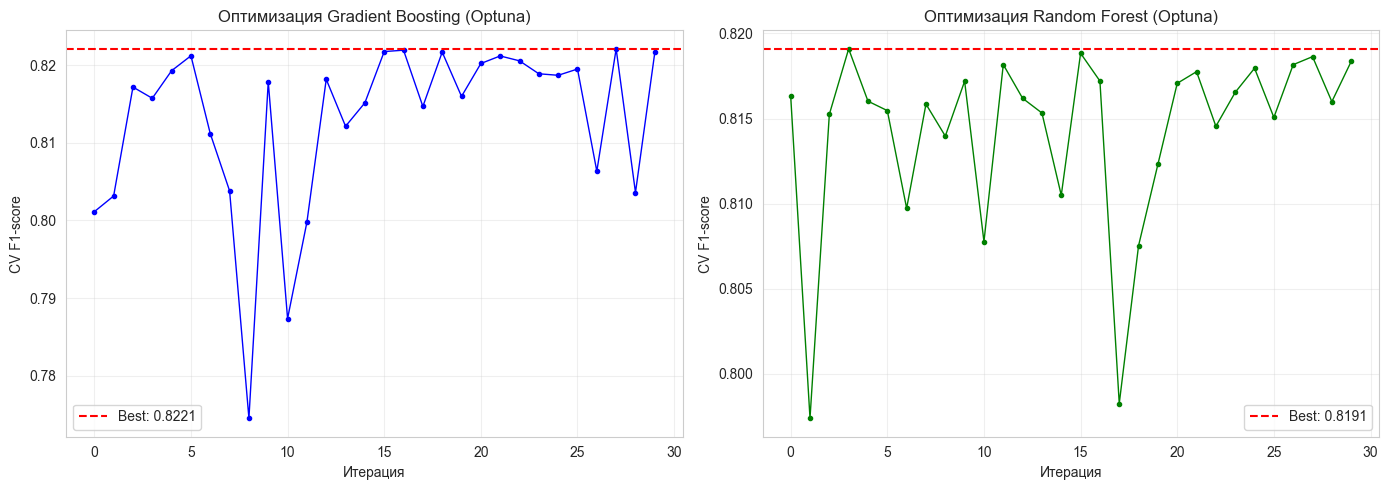

In [ ]:
# –†–µ–∞–ª–∏–∑—É–π—Ç–µ –æ–ø—Ç–∏–º–∏–∑–∞—Ü–∏—é –≥–∏–ø–µ—Ä–ø–∞—Ä–∞–º–µ—Ç—Ä–æ–≤ —Å –ø–æ–º–æ—â—å—é Optuna

# –û–ø—Ä–µ–¥–µ–ª—è–µ–º —Ü–µ–ª–µ–≤—É—é —Ñ—É–Ω–∫—Ü–∏—é –¥–ª—è Optuna
def objective_gb(trial, X_train, y_train, X_test, y_test):
    """–¶–µ–ª–µ–≤–∞—è —Ñ—É–Ω–∫—Ü–∏—è –¥–ª—è –æ–ø—Ç–∏–º–∏–∑–∞—Ü–∏–∏ Gradient Boosting"""
    
    # –ì–∏–ø–µ—Ä–ø–∞—Ä–∞–º–µ—Ç—Ä—ã –¥–ª—è –æ–ø—Ç–∏–º–∏–∑–∞—Ü–∏–∏
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'max_features': trial.suggest_float('max_features', 0.3, 1.0),
    }
    
    # –°–æ–∑–¥–∞–µ–º –∏ –æ–±—É—á–∞–µ–º –º–æ–¥–µ–ª—å
    model = GradientBoostingClassifier(**params, random_state=42)
    
    # –ö—Ä–æ—Å—Å-–≤–∞–ª–∏–¥–∞—Ü–∏—è
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    
    return scores.mean()

# –û–ø—Ç–∏–º–∏–∑–∞—Ü–∏—è –¥–ª—è Random Forest
def objective_rf(trial, X_train, y_train, X_test, y_test):
    """–¶–µ–ª–µ–≤–∞—è —Ñ—É–Ω–∫—Ü–∏—è –¥–ª—è –æ–ø—Ç–∏–º–∏–∑–∞—Ü–∏–∏ Random Forest"""
    
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_float('max_features', 0.3, 1.0),
    }
    
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    
    return scores.mean()


# ============================================
# –ó–ê–ü–£–°–ö –û–ü–¢–ò–ú–ò–ó–ê–¶–ò–ò
# ============================================

print("–û–ü–¢–ò–ú–ò–ó–ê–¶–ò–Ø –ì–ò–ü–ï–†–ü–ê–†–ê–ú–ï–¢–†–û–í –° OPTUNA")

# 1. –û–ø—Ç–∏–º–∏–∑–∞—Ü–∏—è Gradient Boosting
print("\n1. –û–ø—Ç–∏–º–∏–∑–∞—Ü–∏—è Gradient Boosting...")
study_gb = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    study_name='gb_optimization'
)

study_gb.optimize(
    lambda trial: objective_gb(trial, X_train_norm, y_train, X_test_norm, y_test),
    n_trials=30,  # –∫–æ–ª–∏—á–µ—Å—Ç–≤–æ –∏—Ç–µ—Ä–∞—Ü–∏–π
    show_progress_bar=True
)

# –õ—É—á—à–∏–µ –ø–∞—Ä–∞–º–µ—Ç—Ä—ã –¥–ª—è Gradient Boosting
print("\n‚úÖ –õ—É—á—à–∏–µ –ø–∞—Ä–∞–º–µ—Ç—Ä—ã Gradient Boosting:")
best_params_gb = study_gb.best_params
for param, value in best_params_gb.items():
    print(f"   {param}: {value}")
print(f"\n–õ—É—á—à–µ–µ CV F1-score: {study_gb.best_value:.4f}")

# 2. –û–ø—Ç–∏–º–∏–∑–∞—Ü–∏—è Random Forest
print("\n2. –û–ø—Ç–∏–º–∏–∑–∞—Ü–∏—è Random Forest...")
study_rf = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    study_name='rf_optimization'
)

study_rf.optimize(
    lambda trial: objective_rf(trial, X_train_norm, y_train, X_test_norm, y_test),
    n_trials=30,
    show_progress_bar=True
)

# –õ—É—á—à–∏–µ –ø–∞—Ä–∞–º–µ—Ç—Ä—ã –¥–ª—è Random Forest
print("\n‚úÖ –õ—É—á—à–∏–µ –ø–∞—Ä–∞–º–µ—Ç—Ä—ã Random Forest:")
best_params_rf = study_rf.best_params
for param, value in best_params_rf.items():
    print(f"   {param}: {value}")
print(f"\n–õ—É—á—à–µ–µ CV F1-score: {study_rf.best_value:.4f}")


# ============================================
# –û–ë–£–ß–ï–ù–ò–ï –ú–û–î–ï–õ–ï–ô –° –õ–£–ß–®–ò–ú–ò –ü–ê–†–ê–ú–ï–¢–†–ê–ú–ò
# ============================================

# Gradient Boosting —Å –ª—É—á—à–∏–º–∏ –ø–∞—Ä–∞–º–µ—Ç—Ä–∞–º–∏
gb_optuna = GradientBoostingClassifier(**best_params_gb, random_state=42)
gb_optuna.fit(X_train_norm, y_train)
y_pred_gb_optuna = gb_optuna.predict(X_test_norm)
y_pred_proba_gb_optuna = gb_optuna.predict_proba(X_test_norm)[:, 1]

# Random Forest —Å –ª—É—á—à–∏–º–∏ –ø–∞—Ä–∞–º–µ—Ç—Ä–∞–º–∏
rf_optuna = RandomForestClassifier(**best_params_rf, random_state=42, n_jobs=-1)
rf_optuna.fit(X_train_norm, y_train)
y_pred_rf_optuna = rf_optuna.predict(X_test_norm)
y_pred_proba_rf_optuna = rf_optuna.predict_proba(X_test_norm)[:, 1]

# –°—Ä–∞–≤–Ω–µ–Ω–∏–µ —Ä–µ–∑—É–ª—å—Ç–∞—Ç–æ–≤
print("–†–ï–ó–£–õ–¨–¢–ê–¢–´ –ü–û–°–õ–ï OPTUNA –û–ü–¢–ò–ú–ò–ó–ê–¶–ò–ò")

print("\nGradient Boosting (Optuna):")
print(f"  F1-score:  {f1_score(y_test, y_pred_gb_optuna):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_gb_optuna):.4f}")

print("\nRandom Forest (Optuna):")
print(f"  F1-score:  {f1_score(y_test, y_pred_rf_optuna):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_rf_optuna):.4f}")

# –í–∏–∑—É–∞–ª–∏–∑–∞—Ü–∏—è –ø—Ä–æ—Ü–µ—Å—Å–∞ –æ–ø—Ç–∏–º–∏–∑–∞—Ü–∏–∏
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# –ì—Ä–∞—Ñ–∏–∫ 1: –ò—Å—Ç–æ—Ä–∏—è –æ–ø—Ç–∏–º–∏–∑–∞—Ü–∏–∏ Gradient Boosting
gb_trials = study_gb.trials_dataframe()
axes[0].plot(gb_trials['number'], gb_trials['value'], 'b-o', markersize=3, linewidth=1)
axes[0].set_xlabel('–ò—Ç–µ—Ä–∞—Ü–∏—è')
axes[0].set_ylabel('CV F1-score')
axes[0].set_title('–û–ø—Ç–∏–º–∏–∑–∞—Ü–∏—è Gradient Boosting (Optuna)')
axes[0].axhline(y=study_gb.best_value, color='r', linestyle='--', label=f'Best: {study_gb.best_value:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# –ì—Ä–∞—Ñ–∏–∫ 2: –ò—Å—Ç–æ—Ä–∏—è –æ–ø—Ç–∏–º–∏–∑–∞—Ü–∏–∏ Random Forest
rf_trials = study_rf.trials_dataframe()
axes[1].plot(rf_trials['number'], rf_trials['value'], 'g-o', markersize=3, linewidth=1)
axes[1].set_xlabel('–ò—Ç–µ—Ä–∞—Ü–∏—è')
axes[1].set_ylabel('CV F1-score')
axes[1].set_title('–û–ø—Ç–∏–º–∏–∑–∞—Ü–∏—è Random Forest (Optuna)')
axes[1].axhline(y=study_rf.best_value, color='r', linestyle='--', label=f'Best: {study_rf.best_value:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()